Found 50 energy files between 1e+01 and 1e+06 GeV:
  E=1.12202e1 (1.122e+01 GeV)
  E=1.41254e1 (1.413e+01 GeV)
  E=1.77828e1 (1.778e+01 GeV)
  E=2.23872e1 (2.239e+01 GeV)
  E=2.81838e1 (2.818e+01 GeV)
  E=3.54813e1 (3.548e+01 GeV)
  E=4.46684e1 (4.467e+01 GeV)
  E=5.62341e1 (5.623e+01 GeV)
  E=7.07946e1 (7.079e+01 GeV)
  E=8.91251e1 (8.913e+01 GeV)
  E=1.12202e2 (1.122e+02 GeV)
  E=1.41254e2 (1.413e+02 GeV)
  E=1.77828e2 (1.778e+02 GeV)
  E=2.23872e2 (2.239e+02 GeV)
  E=2.81838e2 (2.818e+02 GeV)
  E=3.54813e2 (3.548e+02 GeV)
  E=4.46684e2 (4.467e+02 GeV)
  E=5.62341e2 (5.623e+02 GeV)
  E=7.07946e2 (7.079e+02 GeV)
  E=8.91251e2 (8.913e+02 GeV)
  E=1.12202e3 (1.122e+03 GeV)
  E=1.41254e3 (1.413e+03 GeV)
  E=1.77828e3 (1.778e+03 GeV)
  E=2.23872e3 (2.239e+03 GeV)
  E=2.81838e3 (2.818e+03 GeV)
  E=3.54813e3 (3.548e+03 GeV)
  E=4.46684e3 (4.467e+03 GeV)
  E=5.62341e3 (5.623e+03 GeV)
  E=7.07946e3 (7.079e+03 GeV)
  E=8.91251e3 (8.913e+03 GeV)
  E=1.12202e4 (1.122e+04 GeV)
  E=1.41254e4 (1.41

  Loaded E=1.41254e2 seed=3: 24200 rows
  Loaded E=1.77828e2 seed=1: 31120 rows
  Loaded E=1.77828e2 seed=2: 24200 rows
  Loaded E=1.77828e2 seed=3: 24200 rows
  Loaded E=2.23872e2 seed=1: 31120 rows
  Loaded E=2.23872e2 seed=2: 24200 rows
  Loaded E=2.23872e2 seed=3: 24200 rows
  Loaded E=2.81838e2 seed=1: 31120 rows
  Loaded E=2.81838e2 seed=2: 24200 rows
  Loaded E=2.81838e2 seed=3: 24200 rows
  Loaded E=3.54813e2 seed=1: 31120 rows
  Loaded E=3.54813e2 seed=2: 24200 rows
  Loaded E=3.54813e2 seed=3: 24200 rows
  Loaded E=4.46684e2 seed=1: 31120 rows
  Loaded E=4.46684e2 seed=2: 24200 rows
  Loaded E=4.46684e2 seed=3: 24200 rows
  Loaded E=5.62341e2 seed=1: 31120 rows
  Loaded E=5.62341e2 seed=2: 24200 rows
  Loaded E=5.62341e2 seed=3: 24200 rows
  Loaded E=7.07946e2 seed=1: 31120 rows
  Loaded E=7.07946e2 seed=2: 24200 rows
  Loaded E=7.07946e2 seed=3: 24200 rows
  Loaded E=8.91251e2 seed=1: 31120 rows
  Loaded E=8.91251e2 seed=2: 24200 rows
  Loaded E=8.91251e2 seed=3: 24200 rows


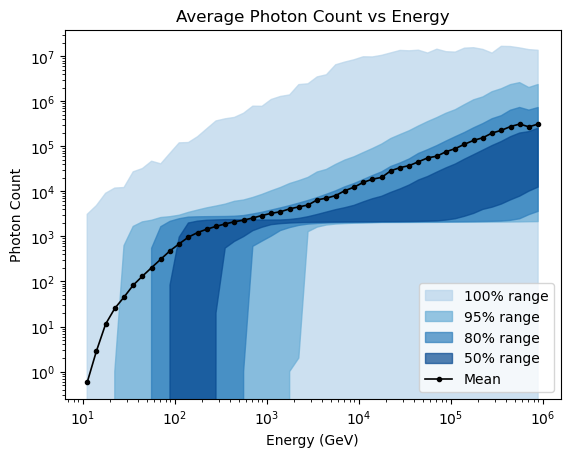

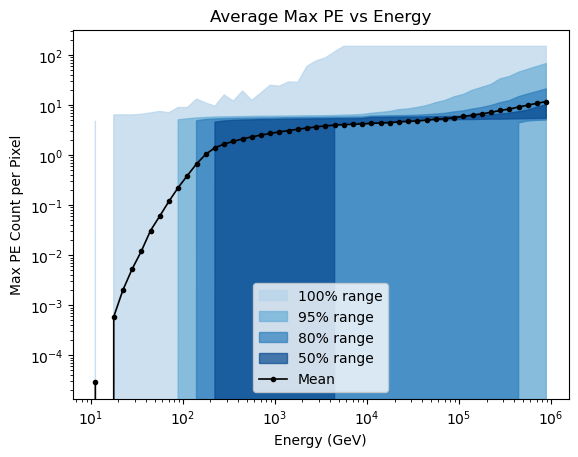

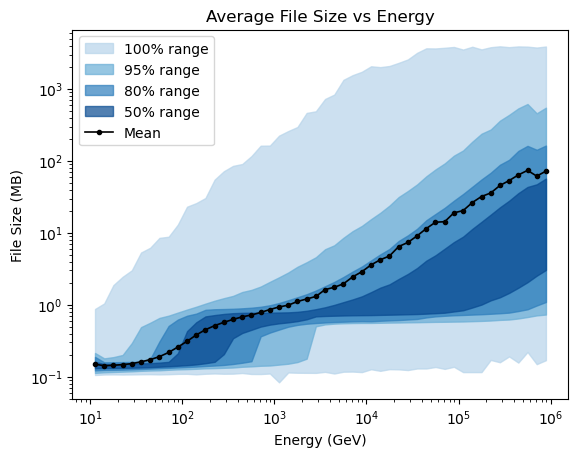

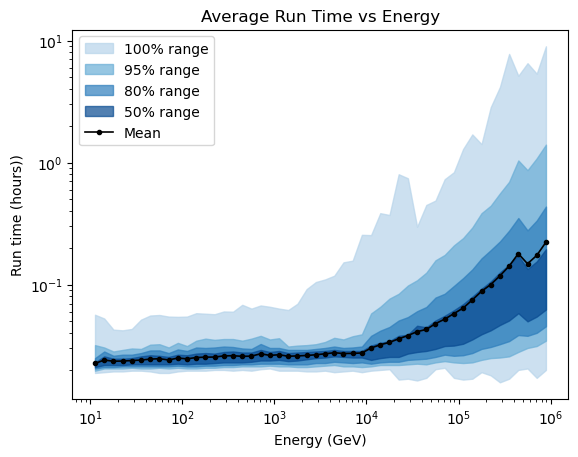

9.535061401023002 TB 4250.585011498963 photon per MB


In [1]:
#Extract data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import os
import sys
import math

# ── Configuration ─────────────────────────────────────────────────────────────
PE_THRESHOLD = 20
#N_BOOTSTRAP = 1000
#CI_LEVEL = 0.99
E_MIN_GEV = 1e1
E_MAX_GEV = 1e6
SEEDS = [1,2,3]
PID = 13
RADIUS = 5
BASE_DIR = "/scratch/general/vast/u1520754/muon_sim_chain_tree"


# ── Helper functions ─────────────────────────────────────────────────────────
def load_scan(csv_path: str) -> pd.DataFrame:
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"CSV not found: {csv_path}")
    df = pd.read_csv(csv_path)
    n_missing = (df["file_found"] == 0).sum()
    if n_missing > 0:
        print(f"  WARNING: {n_missing} rows had file_found=0 and will be dropped.")
        index = (df["file_found"] == 0)
        """print("zenith",set(df["zen"][index]))
        print("azimuth",set(df["az"][index]))
        print("height",set(df["height"][index]))"""
    df = df[df["file_found"] == 1].copy()
    df["r"] = np.sqrt(df["tel_x"]**2 + df["tel_z"]**2).round(4)
    df["detected"] = (df["max_pe"] >= PE_THRESHOLD).astype(float)
    return df

def slant_depth(zem, obs_height, zenith_rad):
    theta = np.pi - zenith_rad
    arg = (obs_height / zem) * np.sin(theta)
    arg = np.clip(arg, -1.0, 1.0)
    beta = np.where(np.isfinite(arg), np.arcsin(arg), 0.0)
    beta = np.clip(beta, 0.0, np.pi/2)
    #beta = np.clip(np.arcsin((obs_height / zem) * np.sin(theta)), 0, np.pi/2)
    alpha = np.pi - theta - beta
    s = zem * np.sin(alpha) / np.sin(theta)
    return np.clip(s, 0, np.inf)
def incidence_angle(Zenith_deg, Azimuth_deg):
    Zenith = Zenith_deg
    Azimuth = Azimuth_deg
    cos_Zenith = np.cos(np.radians(Zenith))
    cos_Azimuth = np.cos(np.radians(Azimuth - 180))
    cos_Incidence = np.sqrt(1 - cos_Zenith**2 - cos_Azimuth**2)
    Incidence = np.degrees(np.arccos(cos_Incidence))
    return Incidence


import re
import os

def get_available_energies(base_dir, pid, radius, e_min_GeV, e_max_GeV):
    """
    Scan BASE_DIR for folders matching the given PID and RADIUS,
    extract energy values, and filter by [e_min_GeV, e_max_GeV].
    Returns sorted list of (energy_GeV, energy_str) tuples.
    """
    pattern = re.compile(
        rf"Muon_pid{pid}_E([0-9]+\.?[0-9]*e[+-]?[0-9]+)_R{radius}$"
    )
    found = {}
    for name in os.listdir(base_dir):
        m = pattern.match(name)
        if m:
            energy_str = m.group(1)
            energy_val = float(energy_str)
            if e_min_GeV <= energy_val <= e_max_GeV:
                found[energy_val] = energy_str

    return sorted(found.items())  # sorted by energy_GeV


available = get_available_energies(BASE_DIR, PID, RADIUS, E_MIN_GEV, E_MAX_GEV)
print(f"Found {len(available)} energy files between {E_MIN_GEV:.0e} and {E_MAX_GEV:.0e} GeV:")
for e_val, e_str in available:
    print(f"  E={e_str} ({e_val:.3e} GeV)")

# ── Load only those files ────────────────────────────────────────────────────
dfs = []
missing_energies = []
for energy_val, energy_str in available:
    for seed in SEEDS:
        csv_path = (f"{BASE_DIR}/Muon_pid{PID}_E{energy_str}_R{RADIUS}/"
                    f"csv_output/scan_care_pid{PID}_E{energy_str}_R{RADIUS}_y0_s{seed}.csv")
        try:
            df_tmp = load_scan(csv_path)
            df_tmp["seed"] = seed
            df_tmp["energy_string"] = energy_str
            df_tmp["energy_GeV"] = energy_val
            dfs.append(df_tmp)
            print(f"  Loaded E={energy_str} seed={seed}: {len(df_tmp)} rows")
        except Exception as e:
            missing_energies.append(energy_str)
            print(f"  ⚠ E={energy_str} seed={seed}: {e}")


df = pd.concat(dfs, ignore_index=True)
print(f"\nMerged: {len(df)} total rows from {len(dfs)} file(s)")
print(f"Energy range: {df['energy_GeV'].min():.1f} – {df['energy_GeV'].max():.1f} GeV")
if missing_energies:
    print(f"Missing energies: {sorted(set(missing_energies))}")

# ── Derived columns ──────────────────────────────────────────────────────────
R = np.array(df["r"]) # m
X = np.array(df["tel_x"]) # m
Z = np.array(df["tel_z"]) # m
H = np.array(df["height"]) # m
Zenith = np.array(df["zen"]) #Degree
Azimuth = np.array(df["az"]) #Degree
Max_PE = np.array(df["max_pe"]) #Photo_electron
Time_at_Max_PE = np.array(df["time_at_max_pe_ns"]) #ns
Avg_PE = np.array(df["avg_pe"]) 
Total_PE = np.array(df["total_pe"])
Energy_GeV = np.array(df["energy_GeV"]) #GeV
Slant = slant_depth(H + 6371e3, 2944 + 6371e3, np.radians(Zenith))/1000 #km
cos_Zenith = np.cos(np.radians(Zenith))
cos_Azimuth = np.cos(np.radians(Azimuth - 180))
cos_Incidence = np.sqrt(1 - cos_Zenith**2 - cos_Azimuth**2)
Incidence = incidence_angle(Zenith, Azimuth) #Degree
#pulse_width = np.array(df["pulse_width_ns"])
#rise_time = np.array(df["rise_time_ns"])
x_mag = np.array(df["correction_x_m"]) #m
y_mag = np.array(df["correction_y_m"]) #m
file_size = np.array(df["file_size_MB"]) #MB
photon_count = np.array(df["cph_photon_count"])
#max_photon_10ns = np.array(df["cph_max_photons_10ns"])
E_list = np.sort(np.array(list(set(Energy_GeV))))
deleted_low_pe = np.array(df["deleted_low_pe"])
runtime_hours = np.array(df["runtime_seconds"])/3600 
File = []
Photon = []
PE = []
Time = []

Total_FIle_Size = np.nansum(file_size)/1000 - np.nansum(file_size[deleted_low_pe==1])/1000#MB to GB

# --- Coverage levels for nested bands ---
coverages = [50, 80, 95, 100]    # percent
cmap = plt.cm.Blues

# Storage for multi-coverage bands: dict[coverage] -> (lows, highs)
file_bands   = {c: ([], []) for c in coverages}
photon_bands = {c: ([], []) for c in coverages}
pe_bands     = {c: ([], []) for c in coverages}
time_bands     = {c: ([], []) for c in coverages}
for energy in E_list:
    mask = Energy_GeV == energy

    f  = np.nanmean(file_size[mask])
    p  = np.nanmean(photon_count[mask])
    pe = np.nanmean(Max_PE[mask])
    t = np.nanmean(runtime_hours[mask]) 

    File.append(f)
    Photon.append(p)
    PE.append(pe)
    Time.append(t)
    
    # Multi-coverage percentile bands
    for cov in coverages:
        lo_p = (100 - cov) / 2
        hi_p = 100 - lo_p
        file_bands[cov][0].append(np.nanpercentile(file_size[mask], lo_p))
        file_bands[cov][1].append(np.nanpercentile(file_size[mask], hi_p))
        photon_bands[cov][0].append(np.nanpercentile(photon_count[mask], lo_p))
        photon_bands[cov][1].append(np.nanpercentile(photon_count[mask], hi_p))
        pe_bands[cov][0].append(np.nanpercentile(Max_PE[mask], lo_p))
        pe_bands[cov][1].append(np.nanpercentile(Max_PE[mask], hi_p))
        time_bands[cov][0].append(np.nanpercentile(runtime_hours[mask], lo_p))
        time_bands[cov][1].append(np.nanpercentile(runtime_hours[mask], hi_p))
File   = np.array(File)
Photon = np.array(Photon)
PE     = np.array(PE)
Time   = np.array(Time)

for cov in coverages:
    file_bands[cov]   = (np.array(file_bands[cov][0]),   np.array(file_bands[cov][1]))
    photon_bands[cov] = (np.array(photon_bands[cov][0]), np.array(photon_bands[cov][1]))
    pe_bands[cov]     = (np.array(pe_bands[cov][0]),     np.array(pe_bands[cov][1]))
    time_bands[cov]   = (np.array(time_bands[cov][0]),     np.array(time_bands[cov][1]))

def plot_with_bands(E_list, mean, bands_dict, coverages, ylabel, title):
    fig, ax = plt.subplots()
    # Widest first (lightest), narrowest last (darkest)
    order = sorted(coverages, reverse=True)
    n = len(order)
    for i, cov in enumerate(order):
        lo, hi = bands_dict[cov]
        color = cmap(0.3 + 0.6 * (i / max(1, n - 1)))
        ax.fill_between(E_list, lo, hi, color=color, alpha=0.7,
                        label=f'{cov}% range')
    ax.plot(E_list, mean, 'k.-', lw=1.2, label='Mean')
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Energy (GeV)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    plt.show()


# --- Photon Count Plot ---
plot_with_bands(E_list, Photon, photon_bands, coverages,
                "Photon Count", "Average Photon Count vs Energy")

# --- PE Count Plot ---
plot_with_bands(E_list, PE, pe_bands, coverages,
                "Max PE Count per Pixel", "Average Max PE vs Energy")

plot_with_bands(E_list, File, file_bands, coverages,
                "File Size (MB)", "Average File Size vs Energy")

plot_with_bands(E_list, Time, time_bands, coverages,
                "Run time (hours))", "Average Run Time vs Energy")

print(Total_FIle_Size/1000, "TB", np.nanmean(Photon)/np.nanmean(File), "photon per MB")


Plotting energies (GeV): [np.float64(11.2202), np.float64(89.1251), np.float64(891.251), np.float64(8912.51), np.float64(89125.1)]


/tmp/ipykernel_2705271/219320268.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mcm.get_cmap('plasma', len(selected_energies))


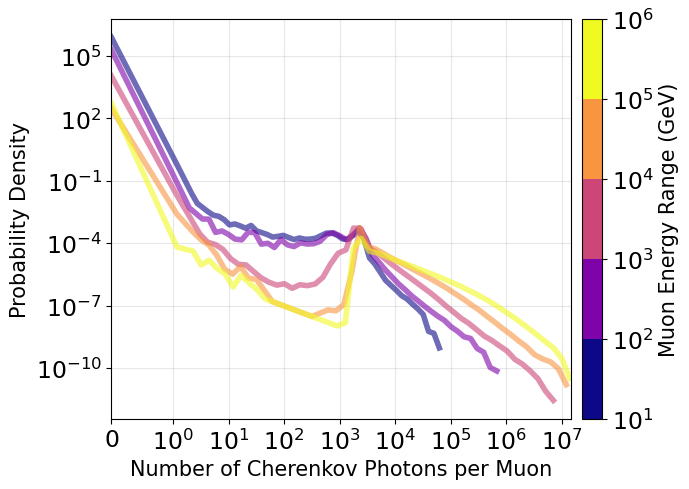

In [2]:
import matplotlib.colors as mcolors
import matplotlib.cm as mcm

# ── Sans-serif font globally ───────────────────────────────────────────────
plt.rcParams.update({
    'font.family':          'sans-serif',
    'font.sans-serif':      ['DejaVu Sans'],
    'mathtext.fontset':     'dejavusans',
    # ── Tick font size ─────────────────────────────────────────────
    'xtick.labelsize':      17,
    'ytick.labelsize':      17,
    'axes.labelsize':       15,
    'axes.titlesize':       14,
    'legend.fontsize':      11,
})

target_energies = [1e1, 1e2, 1e3, 1e4, 1e5, 1e6]  # <-- edit these

selected_energies = [E_list[np.argmin(np.abs(E_list - t))] for t in target_energies[:-1]]
print("Plotting energies (GeV):", selected_energies)

n_bins    = 50
linthresh = 1.0

# ── Colormap + norm tied to energy bin edges ──────────────────────────────
cmap = mcm.get_cmap('plasma', len(selected_energies))
norm = mcolors.BoundaryNorm(
    boundaries=np.log10(target_energies),
    ncolors=len(selected_energies)
)

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

for i, E in enumerate(selected_energies):
    color = cmap(i / len(selected_energies))

    mask   = (Energy_GeV >= target_energies[i]) & (Energy_GeV < target_energies[i + 1])
    counts = photon_count[mask]

    if counts.size == 0:
        continue

    counts_zero = counts[counts == 0]
    counts_pos  = counts[counts  > 0]

    if counts_zero.size > 0:
        zero_hist   = np.array([counts_zero.size])
        zero_center = np.array([0.0])
        zero_err    = np.sqrt(zero_hist)
    else:
        zero_hist = zero_center = zero_err = np.array([])

    if counts_pos.size > 0:
        log_bins = np.logspace(
            np.log10(max(counts_pos.min(), linthresh)),
            np.log10(counts_pos.max()),
            n_bins + 1
        )
        hist, bin_edges = np.histogram(counts_pos, bins=log_bins, density=True)
        bin_centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])
        err = np.sqrt(hist)
    else:
        hist = bin_centers = err = np.array([])

    all_centers = np.concatenate([zero_center, bin_centers])
    all_hist    = np.concatenate([zero_hist,   hist])
    all_err     = np.concatenate([zero_err,    err])
    plot_mask   = all_hist > 0

    """ax.errorbar(
        all_centers[plot_mask], all_hist[plot_mask]* all_centers[plot_mask],
        #yerr=all_err[plot_mask],
        fmt='o', markersize=4, linewidth=4,
        capsize=4, elinewidth=1, color=color,
    )"""
    ax.plot(
        all_centers[plot_mask], all_hist[plot_mask],
        '-', color=color, linewidth=4, alpha=0.6
    )

# ── Colorbar ──────────────────────────────────────────────────────────────
sm = mcm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label('Muon Energy Range (GeV)')

tick_vals = np.log10(target_energies)
cbar.set_ticks(tick_vals)
cbar.set_ticklabels([rf'$10^{{{int(np.log10(e))}}}$' for e in target_energies])

ax.set_xlabel("Number of Cherenkov Photons per Muon")
ax.set_ylabel('Probability Density')
#ax.set_yscale('symlog', linthresh=1)
ax.set_yscale('log')
ax.set_xscale('symlog', linthresh=linthresh)
ax.set_xlim(left=0)
ax.grid(True, which='both', alpha=0.3)

fig.tight_layout()
plt.savefig("/uufs/chpc.utah.edu/common/home/u1520754/Muon_Trinity/plot/photn_count_distribution.png",transparent=True)
plt.show()


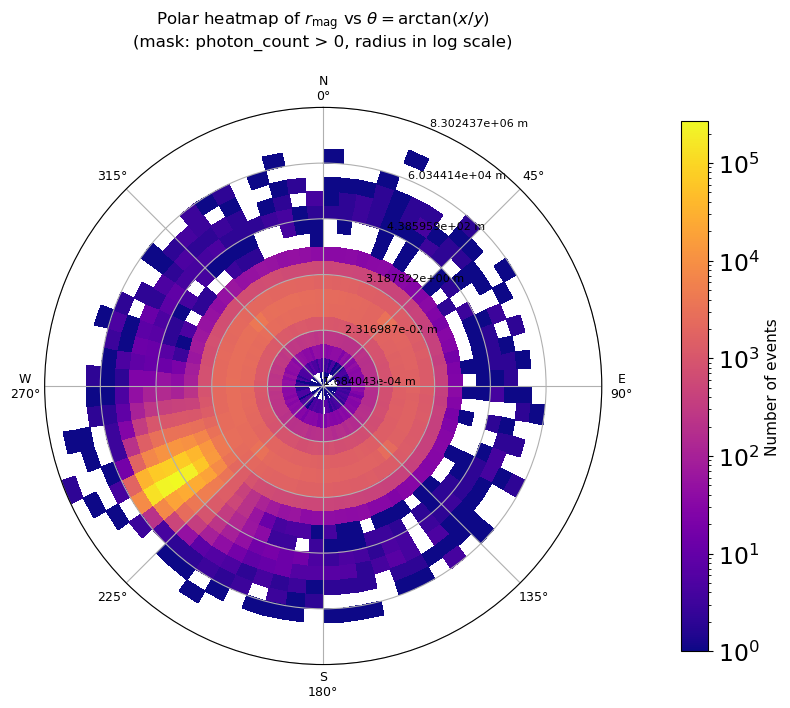

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ── User-defined parameters ───────────────────────────────────────────────────
N_r_bins     = 20   # radial bins
N_theta_bins = 72   # angular bins  (72 → 5° each)

# ── Mask & derived quantities ─────────────────────────────────────────────────
mask  = photon_count >= 100
x_m   = x_mag[mask]
y_m   = y_mag[mask]

r_m   = np.sqrt(x_m**2 + y_m**2)
theta_m = np.degrees(np.arctan2(x_m, y_m))   # −180 … +180 °

# Remove r == 0 (log would be -inf)
valid   = r_m > 0
r_m     = r_m[valid]
theta_m = theta_m[valid]

# ── Bin edges ─────────────────────────────────────────────────────────────────
log_r_edges   = np.linspace(np.log10(r_m.min()), np.log10(r_m.max()), N_r_bins + 1)
theta_edges   = np.linspace(-180, 180, N_theta_bins + 1)

# ── 2-D histogram in (theta, log_r) space ────────────────────────────────────
log_r_m = np.log10(r_m)

Hist, _, _ = np.histogram2d(theta_m, log_r_m,
                          bins=[theta_edges, log_r_edges])
# H shape: (N_theta_bins, N_r_bins)

# ── Build coordinate grids for pcolormesh on a POLAR axes ────────────────────
# pcolormesh on polar axes expects:
#   theta grid in RADIANS  shape (N_theta+1, N_r+1)
#   r     grid in data units (we want log scale, so pass log values directly
#          and relabel the ticks afterwards)

T_edges = np.radians(theta_edges)           # (N_theta+1,)
R_edges = log_r_edges                        # (N_r+1,)   — plain floats, no mask

# meshgrid: shapes (N_theta+1, N_r+1)
T_grid, R_grid = np.meshgrid(T_edges, R_edges, indexing='ij')

# Replace zero-count bins with NaN so they show as transparent
Z = Hist.copy().astype(float)          # (N_theta, N_r)
Z[Z == 0] = np.nan

# ── Plot ──────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(8, 8))
ax  = fig.add_subplot(111, projection='polar')

# North at top, clockwise
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)

cmap = plt.cm.plasma
cmap.set_bad(color='none')          # transparent for NaN bins

norm = mcolors.LogNorm(vmin=1, vmax=np.nanmax(Z))

mesh = ax.pcolormesh(T_grid, R_grid, Z,
                     cmap=cmap, norm=norm,
                     shading='flat')

# ── Radial tick labels: convert log10 values back to metres ──────────────────
r_tick_log = np.linspace(log_r_edges[0], log_r_edges[-1], 6)
ax.set_yticks(r_tick_log)
ax.set_yticklabels([f"{10**v:e} m" for v in r_tick_log],
                   fontsize=8, color='black')
ax.yaxis.set_tick_params(labelcolor='black')

# ── Angular tick labels ───────────────────────────────────────────────────────
ax.set_xticks(np.radians(np.arange(0, 360, 45)))
ax.set_xticklabels(['N\n0°','45°','E\n90°','135°',
                    'S\n180°','225°','W\n270°','315°'],
                   fontsize=9)

# ── Colour bar ────────────────────────────────────────────────────────────────
cbar = fig.colorbar(mesh, ax=ax, pad=0.12, fraction=0.04)
cbar.set_label("Number of events", fontsize=11)

ax.set_title(r"Polar heatmap of $r_{\rm mag}$ vs $\theta = \arctan(x/y)$"
             "\n(mask: photon_count > 0, radius in log scale)",
             fontsize=12, pad=20)

#ax.set_facecolor('#1a1a2e')
#fig.patch.set_facecolor('#1a1a2e')

plt.tight_layout()
plt.savefig("polar_heatmap_rmag_theta.png", dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()


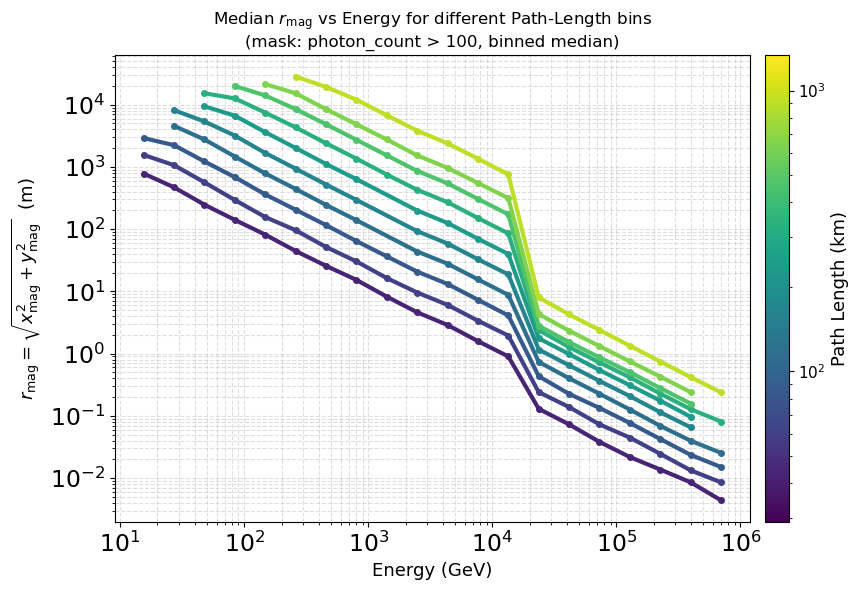

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ── User-defined binning parameters ──────────────────────────────────────────
N_energy_bins = 20   # number of Energy bins
N_r_bins      = 50   # number of r bins
N_slant_bins  = 10    # number of Slant bins

# ── Derived quantity ──────────────────────────────────────────────────────────
r_mag = np.sqrt(x_mag**2 + y_mag**2)   # m

# ── Apply mask: photon_count > 0 ─────────────────────────────────────────────
mask = photon_count >= 100

Energy_m  = Energy_GeV[mask]
r_mag_m   = r_mag[mask]
Slant_m   = Slant[mask]

# ── Define bin edges ─────────────────────────────────────────────────────────
energy_edges = np.logspace(np.log10(Energy_m.min()),
                           np.log10(Energy_m.max()),
                           N_energy_bins + 1)
energy_centers = 0.5 * (energy_edges[:-1] + energy_edges[1:])

r_edges    = np.logspace(np.log10(r_mag_m[r_mag_m > 0].min()),
                         np.log10(r_mag_m.max()),
                         N_r_bins + 1)

slant_edges   = np.logspace(np.log10(Slant_m.min()), np.log10(Slant_m.max()), N_slant_bins + 1)
slant_centers = 0.5 * (slant_edges[:-1] + slant_edges[1:])

import matplotlib.colorbar as mcolorbar
import matplotlib.colors as mcolors

# ── Colour map for Slant bins ─────────────────────────────────────────────────
cmap = cm.viridis
norm = mcolors.LogNorm(vmin=slant_edges[0], vmax=slant_edges[-1])
colors = cmap(np.linspace(0.1, 0.9, N_slant_bins))

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

for i in range(N_slant_bins):
    # Select data in this Slant bin
    s_mask = (Slant_m >= slant_edges[i]) & (Slant_m < slant_edges[i + 1])

    E_s   = Energy_m[s_mask]
    r_s   = r_mag_m[s_mask]

    if E_s.size == 0:
        continue

    # Bin r_mag by Energy and take the median (robust to outliers)
    r_binned = np.full(N_energy_bins, np.nan)
    for j in range(N_energy_bins):
        e_mask = (E_s >= energy_edges[j]) & (E_s < energy_edges[j + 1])
        if e_mask.sum() > 0:
            r_binned[j] = np.median(r_s[e_mask])

    valid = ~np.isnan(r_binned)
    if valid.sum() == 0:
        continue

    label = (f"Path Length [{slant_edges[i]:.1f}, {slant_edges[i+1]:.1f}) km  "
             f"(n={s_mask.sum()})")
    ax.plot(energy_centers[valid], r_binned[valid],
            marker='o',
            ms=4, lw=3,
            color=colors[i], label=label)
# ── Colorbar ──────────────────────────────────────────────────────────────────
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])   # required dummy

cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("Path Length (km)", fontsize=13)
cbar.ax.tick_params(labelsize=11)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Energy (GeV)", fontsize=13)
ax.set_ylabel(r"$r_{\rm mag} = \sqrt{x_{\rm mag}^2 + y_{\rm mag}^2}$  (m)",
              fontsize=13)
ax.set_title(r"Median $r_{\rm mag}$ vs Energy for different Path-Length bins"
             "\n(mask: photon_count > 100, binned median)",
             fontsize=12)
#ax.legend(fontsize=8, loc="best", framealpha=0.7)
ax.grid(True, which="both", ls="--", alpha=0.4)

plt.tight_layout()
plt.savefig("rmag_vs_energy_slant.png", dpi=150)
plt.show()


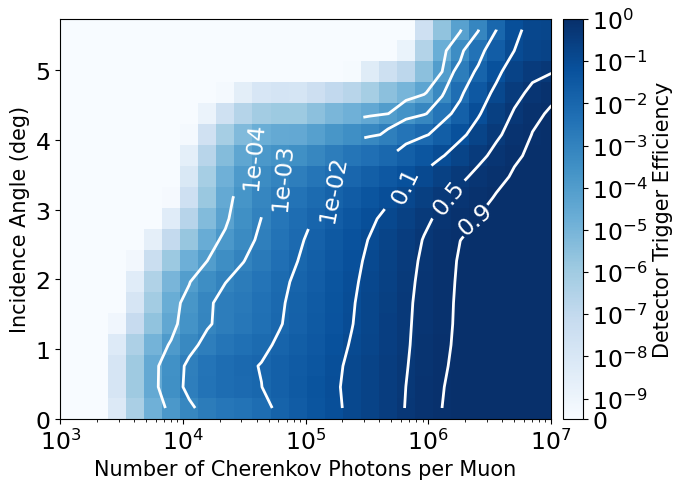

In [5]:
# Empirical trigger efficiency: P(Max_PE >= threshold | photon_count, incidence)
# =============================================================================
from scipy.ndimage import gaussian_filter
from matplotlib.colors import SymLogNorm

# ---------- 1. Clean inputs ----------
m = (np.isfinite(photon_count) & (photon_count > 0)
     & np.isfinite(Max_PE)     & (Max_PE >= 0)
     & np.isfinite(Incidence))
pc_  = photon_count[m]
pe_  = Max_PE[m]
inc_ = Incidence[m]
hit_ = (pe_ >= PE_THRESHOLD).astype(float)

# ---------- 2. Define 2-D bins ----------
pc_edges  = np.logspace(np.log10(pc_.min()), np.log10(pc_.max()), 50)
inc_edges = np.linspace(inc_.min(),inc_.max(), 20)
pc_cen    = np.sqrt(pc_edges[:-1] * pc_edges[1:])
inc_cen   = 0.5*(inc_edges[:-1] + inc_edges[1:])

# ---------- 3. Build empirical efficiency table ----------
N_tot, _, _ = np.histogram2d(pc_, inc_, bins=[pc_edges, inc_edges])
N_hit, _, _ = np.histogram2d(pc_, inc_, bins=[pc_edges, inc_edges], weights=hit_)

with np.errstate(invalid='ignore', divide='ignore'):
    eff = np.where(N_tot >= 5, N_hit / N_tot, np.nan)
    eff_err = np.where(N_tot >= 5, np.sqrt(eff*(1-eff)/N_tot), np.nan)

# Light smoothing to fill noisy bins (optional)
eff_smooth = eff.copy()
mask = np.isfinite(eff_smooth)
eff_smooth[~mask] = 0
weights = mask.astype(float)
sigma_value = 0.9
eff_smooth = gaussian_filter(eff_smooth, sigma=sigma_value) / np.clip(
    gaussian_filter(weights, sigma=sigma_value), 1e-6, None)

# ---------- 4. Lookup function with bilinear interpolation ----------
from scipy.interpolate import RegularGridInterpolator
interp = RegularGridInterpolator(
    (np.log10(pc_cen), inc_cen), eff_smooth,
    bounds_error=False, fill_value=None, method='linear')

def trigger_eff(N_gamma, inc_deg):
    N_gamma = np.asarray(N_gamma, dtype=float)
    inc_deg = np.asarray(inc_deg, dtype=float)
    N_b, inc_b = np.broadcast_arrays(N_gamma, inc_deg)
    pts = np.column_stack([
        np.log10(np.clip(N_b.ravel(), pc_.min(), pc_.max())),
        np.clip(inc_b.ravel(), inc_.min(), inc_.max()),
    ])
    vals = np.clip(interp(pts), 0.0, 1.0)
    return vals.reshape(N_b.shape)

# ---------- 5. Plot the efficiency map ----------
fig, ax = plt.subplots(figsize=(7, 5))

pcm = ax.pcolormesh(
    pc_edges, inc_edges, eff_smooth.T,
    cmap='Blues',
    norm=SymLogNorm(
        linthresh=np.min(eff_smooth[np.where(eff_smooth > 1e-9)]),
        linscale=0.5,
        base=10
    )
)

# ── Contours ──────────────────────────────────────────────────────────────
contour_levels = [1e-4, 1e-3, 1e-2, 0.1, 0.5, 0.9]
# filter to levels actually present in data
valid_levels = [lv for lv in contour_levels
                if np.nanmin(eff_smooth) <= lv <= np.nanmax(eff_smooth)]

if valid_levels:
    cs = ax.contour(
        pc_cen, inc_cen, eff_smooth.T,   # ← transposed to match pcolormesh
        levels=valid_levels,
        colors='white',
        linewidths=2,
        alpha=1,
    )
    ax.clabel(
        cs,
        fmt={v: f'{v:.0e}' if v < 0.1 else f'{v:.1f}' for v in valid_levels},
        fontsize=17,
        inline=True,
        #set_fontweight="bold"
    )

# ── Axes ──────────────────────────────────────────────────────────────────
ax.set_xscale('log')
ax.set_xlim(1e3, 1e7)
ax.set_xlabel("Number of Cherenkov Photons per Muon")
ax.set_ylabel("Incidence Angle (deg)")

cbar = plt.colorbar(pcm, ax=ax, pad=0.02)
cbar.set_label('Detector Trigger Efficiency')
plt.tight_layout()
plt.savefig("/uufs/chpc.utah.edu/common/home/u1520754/Muon_Trinity/plot/eff_inc_photoncount.png",transparent=True)
plt.show()


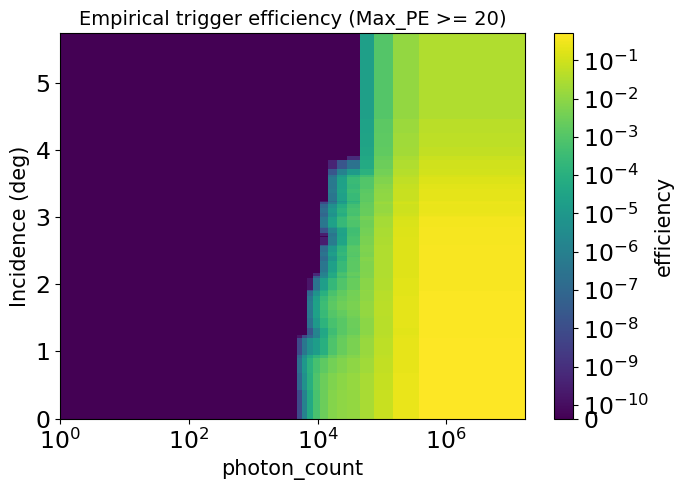

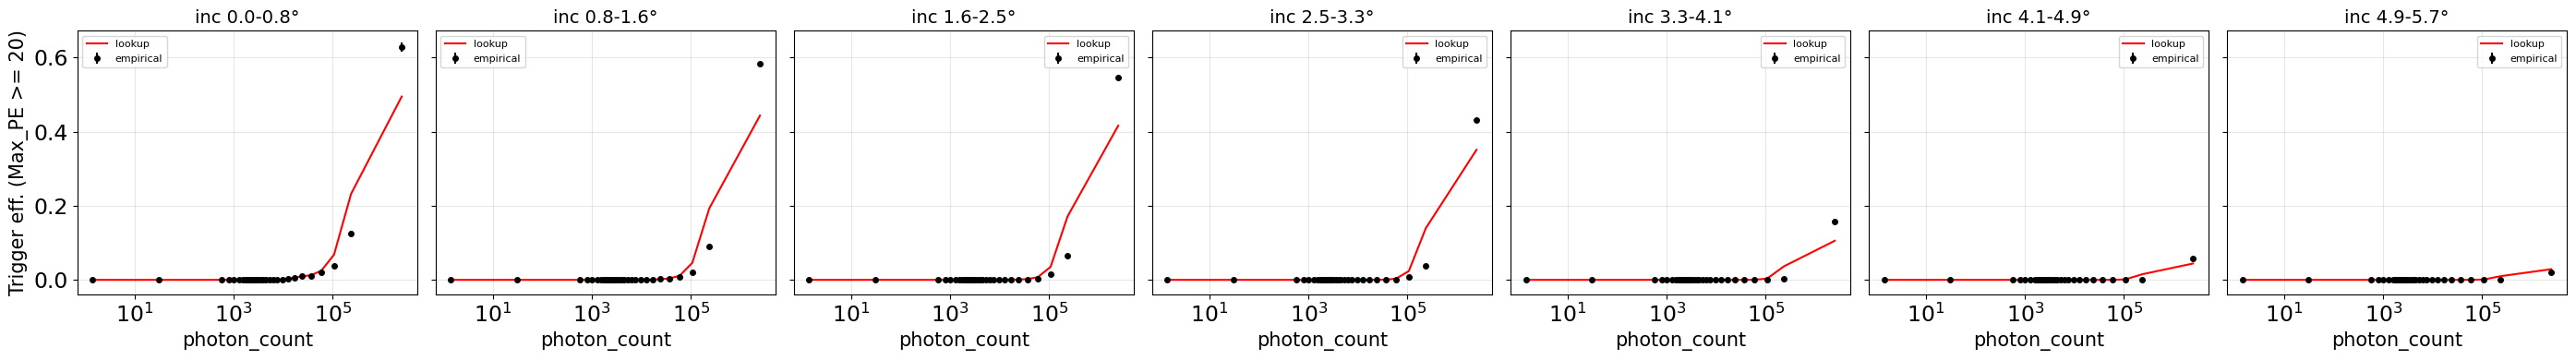

In [6]:
# Empirical trigger efficiency: P(Max_PE >= threshold | photon_count, incidence)
# =============================================================================
from scipy.ndimage import gaussian_filter
from matplotlib.colors import SymLogNorm

# ---------- 1. Clean inputs ----------
m = (np.isfinite(photon_count) & (photon_count > 0)
     & np.isfinite(Max_PE)     & (Max_PE >= 0)
     & np.isfinite(Incidence))
pc_  = photon_count[m]
pe_  = Max_PE[m]
inc_ = Incidence[m]
hit_ = (pe_ >= PE_THRESHOLD).astype(float)

# ---------- 2. Define 2-D bins ----------
pc_edges  = 10**np.quantile(np.log10(pc_), np.linspace(0,1, 50))#np.logspace(np.log10(pc_.min()), np.log10(pc_.max()), 50)
inc_edges = np.quantile(inc_, np.linspace(0,1, 50)) #np.linspace(inc_.min(),inc_.max(), 50)
pc_cen    = np.sqrt(pc_edges[:-1] * pc_edges[1:])
inc_cen   = 0.5*(inc_edges[:-1] + inc_edges[1:])

# ---------- 3. Build empirical efficiency table ----------
N_tot, _, _ = np.histogram2d(pc_, inc_, bins=[pc_edges, inc_edges])
N_hit, _, _ = np.histogram2d(pc_, inc_, bins=[pc_edges, inc_edges], weights=hit_)

with np.errstate(invalid='ignore', divide='ignore'):
    eff = np.where(N_tot >= 5, N_hit / N_tot, np.nan)
    eff_err = np.where(N_tot >= 5, np.sqrt(eff*(1-eff)/N_tot), np.nan)

# Light smoothing to fill noisy bins (optional)
eff_smooth = eff.copy()
mask = np.isfinite(eff_smooth)
eff_smooth[~mask] = 0
weights = mask.astype(float)
sigma_value = 0.8
eff_smooth = gaussian_filter(eff_smooth, sigma=sigma_value) / np.clip(
    gaussian_filter(weights, sigma=sigma_value), 1e-6, None)

# ---------- 4. Lookup function with bilinear interpolation ----------
from scipy.interpolate import RegularGridInterpolator
interp = RegularGridInterpolator(
    (np.log10(pc_cen), inc_cen), eff_smooth,
    bounds_error=False, fill_value=None, method='linear')

def trigger_eff(N_gamma, inc_deg):
    N_gamma = np.asarray(N_gamma, dtype=float)
    inc_deg = np.asarray(inc_deg, dtype=float)
    N_b, inc_b = np.broadcast_arrays(N_gamma, inc_deg)
    pts = np.column_stack([
        np.log10(np.clip(N_b.ravel(), pc_.min(), pc_.max())),
        np.clip(inc_b.ravel(), inc_.min(), inc_.max()),
    ])
    vals = np.clip(interp(pts), 0.0, 1.0)
    return vals.reshape(N_b.shape)

# ---------- 5. Plot the efficiency map ----------
fig, ax = plt.subplots(figsize=(7,5))
pcm = ax.pcolormesh(pc_edges, inc_edges, eff_smooth.T, #eff_smooth.T,
                    cmap='viridis', norm=SymLogNorm(linthresh=np.min(eff_smooth[np.where(eff_smooth>0)]), linscale=0.5, base=10))
ax.set_xscale('log')
ax.set_xlabel("photon_count"); ax.set_ylabel("Incidence (deg)")
ax.set_title(f"Empirical trigger efficiency (Max_PE >= {PE_THRESHOLD})")
plt.colorbar(pcm, ax=ax, label='efficiency')
plt.tight_layout(); plt.show()

# ---------- 6. Slice validation ----------
bounds = np.linspace(inc_.min(), inc_.max(), 8)
slices = list(zip(bounds[:-1], bounds[1:]))
fig, axes = plt.subplots(1, len(slices), figsize=(4*len(slices), 4), sharey=True)
for ax, (ilo, ihi) in zip(axes, slices):
    sel = (inc_ >= ilo) & (inc_ < ihi)
    emp, err = [], []
    for i in range(len(pc_cen)):
        s2 = sel & (pc_ >= pc_edges[i]) & (pc_ < pc_edges[i+1])
        n = s2.sum()
        if n >= 5:
            p = np.mean(hit_[s2]); emp.append(p)
            err.append(np.sqrt(p*(1-p)/n) + 1.0/n)
        else:
            emp.append(np.nan); err.append(np.nan)
    emp, err = np.array(emp), np.array(err)
    pred = trigger_eff(pc_cen, 0.5*(ilo+ihi))
    ax.errorbar(pc_cen, emp, yerr=err, fmt='ko', ms=4, label='empirical')
    ax.plot(pc_cen, pred, 'r-', label='lookup')
    ax.set_xscale('log')#; ax.set_ylim(-0.05, 1.1)
    #ax.set_yscale('log')
    ax.set_xlabel("photon_count")
    ax.set_title(f"inc {ilo:.1f}-{ihi:.1f}°")
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
axes[0].set_ylabel(f"Trigger eff. (Max_PE >= {PE_THRESHOLD})")
plt.tight_layout(); plt.show()


max incidence 5.736265562895281
PER-BIN LOGISTIC FIT DIAGNOSTICS (eff vs photon count, per incidence bin)
Fit equation: eff(logN) = b / (1 + exp(-(logN - x0) / w))
Error bars:   bootstrap 68% CI (N_boot=100)
--------------------------------------------------------------------------------
  inc_mean     b(sat)       +/-b   x0(logN50)      +/-x0    w(logN)       +/-w   chi2/dof     minN
--------------------------------------------------------------------------------
     0.200       1.05       0.81        5.782        0.4      0.244      0.048       0.96    30822
     0.300       1.05       0.51        5.798       0.23      0.241      0.022       1.70    55711
     0.400       1.05          1        5.765       0.56      0.300      0.019       0.97    13932
     0.500       1.05       0.59        5.815       0.28      0.236      0.048       1.48    34134
     0.600       1.05          1        5.821       0.36      0.317      0.047       1.25    13932
     0.700       1.05       0.52    

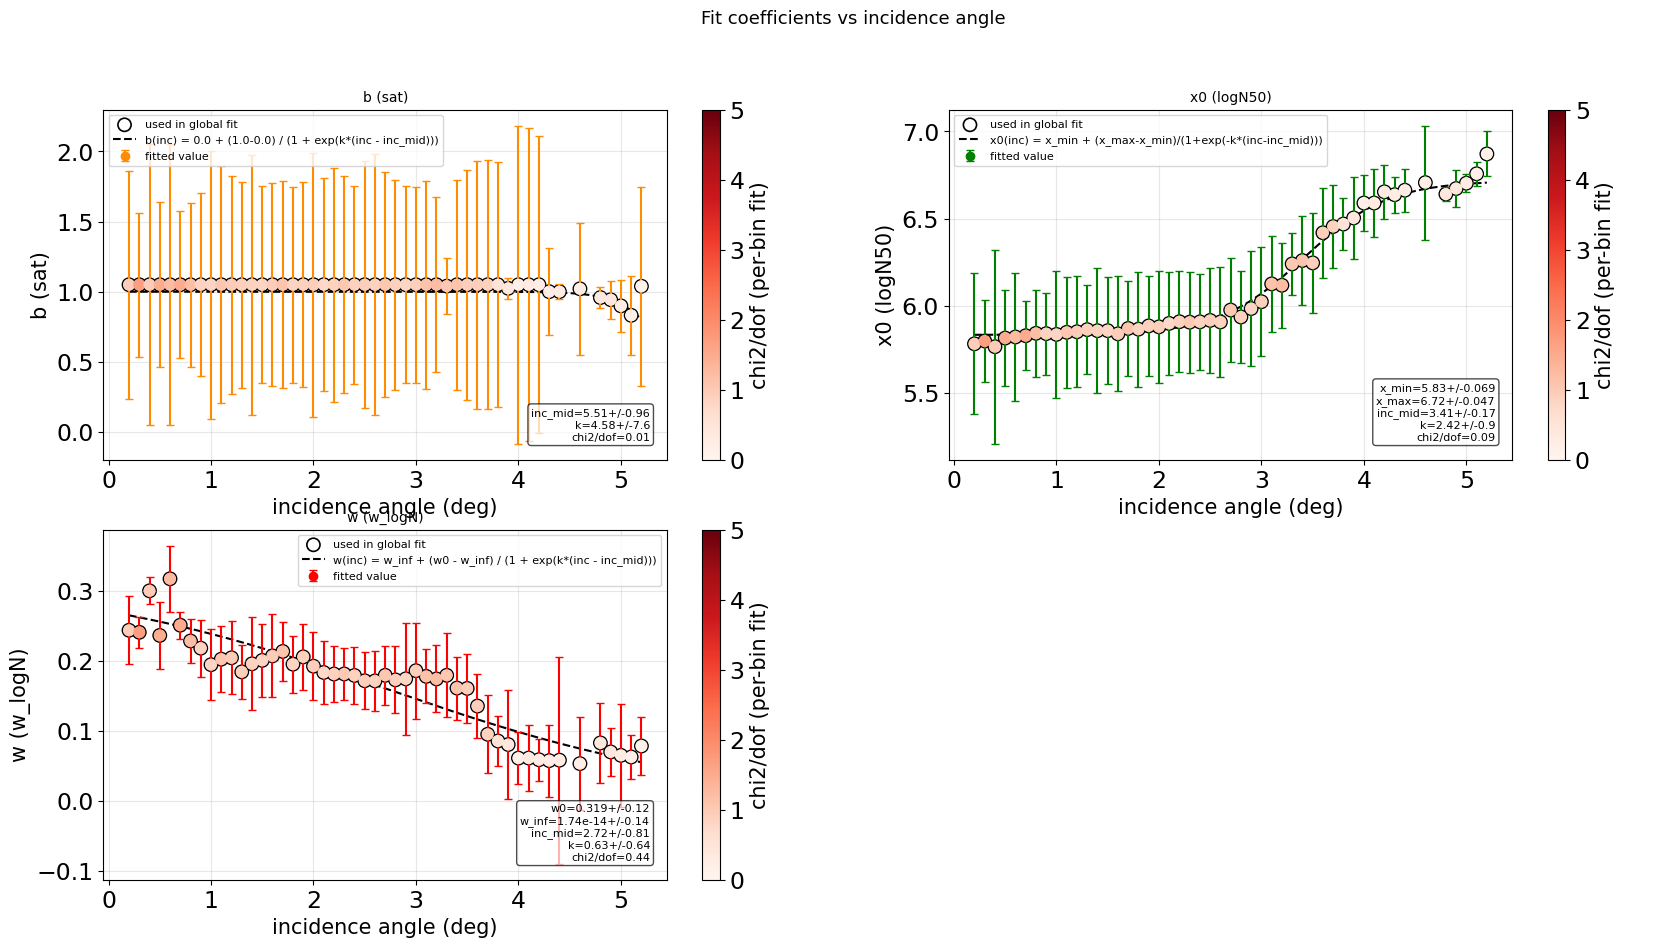


PHYSICAL MODEL FITS (coefficient vs incidence angle)

--- Model for parameter 'b' ---
Equation:  b(inc) = 0.0 + (1.0-0.0) / (1 + exp(k*(inc - inc_mid)))
       inc_mid = 5.507 +/- 0.96
             k = 4.585 +/- 7.6
      chi2/dof = 0.010

--- Model for parameter 'x0' ---
Equation:  x0(inc) = x_min + (x_max-x_min)/(1+exp(-k*(inc-inc_mid)))
         x_min = 5.833 +/- 0.069
         x_max = 6.718 +/- 0.047
       inc_mid = 3.415 +/- 0.17
             k = 2.425 +/- 0.9
      chi2/dof = 0.093

--- Model for parameter 'w' ---
Equation:  w(inc) = w_inf + (w0 - w_inf) / (1 + exp(k*(inc - inc_mid)))
            w0 = 0.319 +/- 0.12
         w_inf = 1.744e-14 +/- 0.14
       inc_mid = 2.722 +/- 0.81
             k = 0.6299 +/- 0.64
      chi2/dof = 0.440


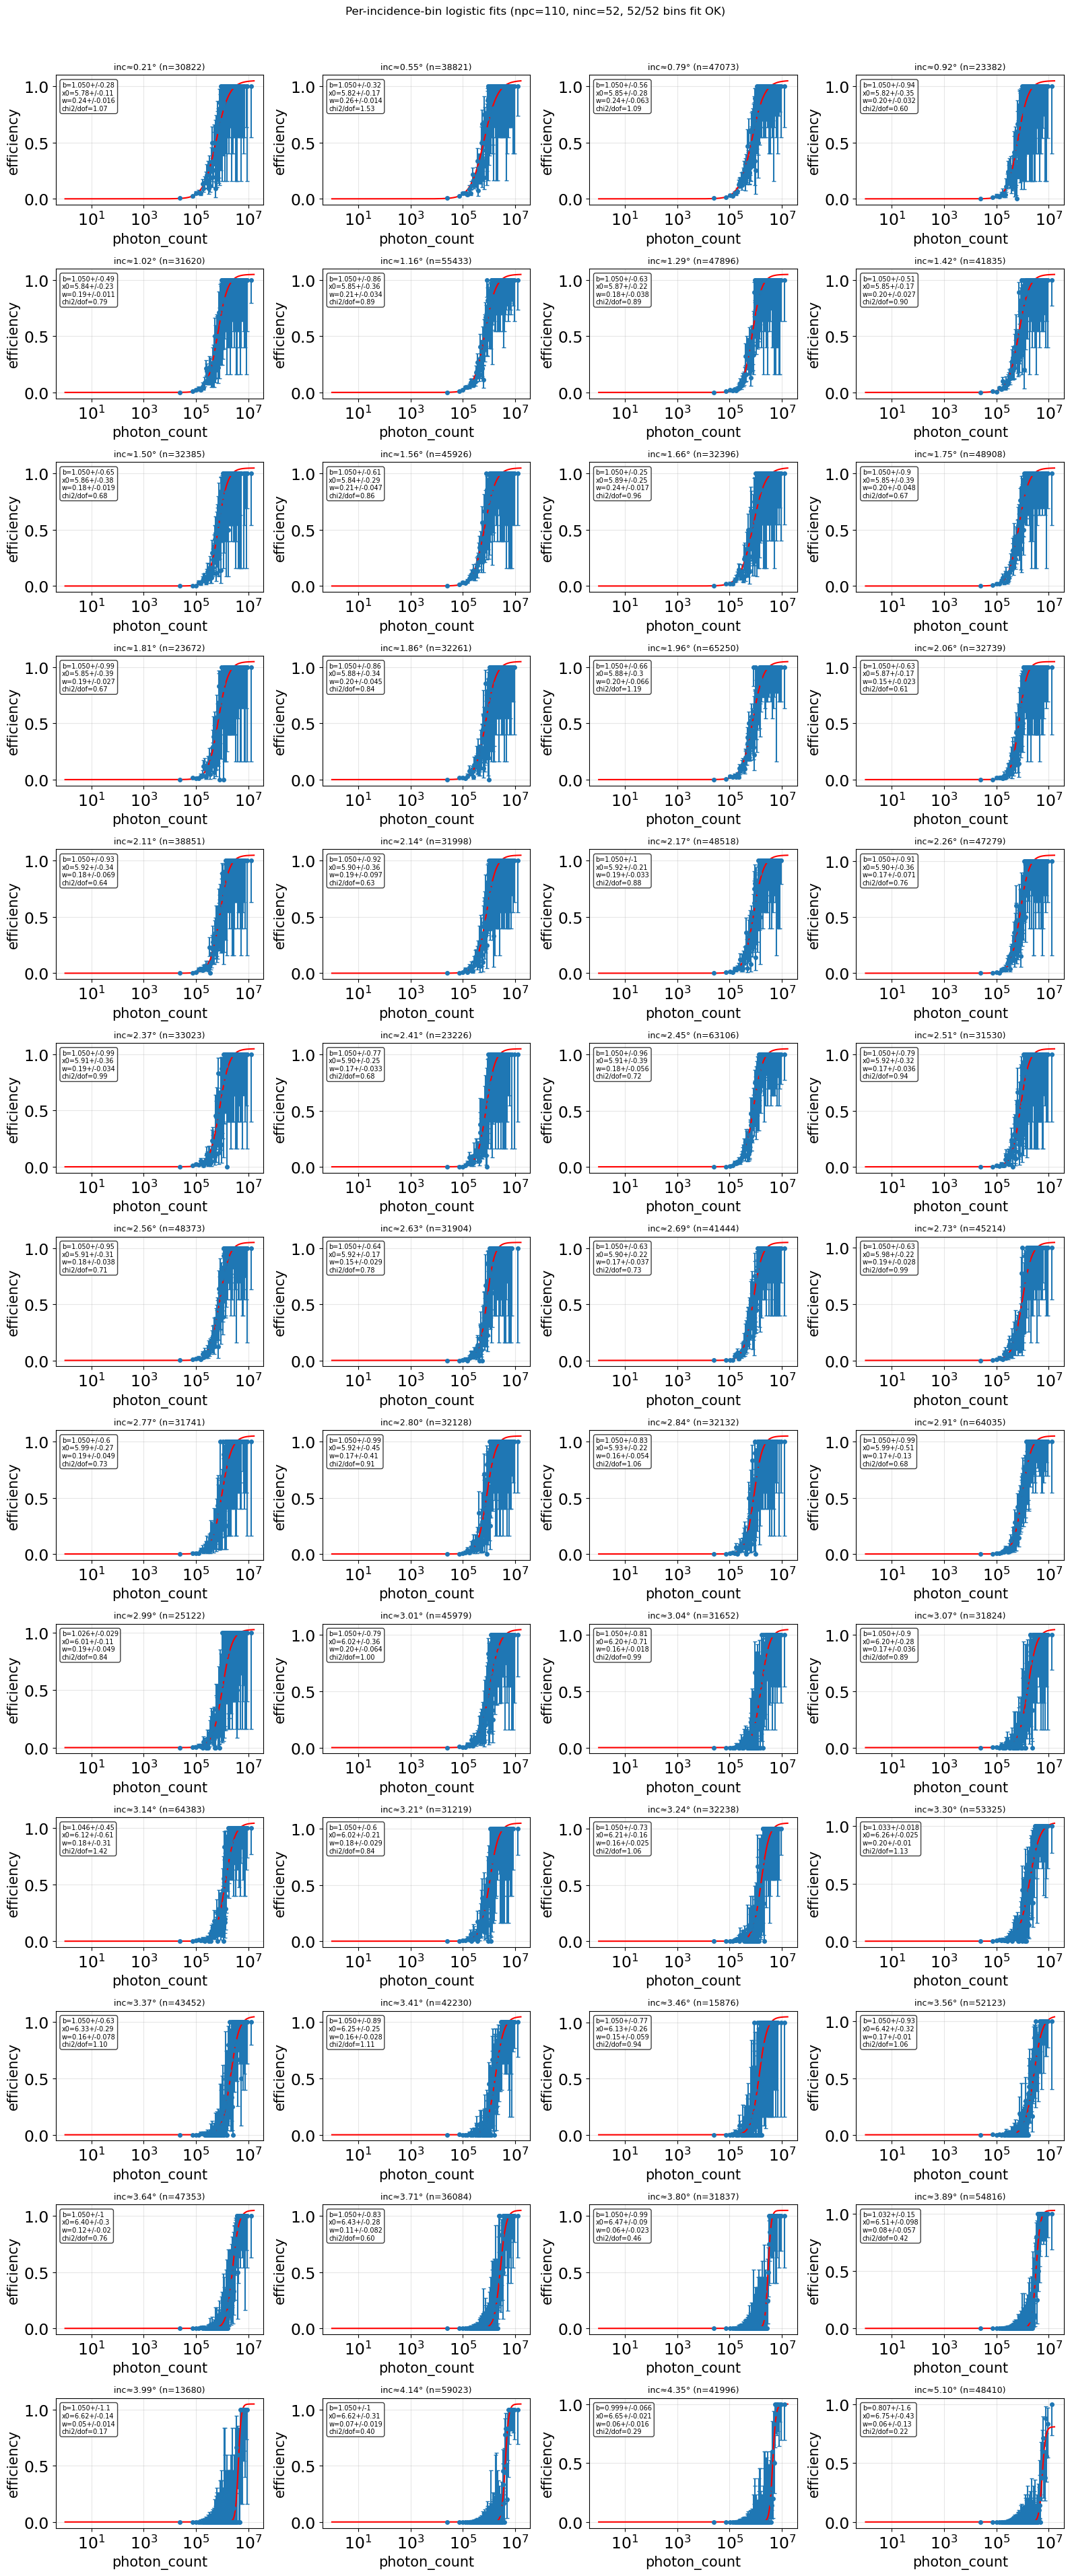

In [11]:
# Fitting Efficiency vs Photon Count Model (per incidence bin)
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy.optimize import curve_fit
from scipy.stats import beta

# --- User settings ---
#PE_THRESHOLD = 5
n_photon_bins = 50
n_inc_bins = 20
ncols = 5

MIN_EVENTS_PER_INC_BIN = 1
MIN_EVENTS_PER_PC_BIN = 1
MIN_TRIGGERS_PER_INC = 1   # minimum total triggers in an incidence slice to attempt a fit
MAX_CHI2_DOF = 10.0
MAX_X0_ERR_LOGN = 1.0
MAX_W_ERR_LOGN = 1.0
EFF_ERR_FLOOR = 0.01
B_ERR_FLOOR = 0.01
W_ERR_FLOOR = 0.01
SATURATION_EFF = 1

B_MODEL  = "sigmoid_fixed"   # options: "const", "linear", "sigmoid"
X0_MODEL = "log_sigmoid"  # options: "linear", "quadratic", "log_sigmoid"
W_MODEL  = "sigmoid"   # options: "const", "linear", "powerlaw", "lognormal", "sigmoid"

N_BIN_VARIATIONS = 20
N_var_per_key_min = 1
NPC_RANGE  = (20, 200)
NINC_RANGE = (5, 100)

N_BOOTSTRAP = 100
CI_LEVEL = 68  # percent 68
CI_ALPHA = (100.0 - CI_LEVEL) / 2.0

_RNG = np.random.default_rng(0)

# ---- preprocess ----
mask = (
    np.isfinite(photon_count) & (photon_count > 0) &
    np.isfinite(Max_PE) & (Max_PE >= 0) &
    np.isfinite(Incidence)
)

pc = photon_count[mask]
inc = Incidence[mask]
pe = Max_PE[mask]
trig = (pe >= PE_THRESHOLD).astype(float)

pc_for_edges = pc[trig>0]
if pc_for_edges.size == 0:
    raise ValueError("No triggered events to define photon-count bin edges.")

#pc_edges = np.logspace(np.log10(pc_for_edges.min()), np.log10(pc_for_edges.max()), n_photon_bins + 1)
pc_edges = 10**(np.quantile(np.log10(pc_for_edges), np.linspace(0, 1, n_photon_bins + 1)))
n_photon_bins = len(pc_edges) - 1
#inc_edges = np.linspace(inc.min(), inc.max(), n_inc_bins + 1)
inc_edges = np.quantile(inc, np.linspace(0, 1, n_inc_bins + 1))

def clopper_pearson(hits, total, alpha=0.32):
    """
    Two-sided Clopper-Pearson binomial CI.
    alpha = 1 - CI_LEVEL/100  (e.g. 0.32 for 68% CI)
    Returns (lo, hi) arrays, same shape as hits/total.
    Handles hits=0 and hits=total correctly (non-zero width).
    """
    hits = np.asarray(hits, dtype=float)
    total = np.asarray(total, dtype=float)
    lo = np.where(hits > 0, beta.ppf(alpha / 2.0, hits, total - hits + 1), 0.0)
    hi = np.where(hits < total, beta.ppf(1.0 - alpha / 2.0, hits + 1, total - hits), 1.0)
    return lo, hi

from scipy.optimize import minimize

def fit_binomial_logistic(logN_bin, hits_bin, total_bin, p0_lw, bounds_lw):
    """
    Fit logistic to binomial counts via maximum likelihood.
    Returns (popt, perr, pcov, chi2_dof_like) in (b, x0, w) parameterization.
    """
    def nll(params):
        b, x0, log_w = params
        w = np.exp(log_w)
        p = logistic_logN(logN_bin, b, x0, w)
        p = np.clip(p, 1e-12, 1 - 1e-12)
        return -np.sum(hits_bin * np.log(p) + (total_bin - hits_bin) * np.log(1 - p))

    scipy_bounds = list(zip(bounds_lw[0], bounds_lw[1]))
    res_fit = minimize(nll, x0=p0_lw, method="L-BFGS-B",
                       bounds=scipy_bounds, options={"maxiter": 5000})

    if not res_fit.success:
        raise RuntimeError(f"NLL fit failed: {res_fit.message}")

    popt_lw = res_fit.x
    # Covariance from inverse Hessian (BFGS approximation)
    try:
        hess_inv = res_fit.hess_inv.todense() if hasattr(res_fit.hess_inv, "todense") else np.array(res_fit.hess_inv)
        pcov_lw = hess_inv
    except Exception:
        pcov_lw = np.eye(3) * np.nan

    # Convert to (b, x0, w) space
    popt = np.array([popt_lw[0], popt_lw[1], np.exp(popt_lw[2])])
    perr_lw = np.sqrt(np.maximum(np.diag(pcov_lw), 0.0))
    perr = np.array([perr_lw[0], perr_lw[1], np.exp(popt_lw[2]) * perr_lw[2]])

    pcov = pcov_lw.copy()
    pcov[2, :] *= np.exp(popt_lw[2])
    pcov[:, 2] *= np.exp(popt_lw[2])

    # Pseudo chi2/dof using binomial deviance
    p_fit = np.clip(logistic_logN(logN_bin, *popt), 1e-12, 1 - 1e-12)
    p_obs = np.clip(hits_bin / np.maximum(total_bin, 1), 1e-12, 1 - 1e-12)
    dev = 2.0 * np.sum(
        hits_bin * np.log(p_obs / p_fit) +
        (total_bin - hits_bin) * np.log((1 - p_obs) / (1 - p_fit))
    )
    dof = len(logN_bin) - 3
    chi2_dof = dev / dof if dof > 0 else np.nan
    return popt, perr, pcov, chi2_dof


def logistic_logN(logN, b, x0, w):
    exponent = np.clip(-(logN - x0) / w, -500, 500)
    return b / (1.0 + np.exp(exponent))

# ---- helper: compute bootstrap eff/err arrays for a slice ----
def compute_bootstrap_arrays(pc_slice, trig_slice, pc_edges_v, rng=_RNG):
    n_bins = len(pc_edges_v) - 1

    idx = np.digitize(pc_slice, pc_edges_v) - 1
    valid = (idx >= 0) & (idx < n_bins)
    idx = idx[valid]
    t = trig_slice[valid]

    total = np.bincount(idx, minlength=n_bins).astype(int)
    hits = np.bincount(idx, weights=t, minlength=n_bins)

    with np.errstate(invalid="ignore", divide="ignore"):
        p_hat = np.where(total > 0, hits / np.maximum(total, 1), np.nan)

    # Clopper-Pearson CI (replaces bootstrap)
    alpha_cp = 1.0 - CI_LEVEL / 100.0
    safe_total = np.maximum(total, 1)
    lo, hi = clopper_pearson(hits, safe_total, alpha=alpha_cp)

    # Mask empty bins
    empty = (total == 0)
    p_hat[empty] = np.nan
    lo = np.where(empty, np.nan, lo)
    hi = np.where(empty, np.nan, hi)

    err_lo = p_hat - lo
    err_hi = hi - p_hat
    err = np.maximum((hi - lo) / 2.0, EFF_ERR_FLOOR)
    err[empty] = np.nan

    # Also return hits for use in likelihood fit (Step 2)
    return p_hat, err, err_lo, err_hi, total, hits

def fit_one_inc_bin(inc_lo, inc_hi, pc_edges_v, rng):
    inc_center = 0.5 * (inc_lo + inc_hi)
    sub = (inc >= inc_lo) & (inc < inc_hi)
    n_sub = int(sub.sum())

    res = {
        "inc_lo": inc_lo,
        "inc_hi": inc_hi,
        "inc_center": inc_center,
        "n_sub": n_sub,
        "ok": False,
        "skip_reason": None,
    }

    if n_sub < MIN_EVENTS_PER_INC_BIN:
        res["skip_reason"] = "low_events"
        return res

    pc_sub = pc[sub]
    trig_sub = trig[sub]

    eff, err, err_lo, err_hi, total, hits = compute_bootstrap_arrays(
        pc_sub, trig_sub, pc_edges_v, rng=rng
    )
    pc_centers = np.sqrt(pc_edges_v[:-1] * pc_edges_v[1:])
    res.update({
        "pc_centers": pc_centers,
        "eff": eff,
        "err": err,
        "err_lo": err_lo,
        "err_hi": err_hi,
        "total": total,
        "hits": hits,
    })

    eff_valid = eff[np.isfinite(eff)]
    saturated = bool(eff_valid.size > 0 and np.all(eff_valid >= SATURATION_EFF))
    good = np.isfinite(eff) & (total >= MIN_EVENTS_PER_PC_BIN)

    # Need some triggers somewhere in this slice to constrain x0
    n_triggers = int(hits.sum())
    if n_triggers < MIN_TRIGGERS_PER_INC:
        res["skip_reason"] = "no_triggers"
        return res

    res.update({
        "good": good,
        "saturated": saturated,
        "n_triggers": n_triggers,
        "min_total": int(np.min(total[total > 0])) if np.any(total > 0) else 0,
    })

    if good.sum() < 3:
        res["skip_reason"] = "low_stats"
        return res

    if saturated:
        res["skip_reason"] = "saturated"
        return res

    # ---- Prepare data for binomial NLL fit ----
    xd = np.log10(pc_centers[good])
    hits_g = hits[good].astype(float)
    total_g = total[good].astype(float)

    # Initial guess from observed efficiencies
    yd_init = hits_g / np.maximum(total_g, 1.0)
    x_range = xd.max() - xd.min()
    b0 = min(max(np.nanmax(yd_init), 0.05), 1.0)
    x0_0 = xd[np.argmin(np.abs(yd_init - 0.5 * b0))]
    w0 = max(0.1 * x_range, 1e-3)

    p0_lw = [b0, x0_0, np.log(max(w0, 1e-3))]
    bounds_lw = (
        [0.0,  xd.min() - 2.0, np.log(1e-3)],
        [1.05, xd.max() + 3.0, np.log(5.0)],
    )

    try:
        popt, perr, pcov, chi2_dof = fit_binomial_logistic(
            xd, hits_g, total_g, p0_lw, bounds_lw
        )
    except Exception:
        res["skip_reason"] = "fit_failed"
        return res

    # Floor on w uncertainty (always positive, physically meaningful)
    perr[2] = max(perr[2], W_ERR_FLOOR)

    # Flag extrapolated x0 (true 50% point lies outside the data range)
    x0_fit = popt[1]
    x0_extrapolated = bool((x0_fit < xd.min()) or (x0_fit > xd.max()))

    # Quality cuts
    ok = True
    if not np.isfinite(chi2_dof) or chi2_dof >= MAX_CHI2_DOF:
        ok = False
    if perr[1] >= MAX_X0_ERR_LOGN or perr[2] >= MAX_W_ERR_LOGN:
        ok = False

    res.update({
        "popt": popt,
        "perr": perr,
        "chi2_dof": chi2_dof,
        "x0_extrapolated": x0_extrapolated,
        "ok": ok,
    })

    if not ok:
        res["skip_reason"] = "quality_cuts"

    return res



# ======================================================================
# Bin-variation loop (binning systematic)
# ======================================================================
agg = defaultdict(list)
agg_perr = defaultdict(list)
agg_chi2 = defaultdict(list)
agg_nsub = defaultdict(list)
agg_skip = defaultdict(lambda: defaultdict(int))

log_pc     = np.log10(pc_for_edges)
log_pc_min = np.log10(pc_for_edges.min())
log_pc_max = np.log10(pc_for_edges.max())

bin_results = [] if N_BIN_VARIATIONS == 1 else None
print("max incidence", max(inc))
for v in range(N_BIN_VARIATIONS):
    rng_v = np.random.default_rng(1000 + v)
    if N_BIN_VARIATIONS == 1:
        npc = n_photon_bins
        ninc = n_inc_bins
    else:
        npc = int(rng_v.integers(NPC_RANGE[0], NPC_RANGE[1] + 1))
        ninc = int(rng_v.integers(NINC_RANGE[0], NINC_RANGE[1] + 1))

    #pc_edges_v = np.logspace(log_pc_min, log_pc_max, npc + 1)
    pc_edges_v = 10**np.quantile(log_pc, np.linspace(0, 1, npc + 1))
    #inc_edges_v = np.linspace(inc.min(), inc.max(), ninc + 1)
    inc_edges_v = np.quantile(inc, np.linspace(0, 1, ninc + 1))
    for i in range(ninc):
        inc_lo, inc_hi = inc_edges_v[i], inc_edges_v[i + 1]
        res = fit_one_inc_bin(inc_lo, inc_hi, pc_edges_v, rng_v)

        if N_BIN_VARIATIONS == 1:
            bin_results.append(res)

        if not res.get("ok", False):
            reason = res.get("skip_reason", "unknown")
            key_r = round(res["inc_center"], 1)
            agg_skip[key_r][reason] += 1
            continue

        key = round(res["inc_center"], 1)
        agg[key].append(res["popt"])
        agg_perr[key].append(res["perr"])
        agg_chi2[key].append(res["chi2_dof"])
        agg_nsub[key].append(res["n_sub"])

# ======================================================================
# Aggregate across binning variations
# ======================================================================
keys_sorted = sorted(agg.keys())
inc_means = np.array(keys_sorted)

b_vals  = np.array([np.median([p[0] for p in agg[k]]) for k in keys_sorted])
x0_vals = np.array([np.median([p[1] for p in agg[k]]) for k in keys_sorted])
w_vals  = np.array([np.median([p[2] for p in agg[k]]) for k in keys_sorted])


def _combined_err(popts, perrs, idx):
    vals = np.array([p[idx] for p in popts])
    stat = np.array([e[idx] for e in perrs])
    syst = vals.std(ddof=1) if len(vals) > 1 else 0.0
    return np.sqrt(np.median(stat) ** 2 + syst ** 2)


b_errs  = np.array([_combined_err(agg[k], agg_perr[k], 0) for k in keys_sorted])
x0_errs = np.array([_combined_err(agg[k], agg_perr[k], 1) for k in keys_sorted])
w_errs  = np.array([_combined_err(agg[k], agg_perr[k], 2) for k in keys_sorted])

chi2_vals = np.array([np.median(agg_chi2[k]) for k in keys_sorted])
n_variations_per_key = np.array([len(agg[k]) for k in keys_sorted])
min_counts = np.array([int(np.median(agg_nsub[k])) for k in keys_sorted])

finite_mask = np.isfinite(b_vals) & np.isfinite(x0_vals) & np.isfinite(w_vals)
stats_mask = n_variations_per_key >= N_var_per_key_min #max(3, N_BIN_VARIATIONS // 10)
chi2_mask = chi2_vals < MAX_CHI2_DOF
quality_mask = finite_mask & stats_mask & chi2_mask

# ======================================================================
# Diagnostics print
# ======================================================================
print("=" * 80)
print("PER-BIN LOGISTIC FIT DIAGNOSTICS (eff vs photon count, per incidence bin)")
print("=" * 80)
print("Fit equation: eff(logN) = b / (1 + exp(-(logN - x0) / w))")
print(f"Error bars:   bootstrap {CI_LEVEL:.0f}% CI (N_boot={N_BOOTSTRAP})")
print("-" * 80)
print(f"{'inc_mean':>10} {'b(sat)':>10} {'+/-b':>10} {'x0(logN50)':>12} "
      f"{'+/-x0':>10} {'w(logN)':>10} {'+/-w':>10} {'chi2/dof':>10} {'minN':>8}")
print("-" * 80)
for i in range(len(inc_means)):
    print(f"{inc_means[i]:10.3f} "
          f"{b_vals[i]:10.3g} {b_errs[i]:10.2g} "
          f"{x0_vals[i]:12.3f} {x0_errs[i]:10.2g} "
          f"{w_vals[i]:10.3f} {w_errs[i]:10.2g} "
          f"{chi2_vals[i]:10.2f} {min_counts[i]:8d}")
print("-" * 80)
print(f"Bins fitted: {len(inc_means)} | Bins used for global fits: {int(np.sum(quality_mask))}")
print("=" * 80)
print("\nBIN STABILITY ACROSS BINNING VARIATIONS (skip_reason counts):")
print(f"{'inc_mean':>10} {'ok_count':>10} {'low_events':>12} {'low_stats':>10} "
      f"{'saturated':>10} {'fit_failed':>10} {'quality_cuts':>13} {'unknown':>8}")
print("-" * 90)
for k in keys_sorted:
    n_ok  = len(agg[k])
    skips = agg_skip.get(k, {})
    print(f"{k:10.3f} {n_ok:10d} "
          f"{skips.get('low_events', 0):12d} "
          f"{skips.get('low_stats', 0):10d} "
          f"{skips.get('saturated', 0):10d} "
          f"{skips.get('fit_failed', 0):10d} "
          f"{skips.get('quality_cuts', 0):13d} "
          f"{skips.get('unknown', 0):8d}")
print("-" * 90)
print(f"Note: ok_count + all skip counts should sum to approximately "
      f"N_BIN_VARIATIONS={N_BIN_VARIATIONS} per row (variation in ninc "
      f"means not every variation produces an inc bin at that center).")
dropped = ~quality_mask
if np.any(dropped):
    print("\nBins EXCLUDED from global fits:")
    print(f"{'inc_mean':>10} {'b/err_b':>10} {'chi2/dof':>10} {'minN':>8}  reasons")
    min_req = N_var_per_key_min #max(3, N_BIN_VARIATIONS // 10)
    for i in np.where(dropped)[0]:
        reasons = []
        if not finite_mask[i]:
            reasons.append("nonfinite")
        if not stats_mask[i]:
            reasons.append(f"minN<{min_req}")
        if not chi2_mask[i]:
            reasons.append(f"chi2>{MAX_CHI2_DOF}")
        bs = b_vals[i] / b_errs[i] if np.isfinite(b_errs[i]) and b_errs[i] > 0 else 0.0
        print(f"{inc_means[i]:10.3f} {bs:10.2f} {chi2_vals[i]:10.2f} "
              f"{min_counts[i]:8d}  " + ", ".join(reasons))

if len(inc_means) == 0:
    raise RuntimeError("No valid incidence bins available for global fits.")

# ======================================================================
# Global models: b(inc), x0(inc), w(inc)
# ======================================================================

def b_const(inc_deg, b0):
    return np.full_like(inc_deg, b0, dtype=float)


def b_linear(inc_deg, b0, s):
    return b0 + s * inc_deg

def b_sigmoid(inc_deg, b0=1.0, b_inf=0.5, inc_mid=4.75, k=4.0):
    """b at low inc -> b_inf at high inc, transition at inc_mid with steepness k."""
    return b_inf + (b0 - b_inf) / (1.0 + np.exp(k * (inc_deg - inc_mid)))

B0_FIXED = 1.0      # set to whatever value you want
B_INF_FIXED = 0.0   # set to whatever value you want

def b_sigmoid_fixed(inc_deg, inc_mid, k):
    return B_INF_FIXED + (B0_FIXED - B_INF_FIXED) / (1.0 + np.exp(k * (inc_deg - inc_mid)))


def x0_linear(inc_deg, a, s):
    return a + s * inc_deg


def x0_quadratic(inc_deg, a, s, q):
    return a + s * inc_deg + q * inc_deg**2


def x0_log_sigmoid(inc_deg, x_min, x_max, inc_mid, k):
    return x_min + (x_max - x_min) / (1.0 + np.exp(-k * (inc_deg - inc_mid)))


def w_const(inc_deg, w0):
    return np.full_like(inc_deg, w0, dtype=float)


def w_linear(inc_deg, w0, s):
    return w0 + s * inc_deg


def w_powerlaw(inc_deg, w0, k):
    return w0 * (1.0 + inc_deg) ** k


def w_lognormal(inc_deg, w0, mu, sigma):
    # Gaussian in log(inc); guard inc>0
    x = np.log(np.maximum(inc_deg, 1e-6))
    return w0 * np.exp(-((x - mu) / sigma) ** 2)

def w_sigmoid(inc_deg, w0, w_inf, inc_mid, k):
    # w0 at low inc, w_inf at high inc, transition at inc_mid with steepness k
    return w_inf + (w0 - w_inf) / (1.0 + np.exp(k * (inc_deg - inc_mid)))

inc_min = float(np.min(inc_means)) if len(inc_means) else float(np.min(inc))
inc_max = 10 #float(np.max(inc_means)) if len(inc_means) else float(np.max(inc))
x0_min = float(np.nanmin(x0_vals)) if len(x0_vals) else np.log10(pc_for_edges.min())
x0_max = float(np.nanmax(x0_vals)) if len(x0_vals) else np.log10(pc_for_edges.max())

b_model_cfg = {
    "const": {
        "fn": b_const,
        "p0": [np.nanmedian(b_vals)],
        "bounds": ([0.0], [1.05]),
        "label": "b(inc) = b0",
        "param_names": ["b0"],
    },
    "linear": {
        "fn": b_linear,
        "p0": [np.nanmedian(b_vals), 0.0],
        "bounds": ([0.0, -0.1], [1.05, 0.1]),
        "label": "b(inc) = b0 + s*inc",
        "param_names": ["b0", "s"],
    },
    "sigmoid": {
        "fn": b_sigmoid,
        "p0": [1.0, 0.0, 4.75, 4.0],
        "bounds": (
            [0.5, 0.0, inc_min, 0.0001],
            [1.05, 0.0001, inc_max, 10.0],
        ),
        "label": "b(inc) = b_inf + (b0 - b_inf) / (1 + exp(k*(inc - inc_mid)))",
        "param_names": ["b0", "b_inf", "inc_mid", "k"],
    },
    "sigmoid_fixed": {
        "fn": b_sigmoid_fixed,
        "p0": [4.75, 4.0],
        "bounds": (
            [inc_min, 0.0001],
            [inc_max, 10.0],
        ),
        "label": f"b(inc) = {B_INF_FIXED} + ({B0_FIXED}-{B_INF_FIXED}) / (1 + exp(k*(inc - inc_mid)))",
        "param_names": ["inc_mid", "k"],
    },
}

x0_model_cfg = {
    "linear": {
        "fn": x0_linear,
        "p0": [np.nanmedian(x0_vals), 0.0],
        "bounds": ([x0_min - 2.0, -1.0], [x0_max + 2.0, 1.0]),
        "label": "x0(inc) = a + s*inc",
        "param_names": ["a", "s"],
    },
    "quadratic": {
        "fn": x0_quadratic,
        "p0": [np.nanmedian(x0_vals), 0.0, 0.0],
        "bounds": ([x0_min - 2.0, -1.0, -0.1], [x0_max + 2.0, 1.0, 0.1]),
        "label": "x0(inc) = a + s*inc + q*inc^2",
        "param_names": ["a", "s", "q"],
    },
    "log_sigmoid": {
        "fn": x0_log_sigmoid,
        "p0": [x0_min, x0_max, 0.5 * (inc_min + inc_max), 1.0],
        "bounds": ([x0_min - 2.0, x0_min, inc_min, 0.01],
                   [x0_max, x0_max + 2.0, inc_max, 10.0]),
        "label": "x0(inc) = x_min + (x_max-x_min)/(1+exp(-k*(inc-inc_mid)))",
        "param_names": ["x_min", "x_max", "inc_mid", "k"],
    },
}

w_model_cfg = {
    "const": {
        "fn": w_const,
        "p0": [np.nanmedian(w_vals)],
        "bounds": ([1e-3], [5.0]),
        "label": "w(inc) = w0",
        "param_names": ["w0"],
    },
    "linear": {
        "fn": w_linear,
        "p0": [np.nanmedian(w_vals), 0.0],
        "bounds": ([1e-3, -1.0], [5.0, 1.0]),
        "label": "w(inc) = w0 + s*inc",
        "param_names": ["w0", "s"],
    },
    "powerlaw": {
        "fn": w_powerlaw,
        "p0": [np.nanmedian(w_vals), 0.0],
        "bounds": ([1e-3, -3.0], [5.0, 3.0]),
        "label": "w(inc) = w0 * (1 + inc)^k",
        "param_names": ["w0", "k"],
    },
    "lognormal": {
        "fn": w_lognormal,
        "p0": [np.nanmax(w_vals),
               np.log(max(inc_means[np.nanargmax(w_vals)], 1e-3)),
               1.0],
        "bounds": ([1e-3, np.log(max(inc_min, 1e-3)) - 5.0, 1e-2],
                   [5.0,  np.log(max(inc_max, 1e-3)) + 5.0, 10.0]),
        "label": "w(inc) = w0 * exp(-((log(inc) - mu)/sigma)^2)",
        "param_names": ["w0", "mu", "sigma"],
    },
    "sigmoid": {
        "fn": w_sigmoid,
        "p0": [
            np.nanmedian(w_vals),                 # w0: low-inc plateau
            min(0.01, np.nanmin(w_vals)),         # w_inf: high-inc asymptote
            0.5 * (inc_min + inc_max),            # inc_mid: transition point
            5.0,                                  # k: steepness
        ],
        "bounds": (
            [1e-3, 0.0, inc_min, 0.01],
            [5.0,  5.0, inc_max, 100.0],
        ),
        "label": "w(inc) = w_inf + (w0 - w_inf) / (1 + exp(k*(inc - inc_mid)))",
        "param_names": ["w0", "w_inf", "inc_mid", "k"],
    },
}

if B_MODEL not in b_model_cfg:
    raise ValueError(f"Unknown B_MODEL='{B_MODEL}'. Use 'const' or 'linear', or 'sigmoid', or 'sigmoid_fixed'.")
if X0_MODEL not in x0_model_cfg:
    raise ValueError(f"Unknown X0_MODEL='{X0_MODEL}'. Use 'linear', 'quadratic', or 'log_sigmoid'.")
if W_MODEL not in w_model_cfg:
    raise ValueError(f"Unknown W_MODEL='{W_MODEL}'. Use 'const', 'linear', 'powerlaw', 'lognormal', or 'sigmoid'.")


b_model = b_model_cfg[B_MODEL]
x0_model = x0_model_cfg[X0_MODEL]
w_model = w_model_cfg[W_MODEL]


def fit_model(fn, xdata, ydata, yerr, p0, bounds):
    sigma = np.where(yerr > 0, yerr, EFF_ERR_FLOOR)
    popt, pcov = curve_fit(
        fn, xdata, ydata, p0=p0, sigma=sigma,
        absolute_sigma=True, bounds=bounds, maxfev=20000
    )
    perr = np.sqrt(np.diag(pcov))
    residuals = ydata - fn(xdata, *popt)
    chi2 = np.sum((residuals / sigma) ** 2)
    dof = len(xdata) - len(popt)
    chi2_dof = chi2 / dof if dof > 0 else np.nan
    return popt, perr, pcov, chi2_dof


results = {}
results_meta = {}

ok_b = quality_mask & np.isfinite(b_errs)
ok_x0 = quality_mask & np.isfinite(x0_errs)
ok_w = quality_mask & np.isfinite(w_errs)

try:
    popt, perr, pcov, c2 = fit_model(
        b_model["fn"], inc_means[ok_b], b_vals[ok_b],
        np.maximum(b_errs[ok_b], B_ERR_FLOOR),
        p0=b_model["p0"], bounds=b_model["bounds"],
    )
    results["b"] = (popt, perr, pcov)
    results_meta["b"] = {"chi2_dof": c2, "model": B_MODEL}
except Exception as e:
    print(f"b model fit failed: {e}")

try:
    popt, perr, pcov, c2 = fit_model(
        x0_model["fn"], inc_means[ok_x0], x0_vals[ok_x0],
        np.maximum(x0_errs[ok_x0], W_ERR_FLOOR),
        p0=x0_model["p0"], bounds=x0_model["bounds"],
    )
    results["x0"] = (popt, perr, pcov)
    results_meta["x0"] = {"chi2_dof": c2, "model": X0_MODEL}
except Exception as e:
    print(f"x0 model fit failed: {e}")

try:
    popt, perr, pcov, c2 = fit_model(
        w_model["fn"], inc_means[ok_w], w_vals[ok_w],
        np.maximum(w_errs[ok_w], W_ERR_FLOOR),
        p0=w_model["p0"], bounds=w_model["bounds"],
    )
    results["w"] = (popt, perr, pcov)
    results_meta["w"] = {"chi2_dof": c2, "model": W_MODEL}
except Exception as e:
    print(f"w model fit failed: {e}")
# ======================================================================
# Empirical cross-group correlation of (b, x0, w) from binning variations
# ======================================================================
# For each quality-masked incidence bin, agg[k] holds a list of (b, x0, w)
# triplets — one per binning variation that passed quality cuts. The empirical
# 3x3 covariance of those triplets captures how b, x0, w co-vary in practice.
# Pooling across bins gives a representative correlation matrix that Cell 4
# uses to populate the off-diagonal blocks of the joint parameter covariance.

_emp_covs_list = []
for k, qm in zip(keys_sorted, quality_mask):
    if not qm:
        continue
    if len(agg[k]) < 4:          # need at least 4 samples for a meaningful estimate
        continue
    _triplets = np.array(agg[k])  # (n_variations, 3): columns = [b, x0, w]
    _emp_covs_list.append(np.cov(_triplets.T))   # (3, 3)

if len(_emp_covs_list) > 0:
    _EMP_JOINT_COV_3x3_raw = np.mean(_emp_covs_list, axis=0)   # (3, 3) pooled

    # Convert to correlation matrix: C_ij / (sigma_i * sigma_j)
    _std3 = np.sqrt(np.maximum(np.diag(_EMP_JOINT_COV_3x3_raw), 0.0))
    _outer_std = np.outer(_std3, _std3)
    EMP_JOINT_CORR_3x3 = np.where(
        _outer_std > 0,
        _EMP_JOINT_COV_3x3_raw / _outer_std,
        0.0,
    )
    # Clip to valid correlation range for numerical safety
    np.clip(EMP_JOINT_CORR_3x3, -1.0, 1.0, out=EMP_JOINT_CORR_3x3)
    # Force exact diagonal = 1 (rounding can push it slightly off)
    np.fill_diagonal(EMP_JOINT_CORR_3x3, 1.0)

    print("\nEmpirical cross-group correlation matrix (b, x0, w):")
    print(f"  Pooled from {len(_emp_covs_list)} quality bins "
          f"(min 4 variations each)")
    print(f"  ρ(b,  x0) = {EMP_JOINT_CORR_3x3[0, 1]:.4f}")
    print(f"  ρ(b,   w) = {EMP_JOINT_CORR_3x3[0, 2]:.4f}")
    print(f"  ρ(x0,  w) = {EMP_JOINT_CORR_3x3[1, 2]:.4f}")
else:
    EMP_JOINT_CORR_3x3 = np.eye(3, dtype=float)
    print("\nWarning: no quality bins had >= 4 binning variations. "
          "EMP_JOINT_CORR_3x3 set to identity (zero cross-group correlations).")

del _emp_covs_list
# ======================================================================
# Comparison plot: coefficients vs incidence
# ======================================================================
fig, axes = plt.subplots(2, 2, figsize=(20, 10))
axes = axes.ravel()

inc_smooth = np.linspace(inc_means.min(), inc_means.max(), 300)

labels = ["b (sat)", "x0 (logN50)", "w (w_logN)"]
yvals = [b_vals, x0_vals, w_vals]
yerrs = [b_errs, x0_errs, w_errs]
colors = ["darkorange", "green", "red"]
model_keys = ["b", "x0", "w"]
model_fns = [b_model["fn"], x0_model["fn"], w_model["fn"]]
model_labels = {
    "b": b_model["label"],
    "x0": x0_model["label"],
    "w": w_model["label"],
}
param_names = {
    "b": b_model["param_names"],
    "x0": x0_model["param_names"],
    "w": w_model["param_names"],
}

for ax, lbl, yv, ye, col, mkey, mfn in zip(
        axes[:len(labels)], labels, yvals, yerrs, colors, model_keys, model_fns):

    qm = quality_mask
    ax.errorbar(inc_means[qm], yv[qm], yerr=ye[qm], fmt="o", color=col,
                capsize=3, label="fitted value", zorder=3)
    sc = ax.scatter(inc_means[qm], yv[qm], c=chi2_vals[qm], cmap="Reds",
                    vmin=0, vmax=5, zorder=5, s=60)
    plt.colorbar(sc, ax=ax, label="chi2/dof (per-bin fit)")
    ax.scatter(inc_means[qm], yv[qm],
               facecolors="none", edgecolors="black", s=90,
               linewidths=1.2, label="used in global fit")

    if mkey in results:
        popt, perr, _ = results[mkey]
        c2 = results_meta.get(mkey, {}).get("chi2_dof", np.nan)
        ax.plot(inc_smooth, mfn(inc_smooth, *popt), "k--",
                lw=1.5, label=model_labels[mkey])
        txt = "\n".join(f"{n}={v:.3g}+/-{e:.2g}"
                        for n, v, e in zip(param_names[mkey], popt, perr))
        txt += f"\nchi2/dof={c2:.2f}"
        ax.text(0.97, 0.05, txt, transform=ax.transAxes, fontsize=8,
                ha="right", va="bottom",
                bbox=dict(boxstyle="round", fc="white", alpha=0.7))

    ax.set_xlabel("incidence angle (deg)")
    ax.set_ylabel(lbl)
    ax.set_title(lbl, fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

for ax in axes[len(labels):]:
    ax.axis("off")

fig.suptitle("Fit coefficients vs incidence angle", fontsize=13)
plt.show()

# ======================================================================
# Physical model summary
# ======================================================================
print("\n" + "=" * 80)
print("PHYSICAL MODEL FITS (coefficient vs incidence angle)")
print("=" * 80)
model_equations = {
    "b": b_model["label"],
    "x0": x0_model["label"],
    "w": w_model["label"],
}
for key in ["b", "x0", "w"]:
    print(f"\n--- Model for parameter '{key}' ---")
    print(f"Equation:  {model_equations[key]}")
    if key in results:
        popt, perr, _ = results[key]
        c2 = results_meta.get(key, {}).get("chi2_dof", np.nan)
        for name, val, err in zip(param_names[key], popt, perr):
            print(f"  {name:>12} = {val:.4g} +/- {err:.2g}")
        print(f"  {'chi2/dof':>12} = {c2:.3f}")
    else:
        print("  FIT FAILED or not available")
print("=" * 80)

# ======================================================================
# Per-incidence-bin efficiency curves and logistic fits
# ======================================================================
if N_BIN_VARIATIONS == 1:
    nrows = int(np.ceil(n_inc_bins / ncols))
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(4 * ncols, 3 * nrows), sharex=True, sharey=True
    )
    axes = np.atleast_1d(axes).ravel()

    N_smooth = np.logspace(np.log10(pc.min()), np.log10(pc.max()), 300)

    for i in range(n_inc_bins):
        ax = axes[i]
        r = bin_results[i]
        inc_lo, inc_hi = r["inc_lo"], r["inc_hi"]
        n_sub = r["n_sub"]
        inc_c = r["inc_center"]

        if n_sub == 0:
            ax.set_title(f"inc in [{inc_lo:.2f},{inc_hi:.2f}]\nN=0")
            continue

        if r.get("skip_reason") in ("low_events", "low_stats", "fit_failed", "saturated", "quality_cuts"):
            ax.set_title(f"inc in [{inc_lo:.2f},{inc_hi:.2f}]\nN={n_sub}")
            ax.text(0.5, 0.5, r.get("skip_reason", "skip"),
                    transform=ax.transAxes, ha="center", va="center",
                    fontsize=8, color="darkred")
            continue

        pc_centers = r["pc_centers"]
        eff = r["eff"]
        err_lo = r["err_lo"]
        err_hi = r["err_hi"]

        yerr_asym = np.array([
            np.where(np.isfinite(err_lo), err_lo, 0),
            np.where(np.isfinite(err_hi), err_hi, 0),
        ])

        ax.errorbar(pc_centers, eff, yerr=yerr_asym, fmt="o", capsize=2,
                    label=f"bootstrap {CI_LEVEL:.0f}% CI")

        popt = r["popt"]
        chi2_dof = r["chi2_dof"]
        ax.plot(N_smooth, logistic_logN(np.log10(N_smooth), *popt), "r-", lw=1.5)

        b, x0, w = popt
        txt = (f"b={b:.3f}\n"
               f"x0={x0:.2f}\n"
               f"w={w:.2f}\n"
               f"chi2/dof={chi2_dof:.2f}")
        ax.text(0.05, 0.95, txt, transform=ax.transAxes,
                fontsize=7, va="top", ha="left",
                bbox=dict(boxstyle="round", fc="white", alpha=0.75))

        ax.set_title(f"inc≈{inc_c:.2f}° (n={n_sub})", fontsize=9)
        ax.set_xscale("log")
        ax.set_xlabel("photon_count")
        ax.set_ylabel(f"Trigger eff. (Max_PE >= {PE_THRESHOLD})")
        ax.grid(alpha=0.3)
        ax.legend(fontsize=7, loc="lower right")

    for j in range(n_inc_bins, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"Trigger efficiency vs photon count | bootstrap {CI_LEVEL:.0f}% CI", fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# --- Plot representative per-incidence-bin fits (median binning) ---
npc_plot = int(np.median(NPC_RANGE))
ninc_plot = int(np.median(NINC_RANGE))

#pc_edges_plot = np.logspace(log_pc_min, log_pc_max, npc_plot + 1)
pc_edges_plot = 10**np.quantile(log_pc, np.linspace(0, 1, npc_plot + 1))
#inc_edges_plot = np.linspace(inc.min(), inc.max(), ninc_plot + 1)
inc_edges_plot = np.quantile(inc, np.linspace(0, 1, ninc_plot + 1))

plot_results = []
for i in range(ninc_plot):
    res = fit_one_inc_bin(inc_edges_plot[i], inc_edges_plot[i + 1],
                          pc_edges_plot, _RNG)
    if res is not None and res.get("ok", False):
        plot_results.append(res)

n_plots = len(plot_results)
if n_plots == 0:
    print(res)
    print("No successful per-incidence-bin fits to plot.")
else:
    ncols_p = 4
    nrows_p = int(np.ceil(n_plots / ncols_p))
    fig, axes = plt.subplots(nrows_p, ncols_p,
                             figsize=(4 * ncols_p, 3 * nrows_p),
                             squeeze=False)
    axes = axes.flatten()

    N_smooth = np.logspace(np.log10(pc.min()), np.log10(pc.max()), 300)

    for ax, res in zip(axes, plot_results):
        pc_c = res["pc_centers"]
        eff = res["eff"]
        elo = res["err_lo"]
        ehi = res["err_hi"]
        popt = res["popt"]
        perr = res["perr"]
        c2 = res["chi2_dof"]
        inc_c = res["inc_center"]

        yerr = np.vstack([elo, ehi])

        ax.errorbar(pc_c, eff, yerr=yerr, fmt="o", color="C0",
                    capsize=2, ms=4, label="data")
        ax.plot(N_smooth, logistic_logN(np.log10(N_smooth), *popt),
                "r-", lw=1.5, label="fit")

        b, x0, w = popt
        be, x0e, we = perr
        txt = (f"b={b:.3f}+/-{be:.2g}\n"
               f"x0={x0:.2f}+/-{x0e:.2g}\n"
               f"w={w:.2f}+/-{we:.2g}\n"
               f"chi2/dof={c2:.2f}")
        ax.text(0.03, 0.95, txt, transform=ax.transAxes,
                fontsize=7, va="top", ha="left",
                bbox=dict(boxstyle="round", fc="white", alpha=0.75))

        ax.set_title(f"inc≈{inc_c:.2f}° (n={res['n_sub']})", fontsize=9)
        ax.set_xlabel("photon_count")
        ax.set_ylabel("efficiency")
        ax.set_xscale("log")
        ax.grid(alpha=0.3)

    for ax in axes[n_plots:]:
        ax.axis("off")

    fig.suptitle(
        f"Per-incidence-bin logistic fits "
        f"(npc={npc_plot}, ninc={ninc_plot}, {n_plots}/{ninc_plot} bins fit OK)",
        fontsize=12,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


In [12]:
# Bootstrap with combined statistical + binning systematics
# Empirical region : bootstrap resampling (unchanged)
# Extrapolation region : Jacobian / analytic error propagation (replaces _PARAM_CUBE)
# Blending (quadrature, lo/hi separately):
#   lo = nominal - sqrt( COV^2*(nominal-lo_emp)^2 + (1-COV)^2*(z*sigma_jac)^2 )
#   hi = nominal + sqrt( COV^2*(hi_emp-nominal)^2 + (1-COV)^2*(z*sigma_jac)^2 )
# =============================================================================
import os
import warnings
import numpy as np
from joblib import Parallel, delayed
from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import gaussian_filter, map_coordinates
from scipy.stats import norm as _scipy_norm
import sympy as sp

# ---------- Config ----------
N_BOOT   = N_BOOTSTRAP
N_JOBS   = os.cpu_count()
SEED     = 0
MIN_CNT  = 5

NPC_RANGE    = (5, 100)
NINC_RANGE   = (5, 100)
SMOOTH_RANGE = (0.7, 1.2)
LOG10_PC_MIN_RANGE = (np.log10(pc_.min()), 1)
MIN_LOW_N_FRACTION = 0.05

if "B_MODEL" not in globals():
    B_MODEL = "const"
if "X0_MODEL" not in globals():
    X0_MODEL = "linear"
if "W_MODEL" not in globals():
    W_MODEL = "const"

if "results" not in globals():
    raise RuntimeError("Run the per-incidence fit cell before this bootstrap cell.")

N_COMMON_PC_DATA  = 50
N_COMMON_INC_DATA = 50


# =============================================================================
# Empirical interpolator helpers  (UNCHANGED)
# =============================================================================

def build_interp_from_edges(pc_s, inc_s, hit_s,
                            pc_edges, inc_edges, smooth, min_cnt=MIN_CNT):
    pc_cen  = np.sqrt(pc_edges[:-1] * pc_edges[1:])
    inc_cen = 0.5 * (inc_edges[:-1] + inc_edges[1:])
    N_tot, _, _ = np.histogram2d(pc_s, inc_s, bins=[pc_edges, inc_edges])
    N_hit, _, _ = np.histogram2d(pc_s, inc_s, bins=[pc_edges, inc_edges],
                                 weights=hit_s)
    with np.errstate(invalid='ignore', divide='ignore'):
        e = np.where(N_tot >= min_cnt, N_hit / N_tot, np.nan)
    has_triggered = N_hit >= 1
    e = np.where(has_triggered, e, np.nan)
    mask     = np.isfinite(e)
    e_filled = np.where(mask, e, 0.0)
    w        = mask.astype(float)
    e_smooth = gaussian_filter(e_filled, sigma=smooth) / np.clip(
        gaussian_filter(w, sigma=smooth), 1e-6, None)
    return RegularGridInterpolator(
        (np.log10(pc_cen), inc_cen), e_smooth,
        bounds_error=False, fill_value=None, method='linear')


def _one_boot(seed, pc_, inc_, hit_):
    rng  = np.random.default_rng(seed)
    n    = pc_.shape[0]
    idx  = rng.integers(0, n, size=n)
    pcs, incs, hits = pc_[idx], inc_[idx], hit_[idx]
    npc    = rng.integers(NPC_RANGE[0],  NPC_RANGE[1]  + 1)
    ninc   = rng.integers(NINC_RANGE[0], NINC_RANGE[1] + 1)
    smooth = rng.uniform(*SMOOTH_RANGE)
    pcs_trig = pcs[hits > 0]
    if len(pcs_trig) < 10:
        pcs_trig = pcs
    pc_edges  = 10**np.quantile(np.log10(pcs_trig), np.linspace(0, 1, npc + 1))
    inc_edges = np.quantile(incs, np.linspace(0, 1, ninc + 1))
    return build_interp_from_edges(pcs, incs, hits, pc_edges, inc_edges, smooth)


def _eval_interp(bi, pts, shape):
    vals = bi(pts)
    return np.clip(vals, 0.0, 1.0).reshape(shape).astype(np.float32)


# =============================================================================
# Nominal interpolator  (UNCHANGED)
# =============================================================================

pc_trig_mask  = hit_ > 0
pc_edges_nom  = 10**np.quantile(np.log10(pc_[pc_trig_mask]),
                                np.linspace(0, 1, N_COMMON_PC_DATA + 1))
inc_edges_nom = np.quantile(inc_, np.linspace(0, 1, N_COMMON_INC_DATA + 1))
interp = build_interp_from_edges(pc_, inc_, hit_,
                                 pc_edges_nom, inc_edges_nom, smooth=0.8)

# =============================================================================
# Bootstrap replicas — parallel  (UNCHANGED)
# =============================================================================

ss    = np.random.SeedSequence(SEED)
seeds = [s.generate_state(1)[0] for s in ss.spawn(N_BOOT)]
print(f"Running {N_BOOT} bootstrap replicas on {N_JOBS} CPUs...")
boot_interps = Parallel(n_jobs=N_JOBS, verbose=5)(
    delayed(_one_boot)(s, pc_, inc_, hit_) for s in seeds
)
print(f"Done: {len(boot_interps)} interpolators built.")

# =============================================================================
# Extended common grid  (UNCHANGED)
# =============================================================================

_DATA_LOG_PC_LO = np.log10(pc_.min())
_DATA_LOG_PC_HI = np.log10(pc_.max())
_DATA_INC_LO    = inc_.min()
_DATA_INC_HI    = inc_.max()

N_COMMON_PC  = int(N_COMMON_PC_DATA * 2)
N_COMMON_INC = int(N_COMMON_INC_DATA * 5)
COMMON_LOG_PC = np.linspace(_DATA_LOG_PC_LO - 1.0, _DATA_LOG_PC_HI + 2.0, N_COMMON_PC)
COMMON_INC    = np.linspace(0.0, 30.0, N_COMMON_INC)

_PC2D, _INC2D = np.meshgrid(COMMON_LOG_PC, COMMON_INC, indexing='ij')
N2D      = 10.0 ** _PC2D
_INC2D_f = _INC2D.astype(float)

# =============================================================================
# Coverage mask  (UNCHANGED)
# =============================================================================

_pc_trig  = pc_[hit_ > 0]
_inc_trig = inc_[hit_ > 0]

_DATA_LOG_PC_LO = np.log10(_pc_trig.min())
_DATA_LOG_PC_HI = np.log10(_pc_trig.max())
_DATA_INC_LO    = _inc_trig.min()
_DATA_INC_HI    = _inc_trig.max()

_inside = (
    (_PC2D >= _DATA_LOG_PC_LO) & (_PC2D <= _DATA_LOG_PC_HI) &
    (_INC2D >= _DATA_INC_LO)   & (_INC2D <= _DATA_INC_HI)
).astype(np.float32)
COV = gaussian_filter(_inside, sigma=1.0)
COV = np.clip(COV, 0.0, 1.0).astype(np.float32)

# =============================================================================
# Empirical cube — parallel  (UNCHANGED)
# =============================================================================

_PC2D_flat = np.column_stack([_PC2D.ravel(), _INC2D.ravel()])
_shape_ext  = (N_COMMON_PC, N_COMMON_INC)

_emp_list = Parallel(n_jobs=N_JOBS)(
    delayed(_eval_interp)(bi, _PC2D_flat, _shape_ext)
    for bi in boot_interps
)
_EMP_CUBE = np.stack(_emp_list, axis=0)   # (N_BOOT, N_PC, N_INC), float32
del _emp_list

alpha_pct = (100.0 - CI_LEVEL) / 2.0
_EMP_LO  = np.nanpercentile(_EMP_CUBE, alpha_pct,       axis=0).astype(np.float32)
_EMP_HI  = np.nanpercentile(_EMP_CUBE, 100 - alpha_pct, axis=0).astype(np.float32)
del _EMP_CUBE

# =============================================================================
# Parametric helpers (scalar, used for nominal surface only)
# =============================================================================

_EXP_CLIP = 500.0

def _safe_exp(x):
    return np.exp(np.clip(x, -_EXP_CLIP, _EXP_CLIP))

def _b_of_inc(inc_deg, *params):
    inc_deg = np.asarray(inc_deg, dtype=float)
    if B_MODEL == "const":
        (b0,) = params
        return np.full_like(inc_deg, b0)
    if B_MODEL == "linear":
        b0, s = params
        return b0 + s * inc_deg
    if B_MODEL == "sigmoid":
        b0, b_inf, inc_mid, k = params
        return b_inf + (b0 - b_inf) / (1.0 + _safe_exp(k * (inc_deg - inc_mid)))
    if B_MODEL == "sigmoid_fixed":
        inc_mid, k = params
        return 1 / (1.0 + _safe_exp(k * (inc_deg - inc_mid)))
    raise ValueError(f"Unsupported B_MODEL: {B_MODEL}")

def _x0_of_inc(inc_deg, *params):
    inc_deg = np.asarray(inc_deg, dtype=float)
    if X0_MODEL == "linear":
        a, s = params
        return a + s * inc_deg
    if X0_MODEL == "quadratic":
        a, s, q = params
        return a + s * inc_deg + q * inc_deg**2
    if X0_MODEL == "log_sigmoid":
        x_min, x_max, inc_mid, k = params
        return x_min + (x_max - x_min) / (1.0 + _safe_exp(-k * (inc_deg - inc_mid)))
    raise ValueError(f"Unsupported X0_MODEL: {X0_MODEL}")

def _w_of_inc(inc_deg, *params):
    inc_deg = np.asarray(inc_deg, dtype=float)
    if W_MODEL == "const":
        (w0,) = params
        return np.full_like(inc_deg, w0)
    if W_MODEL == "linear":
        w0, s = params
        return w0 + s * inc_deg
    if W_MODEL == "powerlaw":
        w0, k = params
        return w0 * (1.0 + inc_deg) ** k
    if W_MODEL == "lognormal":
        w0, mu, sigma = params
        x = np.log(np.maximum(inc_deg, 1e-6))
        return w0 * _safe_exp(-((x - mu) / sigma) ** 2)
    if W_MODEL == "sigmoid":
        w0, w_inf, inc_mid, k = params
        return w_inf + (w0 - w_inf) / (1.0 + _safe_exp(k * (inc_deg - inc_mid)))
    raise ValueError(f"Unsupported W_MODEL: {W_MODEL}")

def _parametric_eff(N, inc, b_params, x0_params, w_params):
    b    = np.clip(_b_of_inc(inc, *b_params), 0.0, 1.0)
    x0   = _x0_of_inc(inc, *x0_params)
    w    = np.maximum(_w_of_inc(inc, *w_params), 1e-3)
    logN = np.log10(np.clip(N, 1e-30, None))
    return b / (1.0 + _safe_exp(-(logN - x0) / w))


# =============================================================================
# SymPy Jacobian — build once for the active model variant
# =============================================================================
# Symbolic variables
_sym_logN = sp.Symbol('logN')
_sym_inc  = sp.Symbol('inc')

def _build_b_expr(model):
    """Return (sympy_expr, [param_symbols])"""
    if model == "const":
        b0 = sp.Symbol('b0')
        return b0, [b0]
    if model == "linear":
        b0, s = sp.symbols('b0 s_b')
        return b0 + s * _sym_inc, [b0, s]
    if model == "sigmoid":
        b0, b_inf, inc_mid, k = sp.symbols('b0 b_inf inc_mid_b k_b')
        return (b_inf + (b0 - b_inf) /
                (1 + sp.exp(k * (_sym_inc - inc_mid))),
                [b0, b_inf, inc_mid, k])
    if model == "sigmoid_fixed":
        inc_mid, k = sp.symbols('inc_mid_b k_b')
        #b0_f  = sp.Symbol('B0_FIXED')
        #binf_f = sp.Symbol('B_INF_FIXED')
        return (1 /
                (1 + sp.exp(k * (_sym_inc - inc_mid))),
                [inc_mid, k])
    raise ValueError(f"Unsupported B_MODEL: {model}")

def _build_x0_expr(model):
    if model == "linear":
        a, s = sp.symbols('a_x0 s_x0')
        return a + s * _sym_inc, [a, s]
    if model == "quadratic":
        a, s, q = sp.symbols('a_x0 s_x0 q_x0')
        return a + s * _sym_inc + q * _sym_inc**2, [a, s, q]
    if model == "log_sigmoid":
        x_min, x_max, inc_mid, k = sp.symbols('x_min x_max inc_mid_x0 k_x0')
        return (x_min + (x_max - x_min) /
                (1 + sp.exp(-k * (_sym_inc - inc_mid))),
                [x_min, x_max, inc_mid, k])
    raise ValueError(f"Unsupported X0_MODEL: {model}")

def _build_w_expr(model):
    if model == "const":
        w0 = sp.Symbol('w0')
        return w0, [w0]
    if model == "linear":
        w0, s = sp.symbols('w0 s_w')
        return w0 + s * _sym_inc, [w0, s]
    if model == "powerlaw":
        w0, k = sp.symbols('w0 k_w')
        return w0 * (1 + _sym_inc)**k, [w0, k]
    if model == "lognormal":
        w0, mu, sigma = sp.symbols('w0 mu_w sigma_w')
        x = sp.log(sp.Max(_sym_inc, sp.Float(1e-6)))
        return w0 * sp.exp(-((x - mu) / sigma)**2), [w0, mu, sigma]
    if model == "sigmoid":
        w0, w_inf, inc_mid, k = sp.symbols('w0 w_inf inc_mid_w k_w')
        return (w_inf + (w0 - w_inf) /
                (1 + sp.exp(k * (_sym_inc - inc_mid))),
                [w0, w_inf, inc_mid, k])
    raise ValueError(f"Unsupported W_MODEL: {model}")

print("Building SymPy Jacobian for active model variant "
      f"({B_MODEL} / {X0_MODEL} / {W_MODEL})...")

_b_expr,  _b_syms  = _build_b_expr(B_MODEL)
_x0_expr, _x0_syms = _build_x0_expr(X0_MODEL)
_w_expr,  _w_syms  = _build_w_expr(W_MODEL)
_all_param_syms = _b_syms + _x0_syms + _w_syms

# Full parametric efficiency expression:
#   ε = b(inc) / ( 1 + exp(-(logN - x0(inc)) / w(inc)) )
# Clipping is not differentiable; we work in the unclipped domain and
# rely on the nominal model being well-behaved at the parameter optimum.
_w_safe = sp.Max(_w_expr, sp.Float(1e-3))
_eff_expr = _b_expr / (1 + sp.exp(-(_sym_logN - _x0_expr) / _w_safe))

# Jacobian row: d(eff)/d(theta_i) for each parameter in order
_jac_exprs = [sp.diff(_eff_expr, sym) for sym in _all_param_syms]

# Lambdify for fast numerical evaluation — outputs a list of arrays
_jac_func = sp.lambdify(
    [_sym_logN, _sym_inc] + _all_param_syms,
    _jac_exprs,
    modules='numpy',
)
print(f"  Parameters ({len(_all_param_syms)}): "
      f"{[str(s) for s in _all_param_syms]}")
print("  Jacobian lambdified OK.")

# =============================================================================
# Joint covariance matrix (b, x0, w correlated via EMP_JOINT_CORR_3x3)
# =============================================================================

b_mean,  b_cov  = results['b'][0],  results['b'][2]
x0_mean, x0_cov = results['x0'][0], results['x0'][2]
w_mean,  w_cov  = results['w'][0],  results['w'][2]

_nb  = len(b_mean)
_nx0 = len(x0_mean)
_nw  = len(w_mean)
_n_total = _nb + _nx0 + _nw

_joint_cov = np.zeros((_n_total, _n_total))
_joint_cov[         :_nb,          :_nb         ] = b_cov
_joint_cov[_nb      :_nb + _nx0,   _nb:_nb+_nx0 ] = x0_cov
_joint_cov[_nb+_nx0 :,             _nb+_nx0:    ] = w_cov

if "EMP_JOINT_CORR_3x3" in globals():
    _ρ_b_x0 = float(EMP_JOINT_CORR_3x3[0, 1])
    _ρ_b_w  = float(EMP_JOINT_CORR_3x3[0, 2])
    _ρ_x0_w = float(EMP_JOINT_CORR_3x3[1, 2])
    print(f"[Jacobian] Using EMP_JOINT_CORR_3x3: "
          f"ρ(b,x0)={_ρ_b_x0:.3f}  ρ(b,w)={_ρ_b_w:.3f}  ρ(x0,w)={_ρ_x0_w:.3f}")
else:
    _ρ_b_x0 = _ρ_b_w = _ρ_x0_w = 0.0
    print("[Jacobian] EMP_JOINT_CORR_3x3 not found — using block-diagonal covariance.")

_σ_b  = np.sqrt(np.maximum(np.diag(b_cov),  0.0))
_σ_x0 = np.sqrt(np.maximum(np.diag(x0_cov), 0.0))
_σ_w  = np.sqrt(np.maximum(np.diag(w_cov),  0.0))

_C_b_x0 = _ρ_b_x0 * np.outer(_σ_b,  _σ_x0)
_C_b_w  = _ρ_b_w  * np.outer(_σ_b,  _σ_w)
_C_x0_w = _ρ_x0_w * np.outer(_σ_x0, _σ_w)

_joint_cov[          :_nb,         _nb:_nb+_nx0 ] = _C_b_x0
_joint_cov[_nb       :_nb+_nx0,    :_nb         ] = _C_b_x0.T
_joint_cov[          :_nb,         _nb+_nx0:    ] = _C_b_w
_joint_cov[_nb+_nx0: ,             :_nb         ] = _C_b_w.T
_joint_cov[_nb       :_nb+_nx0,    _nb+_nx0:   ] = _C_x0_w
_joint_cov[_nb+_nx0: ,             _nb:_nb+_nx0 ] = _C_x0_w.T

_joint_cov = 0.5 * (_joint_cov + _joint_cov.T)

# PSD correction
_eigvals, _eigvecs = np.linalg.eigh(_joint_cov)
if np.any(_eigvals < 0):
    _n_neg = int((_eigvals < 0).sum())
    _eigvals = np.maximum(_eigvals, 0.0)
    _joint_cov = (_eigvecs * _eigvals) @ _eigvecs.T
    _joint_cov = 0.5 * (_joint_cov + _joint_cov.T)
    print(f"[Jacobian] PSD correction: clipped {_n_neg} negative eigenvalue(s).")

# =============================================================================
# Jacobian uncertainty surface — σ_jac(logN, inc) on the extended grid
# =============================================================================
# σ²_jac = J(θ*) · Σ_joint · J(θ*)ᵀ   where J is (1 x n_params) at each point

_joint_popt = np.concatenate([b_mean, x0_mean, w_mean])   # best-fit parameter vector

# Evaluate Jacobian at every grid point — shape (n_params, N_PC*N_INC) → (N_PC, N_INC)
_logN_flat = np.log10(np.clip(N2D.ravel(), 1e-30, None))   # (N_PC*N_INC,)
_inc_flat  = _INC2D_f.ravel()                              # (N_PC*N_INC,)

# _jac_func returns a list of n_param arrays each of shape (N_flat,)
# We need to handle SymPy Max which compiles to np.maximum correctly via lambdify.
_jac_vals = _jac_func(_logN_flat, _inc_flat, *_joint_popt)
# Stack → (n_params, N_flat)
_J = np.array([np.broadcast_to(np.asarray(jv, dtype=float), _logN_flat.shape)
               for jv in _jac_vals])   # (n_params, N_flat)

# σ²_jac = diag(J^T · Σ · J) evaluated per grid point:
#   for each column j of J:  σ²_j = j · Σ · j
# Efficient form: (J^T Σ J) diagonal = sum_i sum_k J[i,:] * Σ[i,k] * J[k,:]
#   = einsum('iN,ij,jN->N', J, Σ, J)
_ΣJ       = _joint_cov @ _J           # (n_params, N_flat)
_var_jac  = np.einsum('iN,iN->N', _J, _ΣJ)                # (N_flat,)
_var_jac  = np.maximum(_var_jac, 0.0)                     # guard float noise
_SIGMA_JAC = np.sqrt(_var_jac).reshape(N_COMMON_PC, N_COMMON_INC).astype(np.float32)

print(f"σ_jac surface: min={_SIGMA_JAC.min():.3e}  "
      f"max={_SIGMA_JAC.max():.3e}  "
      f"mean={_SIGMA_JAC.mean():.3e}")
del _J, _ΣJ, _var_jac, _logN_flat, _inc_flat, _jac_vals

# =============================================================================
# Global (nominal) surface  (UNCHANGED)
# =============================================================================

COMMON_LOG_PC_DATA = np.linspace(np.log10(pc_.min()), np.log10(pc_.max()), N_COMMON_PC_DATA)
COMMON_INC_DATA    = np.linspace(inc_.min(), inc_.max(), N_COMMON_INC_DATA)

_EMP_GLOBAL = np.clip(interp(_PC2D_flat), 0.0, 1.0).reshape(
    N_COMMON_PC, N_COMMON_INC).astype(np.float32)
_EMP_GLOBAL = np.where(np.isfinite(_EMP_GLOBAL), _EMP_GLOBAL, 0.0)

_PARAM_GLOBAL = np.clip(
    _parametric_eff(N2D, _INC2D_f, b_mean, x0_mean, w_mean),
    0.0, 1.0).astype(np.float32)

BOOT_GLOBAL = (COV * _EMP_GLOBAL + (1.0 - COV) * _PARAM_GLOBAL).astype(np.float32)

# =============================================================================
# Gaussian quantile for CI_LEVEL
# =============================================================================

_z = float(_scipy_norm.ppf(0.5 + CI_LEVEL / 200.0))
print(f"CI_LEVEL={CI_LEVEL}%  →  z = {_z:.4f}")

# =============================================================================
# Blended CI bands — quadrature, lo/hi separately
#
#   half_emp_lo  = nominal - lo_emp            (empirical lower half-width)
#   half_emp_hi  = hi_emp  - nominal           (empirical upper half-width)
#   half_jac     = z * sigma_jac               (Jacobian half-width, symmetric)
#
#   lo_total = nominal - sqrt( COV^2 * half_emp_lo^2 + (1-COV)^2 * half_jac^2 )
#   hi_total = nominal + sqrt( COV^2 * half_emp_hi^2 + (1-COV)^2 * half_jac^2 )
# =============================================================================

_nom = BOOT_GLOBAL                          # (N_PC, N_INC)
_cov = COV                                  # (N_PC, N_INC)
_half_jac = (_z * _SIGMA_JAC).astype(np.float32)

_half_emp_lo = np.maximum(_nom - _EMP_LO, 0.0)
_half_emp_hi = np.maximum(_EMP_HI - _nom, 0.0)

BOOT_LO = (_nom - np.sqrt(
    _cov**2 * _half_emp_lo**2 + (1.0 - _cov)**2 * _half_jac**2
)).astype(np.float32)

BOOT_HI = (_nom + np.sqrt(
    _cov**2 * _half_emp_hi**2 + (1.0 - _cov)**2 * _half_jac**2
)).astype(np.float32)

np.clip(BOOT_LO, 0.0, 1.0, out=BOOT_LO)
np.clip(BOOT_HI, 0.0, 1.0, out=BOOT_HI)

# Median surface: keep empirical median in data region, nominal globally elsewhere
_emp_med_list = Parallel(n_jobs=N_JOBS)(
    delayed(_eval_interp)(bi, _PC2D_flat, _shape_ext)
    for bi in boot_interps
)
_EMP_MED_CUBE = np.stack(_emp_med_list, axis=0)
del _emp_med_list
_EMP_MED = np.nanmedian(_EMP_MED_CUBE, axis=0).astype(np.float32)
del _EMP_MED_CUBE

BOOT_MED  = (COV * _EMP_MED + (1.0 - COV) * _PARAM_GLOBAL).astype(np.float32)
BOOT_MEAN = BOOT_GLOBAL.copy()   # global blended surface serves as mean

del _EMP_MED, _EMP_LO, _EMP_HI, _half_emp_lo, _half_emp_hi, _half_jac

print(f"Stored surfaces of shape {BOOT_MED.shape}, "
      f"total size: {(BOOT_MED.nbytes * 4) / 1e6:.1f} MB")

# =============================================================================
# Grid scaling constants
# =============================================================================

_LOG_PC_LO, _LOG_PC_HI = COMMON_LOG_PC[0], COMMON_LOG_PC[-1]
_INC_LO,    _INC_HI    = COMMON_INC[0],    COMMON_INC[-1]
_SCALE_PC  = (N_COMMON_PC  - 1) / (_LOG_PC_HI - _LOG_PC_LO)
_SCALE_INC = (N_COMMON_INC - 1) / (_INC_HI    - _INC_LO)

# =============================================================================
# Fast CI lookup via map_coordinates  (UNCHANGED)
# =============================================================================

def trigger_eff_ci(N_gamma, inc_deg, reducer="global"):
    N_gamma = np.asarray(N_gamma, dtype=float)
    inc_deg = np.asarray(inc_deg, dtype=float)
    N_b, inc_b = np.broadcast_arrays(N_gamma, inc_deg)

    _N_raw   = N_b.ravel()
    _inc_raw = inc_b.ravel()

    _oob_pc_lo  = _N_raw < 10**_LOG_PC_LO
    _oob_pc_hi  = _N_raw > 10**_LOG_PC_HI
    _oob_inc_lo = _inc_raw < _INC_LO
    _oob_inc_hi = _inc_raw > _INC_HI
    _oob_pc_lo_nontrivial = _oob_pc_lo & (_N_raw > 0)   # N=0 is valid, not OOB
    _n_oob_warn = int((_oob_pc_lo_nontrivial | _oob_pc_hi |
                    _oob_inc_lo | _oob_inc_hi).sum())
    if _n_oob_warn > 0:
        warnings.warn(
            f"trigger_eff_ci: {_n_oob_warn} query point(s) outside grid "
            f"[logN: {_LOG_PC_LO:.2f}–{_LOG_PC_HI:.2f}, "
            f"inc: {_INC_LO:.2f}–{_INC_HI:.2f}]. Clamped to boundary.",
            stacklevel=2,
        )

    lp = np.log10(np.clip(_N_raw, 10**_LOG_PC_LO, 10**_LOG_PC_HI))
    ii = np.clip(_inc_raw, _INC_LO, _INC_HI)
    fx = (lp - _LOG_PC_LO) * _SCALE_PC
    fy = (ii - _INC_LO)    * _SCALE_INC
    coords = np.vstack([fx, fy])

    if reducer == "median":
        cen = map_coordinates(BOOT_MED,    coords, order=1, mode='nearest')
    elif reducer == "mean":
        cen = map_coordinates(BOOT_MEAN,   coords, order=1, mode='nearest')
    elif reducer == "global":
        cen = map_coordinates(BOOT_GLOBAL, coords, order=1, mode='nearest')
    else:
        raise ValueError(f"Unknown reducer: {reducer}")

    lo = map_coordinates(BOOT_LO, coords, order=1, mode='nearest')
    hi = map_coordinates(BOOT_HI, coords, order=1, mode='nearest')

    np.clip(cen, 0.0, 1.0, out=cen)
    np.clip(lo,  0.0, 1.0, out=lo)
    np.clip(hi,  0.0, 1.0, out=hi)

    return (cen.reshape(N_b.shape),
            lo.reshape(N_b.shape),
            hi.reshape(N_b.shape))


# =============================================================================
# Sanity check
# =============================================================================

N_test   = np.logspace(2, 7, 10)
inc_test = np.full_like(N_test, 4)
nom, lo, hi = trigger_eff_ci(N_test, inc_test)
for n_, e_, l_, h_ in zip(N_test, nom, lo, hi):
    print(f"N={n_:8.2e}, inc={inc_test[0]:.0f},  "
          f"nom={e_:.3e}  CI{CI_LEVEL:g}%=[{l_:.3e}, {h_:.3e}]")

# =============================================================================
# Save surfaces to disk
# =============================================================================

_SAVE_PATH = "/uufs/chpc.utah.edu/common/home/u1520754/Muon_Trinity/data/trigger_eff_surfaces.npz"
np.savez_compressed(
    _SAVE_PATH,
    BOOT_MED=BOOT_MED,
    BOOT_LO=BOOT_LO,
    BOOT_HI=BOOT_HI,
    BOOT_GLOBAL=BOOT_GLOBAL,
    SIGMA_JAC=_SIGMA_JAC,
    COMMON_LOG_PC=COMMON_LOG_PC,
    COMMON_INC=COMMON_INC,
    CI_LEVEL=np.array([CI_LEVEL]),
    N_BOOT=np.array([N_BOOT]),
    B_MODEL=np.array([B_MODEL]),
    X0_MODEL=np.array([X0_MODEL]),
    W_MODEL=np.array([W_MODEL]),
)
import os as _os
print(f"\nSurfaces saved to '{_SAVE_PATH}' "
      f"({_os.path.getsize(_SAVE_PATH) / 1e6:.1f} MB).")

Running 100 bootstrap replicas on 48 CPUs...


[Parallel(n_jobs=48)]: Using backend LokyBackend with 48 concurrent workers.
[Parallel(n_jobs=48)]: Done  26 out of 100 | elapsed:   13.4s remaining:   38.2s
[Parallel(n_jobs=48)]: Done  47 out of 100 | elapsed:   15.1s remaining:   17.0s
[Parallel(n_jobs=48)]: Done  68 out of 100 | elapsed:   17.1s remaining:    8.1s
[Parallel(n_jobs=48)]: Done  89 out of 100 | elapsed:   18.6s remaining:    2.3s
[Parallel(n_jobs=48)]: Done 100 out of 100 | elapsed:   18.8s finished


Done: 100 interpolators built.
Building SymPy Jacobian for active model variant (sigmoid_fixed / log_sigmoid / sigmoid)...
  Parameters (10): ['inc_mid_b', 'k_b', 'x_min', 'x_max', 'inc_mid_x0', 'k_x0', 'w0', 'w_inf', 'inc_mid_w', 'k_w']
  Jacobian lambdified OK.
[Jacobian] Using EMP_JOINT_CORR_3x3: ρ(b,x0)=0.004  ρ(b,w)=0.209  ρ(x0,w)=-0.242
[Jacobian] PSD correction: clipped 1 negative eigenvalue(s).
σ_jac surface: min=nan  max=nan  mean=nan
CI_LEVEL=68%  →  z = 0.9945


<lambdifygenerated-1>:2: RuntimeWarning: overflow encountered in exp
  return [k_b*exp(k_b*(inc - inc_mid_b))/((exp(k_b*(inc - inc_mid_b)) + 1)**2*(exp((-logN + x_min + (x_max - x_min)/(1 + exp(-k_x0*(inc - inc_mid_x0))))/reduce(maximum, [0.001, w_inf + (w0 - w_inf)/(exp(k_w*(inc - inc_mid_w)) + 1)])) + 1)), -(inc - inc_mid_b)*exp(k_b*(inc - inc_mid_b))/((exp(k_b*(inc - inc_mid_b)) + 1)**2*(exp((-logN + x_min + (x_max - x_min)/(1 + exp(-k_x0*(inc - inc_mid_x0))))/reduce(maximum, [0.001, w_inf + (w0 - w_inf)/(exp(k_w*(inc - inc_mid_w)) + 1)])) + 1)), -(1 - 1/(1 + exp(-k_x0*(inc - inc_mid_x0))))*exp((-logN + x_min + (x_max - x_min)/(1 + exp(-k_x0*(inc - inc_mid_x0))))/reduce(maximum, [0.001, w_inf + (w0 - w_inf)/(exp(k_w*(inc - inc_mid_w)) + 1)]))/((exp(k_b*(inc - inc_mid_b)) + 1)*(exp((-logN + x_min + (x_max - x_min)/(1 + exp(-k_x0*(inc - inc_mid_x0))))/reduce(maximum, [0.001, w_inf + (w0 - w_inf)/(exp(k_w*(inc - inc_mid_w)) + 1)])) + 1)**2*reduce(maximum, [0.001, w_inf + (w0 - w_inf)/(

Stored surfaces of shape (100, 250), total size: 0.4 MB
N=1.00e+02, inc=4,  nom=1.369e-20  CI68%=[0.000e+00, 5.295e-19]
N=3.59e+02, inc=4,  nom=3.984e-18  CI68%=[0.000e+00, 1.353e-16]
N=1.29e+03, inc=4,  nom=9.898e-16  CI68%=[0.000e+00, 2.918e-14]
N=4.64e+03, inc=4,  nom=2.763e-13  CI68%=[0.000e+00, 1.419e-06]
N=1.67e+04, inc=4,  nom=1.139e-12  CI68%=[0.000e+00, 1.946e-03]
N=5.99e+04, inc=4,  nom=0.000e+00  CI68%=[0.000e+00, 4.243e-03]
N=2.15e+05, inc=4,  nom=0.000e+00  CI68%=[0.000e+00, 1.087e-02]
N=7.74e+05, inc=4,  nom=3.296e-02  CI68%=[1.228e-02, 1.159e-01]
N=2.78e+06, inc=4,  nom=1.738e-01  CI68%=[1.738e-01, 3.776e-01]
N=1.00e+07, inc=4,  nom=9.973e-01  CI68%=[9.585e-01, 9.997e-01]

Surfaces saved to '/uufs/chpc.utah.edu/common/home/u1520754/Muon_Trinity/data/trigger_eff_surfaces.npz' (0.1 MB).


/tmp/ipykernel_2705271/3812451798.py:6: RuntimeWarning: invalid value encountered in divide
  skew = (BOOT_MEAN - BOOT_MED) / BOOT_MED


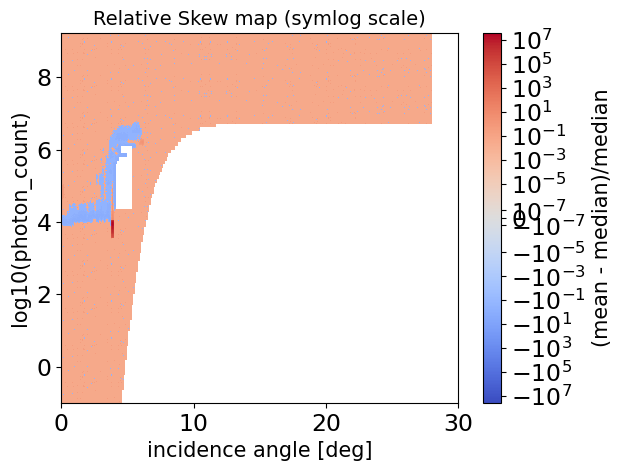

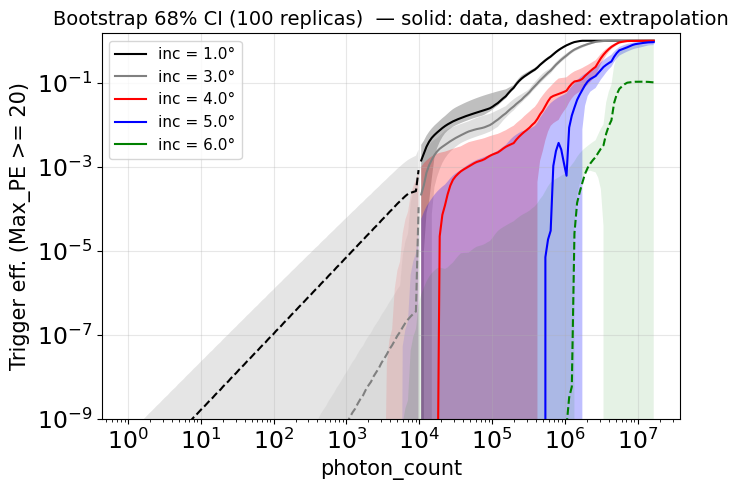

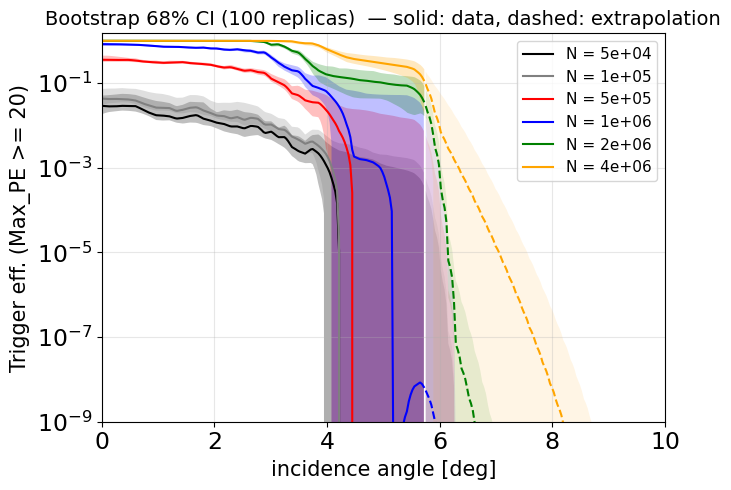

In [13]:
# Check Skewness
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm
import numpy as np

skew = (BOOT_MEAN - BOOT_MED) / BOOT_MED

linthresh = np.min(skew[np.where(skew > 0)])
vmax = np.nanmax(np.abs(skew))

norm = SymLogNorm(linthresh=linthresh, linscale=1.0,
                  vmin=-vmax, vmax=vmax, base=10)

extent = [COMMON_INC[0], COMMON_INC[-1],
          COMMON_LOG_PC[0], COMMON_LOG_PC[-1]]

plt.imshow(skew, norm=norm, cmap="coolwarm", origin="lower",
           extent=extent, aspect="auto")
plt.ylabel("log10(photon_count)")
plt.xlabel("incidence angle [deg]")
plt.colorbar(label="(mean - median)/median")
plt.title("Relative Skew map (symlog scale)")
plt.show()

# ---------- Example: efficiency vs photon_count at a few incidences ----------
reducer = "median"
fig, ax = plt.subplots(figsize=(7, 5))
N_grid = np.logspace(np.log10(pc_.min()),
                     np.log10(pc_.max()) , 200)
log_N_grid = np.log10(N_grid)

for inc_val, color in zip([1, 3, 4, 5, 6], ['black', 'gray', 'red', 'blue', 'green']):
    eff_c, lo, hi = trigger_eff_ci(N_grid, inc_val, reducer=reducer)

    # Mask: True where we are inside the empirical data coverage box
    inside = (
        (log_N_grid >= np.log10(min(pc_[hit_>0]))) & (log_N_grid <= _DATA_LOG_PC_HI) &
        (inc_val   >= _DATA_INC_LO)    & (inc_val   <= _DATA_INC_HI)
    )

    # Solid segment (inside)
    eff_in = np.where(inside, eff_c, np.nan)
    ax.plot(N_grid, eff_in, color=color, linestyle='-',
            label=f"inc = {inc_val:.1f}°")

    # Dashed segment (extrapolation)
    eff_out = np.where(~inside, eff_c, np.nan)
    ax.plot(N_grid, eff_out, color=color, linestyle='--')

    # CI band everywhere (lighter alpha outside)
    ax.fill_between(N_grid, lo, hi, where=inside,
                    color=color, alpha=0.25, linewidth=0)
    ax.fill_between(N_grid, lo, hi, where=~inside,
                    color=color, alpha=0.10, linewidth=0)

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_ylim(1e-9, 1.5)
ax.set_xlabel("photon_count")
ax.set_ylabel(f"Trigger eff. (Max_PE >= {PE_THRESHOLD})")
ax.set_title(f"Bootstrap {CI_LEVEL}% CI ({N_BOOT} replicas)  "
             f"— solid: data, dashed: extrapolation")
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()
# ---------- Example: efficiency vs incidence angle at a few photon counts ----------
fig, ax = plt.subplots(figsize=(7, 5))
inc_grid = np.linspace(inc_.min(), 10.0, 300)

N_values = [5e4, 1e5, 5e5, 1e6, 2e6, 4e6, 1e7]
colors   = ['black', 'gray', 'red', 'blue', 'green', 'orange']

log_pc_lo = np.log10(min(pc_[hit_ > 0]))

for N_val, color in zip(N_values, colors):
    eff_c, lo, hi = trigger_eff_ci(N_val, inc_grid, reducer=reducer)

    # Mask: True where we are inside the empirical data coverage box
    inside = (
        (np.log10(N_val) >= log_pc_lo) & (np.log10(N_val) <= _DATA_LOG_PC_HI) &
        (inc_grid        >= _DATA_INC_LO) & (inc_grid     <= _DATA_INC_HI)
    )

    # Solid segment (inside)
    eff_in = np.where(inside, eff_c, np.nan)
    ax.plot(inc_grid, eff_in, color=color, linestyle='-',
            label=f"N = {N_val:.0e}")

    # Dashed segment (extrapolation, including inc > data range up to 10°)
    eff_out = np.where(~inside, eff_c, np.nan)
    ax.plot(inc_grid, eff_out, color=color, linestyle='--')

    # CI band
    ax.fill_between(inc_grid, lo, hi, where=inside,
                    color=color, alpha=0.25, linewidth=0)
    ax.fill_between(inc_grid, lo, hi, where=~inside,
                    color=color, alpha=0.10, linewidth=0)

ax.set_yscale('log')
ax.set_ylim(1e-9, 1.5)
ax.set_xlim(inc_.min(), 10.0)
ax.set_xlabel("incidence angle [deg]")
ax.set_ylabel(f"Trigger eff. (Max_PE >= {PE_THRESHOLD})")
ax.set_title(f"Bootstrap {CI_LEVEL}% CI ({N_BOOT} replicas)  "
             f"— solid: data, dashed: extrapolation")
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()


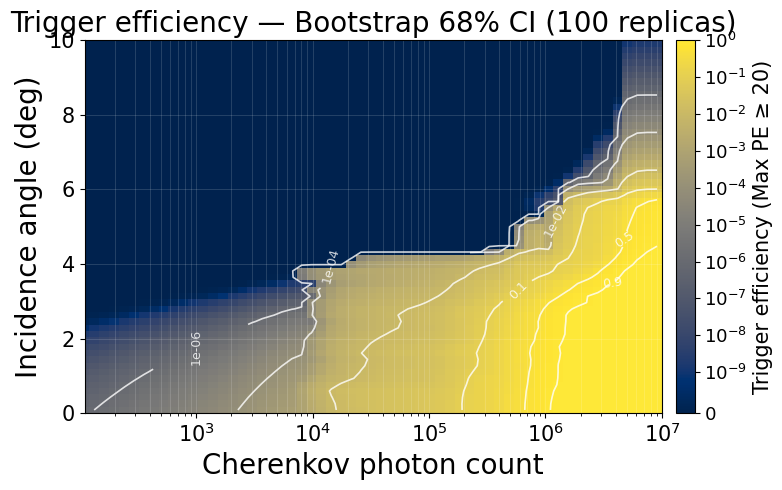

In [14]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

plt.rcParams.update({
    'font.family':      'sans-serif',
    'font.sans-serif':  ['DejaVu Sans'],
    'mathtext.fontset': 'dejavusans',
    'xtick.labelsize':  15,
    'ytick.labelsize':  15,
    'axes.labelsize':   20,
    'axes.titlesize':   20,
})

# ── Grid ──────────────────────────────────────────────────────────────────
inc_bins = np.linspace(0, 10, 60)
pc_bins  = np.logspace(2, 7, 60)          # 1e2 to 1e7

inc_grid_2d = 0.5 * (inc_bins[:-1] + inc_bins[1:])
pc_grid_2d  = np.sqrt(pc_bins[:-1] * pc_bins[1:])   # geometric midpoints

# ── Evaluate efficiency on the 2D grid ────────────────────────────────────
eff_map = np.full((len(inc_grid_2d), len(pc_grid_2d)), np.nan)  # shape (n_inc, n_pc)
for j, inc_val in enumerate(inc_grid_2d):
    eff_c, _, _ = trigger_eff_ci(pc_grid_2d, inc_val, reducer="median")
    eff_map[j, :] = eff_c                 # ← row = inc, col = pc

# ── Symlog color norm (colorblind-friendly: 'cividis') ────────────────────
eff_pos   = eff_map[eff_map > 0]
linthresh = 1e-9#float(np.nanmin(eff_pos)) if eff_pos.size else 1e-9

norm = mcolors.SymLogNorm(
    linthresh=linthresh,
    linscale=1.0,
    vmin=0,
    vmax=1.0,
    base=10
)

# ── Figure ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

mesh = ax.pcolormesh(
    pc_bins, inc_bins, eff_map,           # ← x=pc, y=inc
    norm=norm,
    cmap='cividis',
    shading='auto',
)

# ── Contours ──────────────────────────────────────────────────────────────
contour_levels = [1e-6, 1e-4, 1e-2, 0.1, 0.5, 0.9]
cs = ax.contour(
    pc_grid_2d, inc_grid_2d, eff_map,    # ← x=pc, y=inc
    levels=contour_levels,
    colors='white',
    linewidths=1.2,
    alpha=0.8,
)
ax.clabel(cs, fmt={v: f'{v:.0e}' if v < 0.1 else f'{v:.1f}'
                   for v in contour_levels},
          fontsize=9, inline=True)

# ── Colorbar ──────────────────────────────────────────────────────────────
cbar = fig.colorbar(mesh, ax=ax, pad=0.02)
cbar.set_label(f'Trigger efficiency (Max PE ≥ {PE_THRESHOLD})', fontsize=15)
cbar.ax.tick_params(labelsize=13)

# ── Axes ──────────────────────────────────────────────────────────────────
ax.set_xscale('log')                      # ← log on x now
#ax.set_xlim(1e3, 1e7)
#ax.set_ylim(0, 7)
ax.set_xlabel('Cherenkov photon count')
ax.set_ylabel('Incidence angle (deg)')
ax.set_title(f'Trigger efficiency — Bootstrap {CI_LEVEL}% CI ({N_BOOT} replicas)')
ax.grid(True, which='both', alpha=0.2, color='white', linewidth=0.5)

fig.tight_layout()
plt.show()


In [15]:
# Empirical efficiency cube on (zenith, azimuth, H, E) — OPTIMIZED version
# =============================================================================
# Key optimizations vs original:
#   1. ffill_along_H        — fully vectorized, no Python loops
#   2. efficiency_grid_H_E  — bin-membership computed once per (E,H) pair via
#                             np.digitize; tasks chunked by zenith so joblib
#                             overhead is ~N_Z_BINS jobs instead of N_tasks
#   3. _process_zen_slice   — phi/trig computed once per zenith, reused across
#                             all (H, E) bins in that slice; single batched
#                             trigger_eff_ci call per (H, E) bin
#   4. extrapolate_via_slant — same chunking strategy (one job per zen slice)
#   5. build_E_slant_pc_table — inner loop replaced with np.digitize + groupby
# =============================================================================

import os
import numpy as np
from joblib import Parallel, delayed
from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import distance_transform_edt

# ---------- Config ----------
BOOT_SEED   = 123
N_BOOT_EFF  = N_BOOTSTRAP
MIN_PTS_EFF = 5
N_E_BINS    = 20 #40
N_H_BINS    = 10 #20
N_Z_BINS    = 10 #30
N_AZ_BINS   = 5


N_JOBS      = os.cpu_count()

Telescope_Zenith = 90
ENERGY_MIN = 1e1
ENERGY_MAX = 1e6
ZEN_MIN    = np.nanmin(Zenith)
ZEN_MAX    = np.nanmax(Zenith)

AZIMUTH_RANGE = 10 #ZEN_MAX - ZEN_MIN
AZ_MIN = 0.0
AZ_MAX = AZIMUTH_RANGE  # degrees

H_MIN = np.nanmin(H) #5_000
H_MAX = np.nanmax(H) #50_000

OBS_HEIGHT_M   = 2_944.0
EARTH_RADIUS_M = 6_371_000.0

N_PARAMS   = 1
PARAM_ORDER = ["dummy"]
COV_FULL   = np.zeros((N_PARAMS, N_PARAMS))

# =============================================================================
# Helpers
# =============================================================================

def _phi_inc_grid(zen_deg, tele_zen_deg, phi_max_deg, n_phi):
    """Returns phi (n_phi,) in degrees AND radians, and theta_inc (n_phi,)."""
    theta_z  = np.radians(zen_deg)
    psi      = np.radians(tele_zen_deg)
    phi_rad  = np.linspace(0.0, np.radians(phi_max_deg), n_phi)
    phi_deg  = np.degrees(phi_rad)
    cos_t    = (np.cos(psi) * np.cos(theta_z)
                + np.sin(psi) * np.sin(theta_z) * np.cos(phi_rad))
    cos_t    = np.clip(cos_t, -1.0, 1.0)
    theta_inc = np.degrees(np.arccos(cos_t))   # (n_phi,)
    return phi_rad, phi_deg, theta_inc


def _phi_avg_eff(pc_sel, theta_inc, phi, reducer="mean",
                 n_pc_bins="fd", n_boot=100, rng=None):
    """
    Average trigger efficiency over phi for an array of photon counts,
    propagating BOTH model-side CI (from trigger_eff_ci) AND
    statistical sampling CI (from bootstrap over showers).

    Parameters
    ----------
    pc_sel    : (Nsh,) photon counts for showers in this bin
    theta_inc : (n_phi,) incidence angles in degrees
    phi       : (n_phi,) phi values in radians
    reducer   : "mean" | "histogram"
    n_pc_bins : int or "fd"  (only used for histogram reducer)
    n_boot    : int          number of bootstrap resamples
    rng       : np.random.Generator or None

    Returns
    -------
    eff, eff_lo, eff_hi : scalars  (nominal, 16th, 84th percentile of total CI)
    """
    npts  = len(pc_sel)
    n_phi = len(phi)
    denom = phi[-1] - phi[0]
    if rng is None:
        rng = np.random.default_rng()

    # -----------------------------------------------------------
    # Compute per-shower phi-averaged efficiency (med, lo, hi)
    # Shape: (Nsh,)
    # -----------------------------------------------------------
    pc_b  = pc_sel[:, None]                              # (Nsh, 1)
    inc_b = np.broadcast_to(theta_inc, (npts, n_phi))    # (Nsh, n_phi)
    med, lo, hi = trigger_eff_ci(pc_b, inc_b)            # each (Nsh, n_phi)
    med_phi = np.trapezoid(med, phi, axis=-1) / denom    # (Nsh,)
    lo_phi  = np.trapezoid(lo,  phi, axis=-1) / denom    # (Nsh,)
    hi_phi  = np.trapezoid(hi,  phi, axis=-1) / denom    # (Nsh,)

    if reducer == "mean":
        return _combine_uncertainty(med_phi, lo_phi, hi_phi, n_boot, rng)

    elif reducer == "histogram":
        # Build pc histogram, evaluate efficiency at bin centers, weight by PDF
        pc_pos = pc_sel[pc_sel > 0]
        if len(pc_pos) < 2 or pc_pos.min() == pc_pos.max():
            # Fall back to the per-shower mean path
            return _combine_uncertainty(med_phi, lo_phi, hi_phi, n_boot, rng)

        if n_pc_bins == "fd":
            log_pc = np.log10(pc_pos)
            edges_log = np.histogram_bin_edges(log_pc, bins='fd')
            edges = 10**edges_log
            count, _ = np.histogram(pc_pos, bins=edges)
            nb = len(count)
        else:
            edges = np.logspace(np.log10(pc_pos.min()),
                                np.log10(pc_pos.max()), n_pc_bins + 1)
            count, _ = np.histogram(pc_sel, bins=edges)
            nb = n_pc_bins

        dp     = np.diff(edges)
        total  = count.sum()
        if total == 0:
            return _combine_uncertainty(med_phi, lo_phi, hi_phi, n_boot, rng)
        pdf    = count / (total * dp)
        pc_cen = np.sqrt(edges[:-1] * edges[1:])

        pc_b  = pc_cen[:, None]
        inc_b = np.broadcast_to(theta_inc, (nb, n_phi))
        med_h, lo_h, hi_h = trigger_eff_ci(pc_b, inc_b)
        med_h_phi = np.trapezoid(med_h, phi, axis=-1) / denom    # (nb,)
        lo_h_phi  = np.trapezoid(lo_h,  phi, axis=-1) / denom
        hi_h_phi  = np.trapezoid(hi_h,  phi, axis=-1) / denom

        weights = pdf * dp                                       # (nb,)
        eff_nom = float(np.sum(weights * med_h_phi))

        # ---- model-side CI: weighted average of lo/hi over pc bins ----
        eff_model_lo = float(np.sum(weights * lo_h_phi))
        eff_model_hi = float(np.sum(weights * hi_h_phi))

        # ---- sampling CI: bootstrap the bin counts (Poisson / multinomial) ----
        if n_boot > 0 and total > 0:
            # Multinomial resample of the histogram counts
            boot_counts = rng.multinomial(int(total), count / total,
                                          size=n_boot)            # (n_boot, nb)
            boot_pdf    = boot_counts / (total * dp[None, :])     # (n_boot, nb)
            boot_w      = boot_pdf * dp[None, :]                  # (n_boot, nb)
            boot_eff    = boot_w @ med_h_phi                      # (n_boot,)
            stat_lo, stat_hi = np.percentile(boot_eff, [16, 84])
        else:
            stat_lo = stat_hi = eff_nom

        # Combine in quadrature
        sig_stat_lo = max(eff_nom - stat_lo, 0.0)
        sig_stat_hi = max(stat_hi - eff_nom, 0.0)
        sig_mod_lo  = max(eff_nom - eff_model_lo, 0.0)
        sig_mod_hi  = max(eff_model_hi - eff_nom, 0.0)
        eff_lo = eff_nom - np.hypot(sig_stat_lo, sig_mod_lo)
        eff_hi = eff_nom + np.hypot(sig_stat_hi, sig_mod_hi)
        return eff_nom, max(eff_lo, 0.0), min(eff_hi, 1.0)

    else:
        raise ValueError(f"Unknown reducer: {reducer!r}")


def _combine_uncertainty(med_phi, lo_phi, hi_phi, n_boot, rng):
    """
    Helper: combine model-side CI (lo/hi per shower) with bootstrap
    sampling CI over showers, returning (nominal, lo, hi).
    """
    npts = len(med_phi)
    eff_nom = float(np.mean(med_phi))

    # Model-side averaged CI
    eff_model_lo = float(np.mean(lo_phi))
    eff_model_hi = float(np.mean(hi_phi))

    # Bootstrap sampling CI
    if npts >= 2 and n_boot > 0:
        idx = rng.integers(0, npts, size=(n_boot, npts))
        boot_means = med_phi[idx].mean(axis=1)
        stat_lo, stat_hi = np.percentile(boot_means, [16, 84])
    else:
        stat_lo = stat_hi = eff_nom

    sig_stat_lo = max(eff_nom - stat_lo, 0.0)
    sig_stat_hi = max(stat_hi - eff_nom, 0.0)
    sig_mod_lo  = max(eff_nom - eff_model_lo, 0.0)
    sig_mod_hi  = max(eff_model_hi - eff_nom, 0.0)

    eff_lo = eff_nom - np.hypot(sig_stat_lo, sig_mod_lo)
    eff_hi = eff_nom + np.hypot(sig_stat_hi, sig_mod_hi)
    return eff_nom, max(eff_lo, 0.0), min(eff_hi, 1.0)

# =============================================================================
# 1. Forward-fill along H — fully vectorized
# =============================================================================

def ffill_along_H(EFF, *extras):
    """
    Forward-fill NaNs along the H axis (axis=2) for arrays of shape
    (n_zen, n_az, n_H, n_E[, ...]).
    """
    n_zen, n_az, n_H, n_E = EFF.shape[:4]
    trailing = EFF.shape[4:]

    def _ffill_4d(arr):
        # arr shape (n_zen, n_az, n_H, n_E)
        out = arr.copy()
        finite = np.isfinite(out)
        h_idx = np.where(finite, np.arange(n_H)[None, None, :, None], 0)
        np.maximum.accumulate(h_idx, axis=2, out=h_idx)
        z_idx = np.arange(n_zen)[:, None, None, None]
        a_idx = np.arange(n_az)[None, :, None, None]
        e_idx = np.arange(n_E)[None, None, None, :]
        out   = out[z_idx, a_idx, h_idx, e_idx]
        first_finite = np.argmax(finite, axis=2)   # (n_zen, n_az, n_E)
        all_nan      = ~finite.any(axis=2)
        h_range      = np.arange(n_H)[None, None, :, None]
        before       = h_range < first_finite[:, :, None, :]
        out[before | all_nan[:, :, None, :]] = np.nan
        return out

    def _ffill_5d(arr):
        # arr shape (n_zen, n_az, n_H, n_E, N_PARAMS)
        n_p = arr.shape[4]
        return np.stack([_ffill_4d(arr[..., p]) for p in range(n_p)], axis=-1)

    out_eff = _ffill_4d(EFF)
    out_extras = []
    for arr in extras:
        if arr.ndim == 4:
            out_extras.append(_ffill_4d(arr))
        elif arr.ndim == 5:
            out_extras.append(_ffill_5d(arr))
        else:
            raise ValueError(f"ffill_along_H: unsupported ndim={arr.ndim}")

    return (out_eff, *out_extras) if out_extras else out_eff


# =============================================================================
# 2. Per-zenith-slice worker  (used by efficiency_grid_H_E)
# =============================================================================

def _process_zen_slice_HE(k, zen_deg, bin_tasks,
                           tele_zen_deg, phi_max_deg, n_phi,
                           reducer, n_boot, rng_seed):
    if not bin_tasks:
        return []

    rng = np.random.default_rng(rng_seed)
    phi_rad, phi_deg, theta_inc = _phi_inc_grid(
        zen_deg, tele_zen_deg, phi_max_deg, n_phi
    )

    results = []
    for (j, i, pc_sel) in bin_tasks:

        # --- evaluate trigger_eff_ci once for all phi ---
        # pc_sel: (N_showers,), theta_inc: (n_phi,)
        pc_b   = pc_sel[:, None]                          # (N, n_phi)
        inc_b  = theta_inc[None, :]                       # (1, n_phi)
        med_raw, lo_raw, hi_raw = trigger_eff_ci(pc_b, inc_b, reducer=reducer)
        # med_raw: (N, n_phi)

        # --- per-phi efficiency = mean over showers ---
        med_phi = med_raw.mean(axis=0)   # (n_phi,)
        lo_phi  = lo_raw.mean(axis=0)    # (n_phi,)
        hi_phi  = hi_raw.mean(axis=0)    # (n_phi,)

        # --- bootstrap uncertainty per phi bin ---
        if n_boot > 1 and len(pc_sel) >= 2:
            idx = rng.integers(0, len(pc_sel), size=(n_boot, len(pc_sel)))
            boot = med_raw[idx].mean(axis=1)   # (n_boot, n_phi)
            stat_lo = np.percentile(boot, 16, axis=0)  # (n_phi,)
            stat_hi = np.percentile(boot, 84, axis=0)
        else:
            stat_lo = med_phi.copy()
            stat_hi = med_phi.copy()

        # Combine model + stat uncertainty in quadrature per phi
        sig_stat_lo = np.maximum(med_phi - stat_lo, 0.0)
        sig_stat_hi = np.maximum(stat_hi - med_phi, 0.0)
        sig_mod_lo  = np.maximum(med_phi - lo_phi,  0.0)
        sig_mod_hi  = np.maximum(hi_phi  - med_phi, 0.0)
        eff_lo = med_phi - np.hypot(sig_stat_lo, sig_mod_lo)
        eff_hi = med_phi + np.hypot(sig_stat_hi, sig_mod_hi)

        results.append((
            k, j, i,
            med_phi,                        # (n_phi,)
            np.clip(eff_lo, 0.0, 1.0),
            np.clip(eff_hi, 0.0, 1.0),
        ))

    return results

# =============================================================================
# 3. Empirical efficiency cube  (parallel over zenith slices)
# =============================================================================

def efficiency_grid_H_E(
    E_edges, H_edges, Zen_grid, Az_grid,
    Energy_GeV, H, photon_count,
    tele_zen_deg=90.0, phi_max_deg=3.0, n_phi=50,
    min_pts=5, reducer='mean',
    n_boot=200, rng=None, n_jobs=1,
):
    n_zen = len(Zen_grid)
    n_az  = len(Az_grid)
    n_H   = len(H_edges) - 1
    n_E   = len(E_edges) - 1
    E_cen = np.sqrt(E_edges[:-1] * E_edges[1:])
    H_cen = 0.5 * (H_edges[:-1] + H_edges[1:])

    EFF    = np.full((n_zen, n_az, n_H, n_E), np.nan)
    EFF_LO = np.full((n_zen, n_az, n_H, n_E), np.nan)
    EFF_HI = np.full((n_zen, n_az, n_H, n_E), np.nan)
    COUNTS = np.zeros((n_zen, n_az, n_H, n_E), dtype=int)
    GRAD   = np.zeros((n_zen, n_az, n_H, n_E, N_PARAMS))
    pc_in_bin = [[[None] * n_E for _ in range(n_H)] for _ in range(n_zen)]

    # ------------------------------------------------------------------
    # Bin membership computed once with np.digitize (vectorized)
    # ------------------------------------------------------------------
    E_idx = np.digitize(Energy_GeV, E_edges) - 1   # 0-based; -1 or n_E = outside
    H_idx = np.digitize(H,          H_edges) - 1

    valid = (E_idx >= 0) & (E_idx < n_E) & (H_idx >= 0) & (H_idx < n_H)
    E_idx_v = E_idx[valid]
    H_idx_v = H_idx[valid]
    pc_v    = photon_count[valid]

    # Count hits per (H, E) bin  — same for every zenith
    flat_idx = H_idx_v * n_E + E_idx_v                # (N_valid,)
    counts_HE = np.bincount(flat_idx, minlength=n_H * n_E).reshape(n_H, n_E)

    # Build per-(j, i) pc arrays once
    _order  = np.argsort(flat_idx)
    _fi_s   = flat_idx[_order]
    _pc_s   = pc_v[_order]
    _splits = np.searchsorted(_fi_s, np.arange(n_H * n_E + 1))
    pc_HE   = {}                                       # {(j,i): pc_array}
    for flat in range(n_H * n_E):
        j, i = divmod(flat, n_E)
        sl   = slice(_splits[flat], _splits[flat + 1])
        cnt  = _splits[flat + 1] - _splits[flat]
        COUNTS[:, :, j, i] = cnt          # broadcast over both zen and az axes
        if cnt >= min_pts:
            pc_HE[(j, i)] = _pc_s[sl]
            for k in range(n_zen):
                pc_in_bin[k][j][i] = _pc_s[sl]

    if not pc_HE:
        return (EFF, EFF_LO, EFF_HI, COUNTS, E_cen, H_cen, pc_in_bin, GRAD)

    # ------------------------------------------------------------------
    # Build per-zenith task lists and dispatch one job per zenith slice
    # ------------------------------------------------------------------
    zen_tasks = []
    for k, zen_deg in enumerate(Zen_grid):
        bin_tasks = [(j, i, arr) for (j, i), arr in pc_HE.items()]
        zen_tasks.append((k, zen_deg, bin_tasks))

    n_total_bins = len(Zen_grid) * len(pc_HE)
    print(f"efficiency_grid_H_E: {n_total_bins} bins "
          f"({len(Zen_grid)} zen × {len(pc_HE)} HE), {n_jobs} CPUs")

    #slice_results = Parallel(n_jobs=n_jobs, verbose=5)(
    #    delayed(_process_zen_slice_HE)(k, zen_deg, bin_tasks,
    #                                   tele_zen_deg, phi_max_deg, n_phi, reducer)
    #    for k, zen_deg, bin_tasks in zen_tasks
    #)
    # Extract a deterministic seed from rng
    rng_seed = int(rng.integers(0, 2**31 - 1)) if rng is not None else None

    slice_results = Parallel(n_jobs=n_jobs, verbose=5)(
        delayed(_process_zen_slice_HE)(k, zen_deg, bin_tasks,
                                   tele_zen_deg, phi_max_deg, n_phi, reducer,
                                   n_boot, rng_seed)
    for k, zen_deg, bin_tasks in zen_tasks
    )

    for slice_out in slice_results:
        for k, j, i, med_phi, lo_phi, hi_phi in slice_out:
            # med_phi: (n_phi,) → maps to azimuth axis
            for a in range(n_az):
                EFF[k, a, j, i]    = med_phi[a]
                EFF_LO[k, a, j, i] = lo_phi[a]
                EFF_HI[k, a, j, i] = hi_phi[a]
            COUNTS[k, :, j, i] = COUNTS[k, 0, j, i]  # same for all az

    return (EFF, EFF_LO, EFF_HI, COUNTS, E_cen, H_cen, pc_in_bin, GRAD)


# =============================================================================
# 4. Build (E, Slant) photon-count lookup — vectorized inner loop
# =============================================================================

def build_E_slant_pc_table(E_edges, H_emit, Energy_GeV, photon_count,
                           Zenith_deg, n_slant_bins):
    E_edges      = np.asarray(E_edges,      dtype=float)
    H_emit       = np.asarray(H_emit,       dtype=float)
    Energy_GeV   = np.asarray(Energy_GeV,   dtype=float)
    photon_count = np.asarray(photon_count, dtype=float)
    Zenith_rad   = np.radians(np.asarray(Zenith_deg, dtype=float))

    Slant_km = slant_depth(
        H_emit + EARTH_RADIUS_M,
        OBS_HEIGHT_M + EARTH_RADIUS_M,
        Zenith_rad,
    ) / 1000.0

    S_edges = np.linspace(np.nanmin(Slant_km), np.nanmax(Slant_km), n_slant_bins + 1)
    S_cen   = 0.5 * (S_edges[:-1] + S_edges[1:])
    n_E     = len(E_edges) - 1

    # Bin membership — vectorized
    finite_mask = np.isfinite(photon_count) & (photon_count > 0)
    E_idx = np.digitize(Energy_GeV, E_edges) - 1       # 0-based
    S_idx = np.digitize(Slant_km,   S_edges) - 1

    valid = (finite_mask
             & (E_idx >= 0) & (E_idx < n_E)
             & (S_idx >= 0) & (S_idx < n_slant_bins))
    E_idx_v  = E_idx[valid]
    S_idx_v  = S_idx[valid]
    pc_v     = photon_count[valid]

    flat_idx = E_idx_v * n_slant_bins + S_idx_v
    order    = np.argsort(flat_idx)
    fi_s     = flat_idx[order]
    pc_s     = pc_v[order]
    splits   = np.searchsorted(fi_s, np.arange(n_E * n_slant_bins + 1))

    pc_ES = [[None] * n_slant_bins for _ in range(n_E)]
    for flat in range(n_E * n_slant_bins):
        i, s = divmod(flat, n_slant_bins)
        sl = slice(splits[flat], splits[flat + 1])
        arr = pc_s[sl]
        pc_ES[i][s] = arr if len(arr) > 0 else np.empty(0)

    return S_edges, S_cen, pc_ES


# =============================================================================
# 5. Slant-based extrapolation — parallel over zenith slices
# =============================================================================

def _process_zen_slice_slant(k, zen, j_tasks, tele_zen_deg, phi_max_deg, n_phi,
                              reducer, n_boot, rng_seed):
    if not j_tasks:
        return []
    rng = np.random.default_rng(rng_seed + 1000 + k) if rng_seed is not None else np.random.default_rng()
    phi_rad, phi_deg, theta_inc = _phi_inc_grid(zen, tele_zen_deg, phi_max_deg, n_phi)

    out = []
    for j, i, pc in j_tasks:
        if len(pc) == 0:
            out.append((k, j, i, np.full(n_phi, np.nan),
                                  np.full(n_phi, np.nan),
                                  np.full(n_phi, np.nan)))
            continue

        pc_b  = pc[:, None]
        inc_b = theta_inc[None, :]
        med_raw, lo_raw, hi_raw = trigger_eff_ci(pc_b, inc_b, reducer=reducer)

        med_phi = med_raw.mean(axis=0)
        lo_phi  = lo_raw.mean(axis=0)
        hi_phi  = hi_raw.mean(axis=0)

        if n_boot > 1 and len(pc) >= 2:
            idx  = rng.integers(0, len(pc), size=(n_boot, len(pc)))
            boot = med_raw[idx].mean(axis=1)
            stat_lo = np.percentile(boot, 16, axis=0)
            stat_hi = np.percentile(boot, 84, axis=0)
        else:
            stat_lo = med_phi.copy()
            stat_hi = med_phi.copy()

        sig_stat_lo = np.maximum(med_phi - stat_lo, 0.0)
        sig_stat_hi = np.maximum(stat_hi - med_phi, 0.0)
        sig_mod_lo  = np.maximum(med_phi - lo_phi,  0.0)
        sig_mod_hi  = np.maximum(hi_phi  - med_phi, 0.0)
        eff_lo = np.clip(med_phi - np.hypot(sig_stat_lo, sig_mod_lo), 0.0, 1.0)
        eff_hi = np.clip(med_phi + np.hypot(sig_stat_hi, sig_mod_hi), 0.0, 1.0)

        out.append((k, j, i, med_phi, eff_lo, eff_hi))
    return out


def extrapolate_via_slant(EFF, EFF_LO, EFF_HI,
                          E_cen, H_cen, zenith_deg, S_edges, pc_ES,
                          tele_zen_deg=90.0, phi_max_deg=5.0, n_phi=20,
                          min_pts=5, reducer='mean', n_boot=200,
                          rng=None, n_jobs=N_JOBS):
    n_zen, n_az, n_H, n_E = EFF.shape   # <-- was (n_zen, n_H, n_E)

    zen_tasks = []
    for k in range(n_zen):
        zen = zenith_deg[k]
        j_tasks = []
        for j in range(n_H):
            slant_km = slant_depth(
                H_cen[j] + EARTH_RADIUS_M,
                OBS_HEIGHT_M + EARTH_RADIUS_M,
                np.deg2rad(zen),
            ) / 1000.0
            si = int(np.clip(np.searchsorted(S_edges, slant_km) - 1,
                             0, len(S_edges) - 2))
            for i in range(n_E):
                # Check if ANY azimuth slice is still NaN
                if np.all(np.isfinite(EFF[k, :, j, i])):
                    continue
                pc = pc_ES[i][si]
                if pc is None or len(pc) < min_pts:
                    continue
                j_tasks.append((j, i, pc))
        if j_tasks:
            zen_tasks.append((k, zen, j_tasks))

    if not zen_tasks:
        return EFF, EFF_LO, EFF_HI

    n_total = sum(len(t[2]) for t in zen_tasks)
    print(f"extrapolate_via_slant: {n_total} bins "
          f"across {len(zen_tasks)} zenith slices, {n_jobs} CPUs")

    rng_seed = int(rng.integers(0, 2**31 - 1)) if rng is not None else None
    slice_results = Parallel(n_jobs=n_jobs, verbose=5)(
        delayed(_process_zen_slice_slant)(k, zen, j_tasks,
                                          tele_zen_deg, phi_max_deg, n_phi, reducer,
                                          n_boot, rng_seed)
        for k, zen, j_tasks in zen_tasks
    )

    for slice_out in slice_results:
        for k, j, i, med_phi, lo_phi, hi_phi in slice_out:
            if np.any(np.isfinite(med_phi)):
                EFF[k, :, j, i]    = med_phi    # (n_phi,) → az axis
                EFF_LO[k, :, j, i] = lo_phi
                EFF_HI[k, :, j, i] = hi_phi

    return EFF, EFF_LO, EFF_HI


# =============================================================================
# 6. Build efficiency interpolator (logic unchanged, calls optimized helpers)
# =============================================================================

def build_efficiency_interpolator(EFF, EFF_LO, EFF_HI,
                                  E_cen, H_cen, zenith_deg, S_edges, pc_ES,
                                  tele_zen_deg=90.0, phi_max_deg=5.0, n_phi=20,
                                  min_pts=3, reducer='mean', n_boot=200,
                                  rng=None,
                                  H_extrap_range=(0.0, 120_000.0),
                                  n_H_extra=4,
                                  zen_extrap_range=None,
                                  n_zen_extra=2,
                                  n_jobs=N_JOBS):
    H_cen      = np.asarray(H_cen,      dtype=float)
    zenith_deg = np.asarray(zenith_deg, dtype=float)
    n_az       = EFF.shape[1]            # <-- read from data

    # --- H / zenith extension (unchanged logic) ---
    if n_H_extra > 0:
        H_lo      = np.linspace(H_extrap_range[0], H_cen[0],   n_H_extra + 1)[:-1]
        H_hi      = np.linspace(H_cen[-1], H_extrap_range[1],  n_H_extra + 1)[1:]
        H_cen_ext = np.concatenate([H_lo, H_cen, H_hi])
    else:
        H_cen_ext = H_cen.copy()

    if zen_extrap_range is not None and n_zen_extra > 0:
        Z_lo    = np.linspace(zen_extrap_range[0], zenith_deg[0],  n_zen_extra + 1)[:-1]
        Z_hi    = np.linspace(zenith_deg[-1], zen_extrap_range[1], n_zen_extra + 1)[1:]
        zen_ext = np.concatenate([Z_lo, zenith_deg, Z_hi])
    else:
        zen_ext = zenith_deg.copy()

    z_off     = int(np.searchsorted(zen_ext, zenith_deg[0]))
    h_off     = int(np.searchsorted(H_cen_ext, H_cen[0]))
    n_zen_ext = len(zen_ext)
    n_H_ext   = len(H_cen_ext)
    n_E       = EFF.shape[3]             # <-- was shape[2]

    def _embed(arr_old):
        # arr_old shape: (n_zen, n_az, n_H, n_E)
        out = np.full((n_zen_ext, n_az, n_H_ext, n_E), np.nan)
        out[z_off:z_off + len(zenith_deg),
            :,
            h_off:h_off + len(H_cen),
            :] = arr_old
        return out

    EFF    = _embed(EFF)
    EFF_LO = _embed(EFF_LO)
    EFF_HI = _embed(EFF_HI)

    # fill_mask must be computed AFTER embed (on the extended arrays)
    fill_mask = ~np.isfinite(EFF)        # shape (n_zen_ext, n_az, n_H_ext, n_E)

    H_cen      = H_cen_ext
    zenith_deg = zen_ext

    # --- EDT fill (unchanged logic, now operates on 4-D arrays) ---
    EFF_filled    = EFF.copy()
    EFF_LO_filled = EFF_LO.copy()
    EFF_HI_filled = EFF_HI.copy()

    nan_mask = ~np.isfinite(EFF_filled)
    if np.any(nan_mask):
        _, idx = distance_transform_edt(nan_mask, return_indices=True)
        EFF_filled[nan_mask]    = EFF_filled[tuple(idx)][nan_mask]
        EFF_LO_filled[nan_mask] = EFF_LO_filled[tuple(idx)][nan_mask]
        EFF_HI_filled[nan_mask] = EFF_HI_filled[tuple(idx)][nan_mask]

    original_nan = ~np.isfinite(EFF)
    edge_mask = np.zeros_like(EFF_filled, dtype=bool)
    edge_mask[:, :, :2, :]  = True      # <-- H axis is now axis 2
    edge_mask[:2, :, :, :]  = True
    edge_mask[-2:, :, :, :] = True
    reopen = edge_mask & original_nan
    EFF_filled[reopen]    = np.nan
    EFF_LO_filled[reopen] = np.nan
    EFF_HI_filled[reopen] = np.nan

    EFF_filled, EFF_LO_filled, EFF_HI_filled = extrapolate_via_slant(
        EFF_filled, EFF_LO_filled, EFF_HI_filled,
        E_cen, H_cen, zenith_deg, S_edges, pc_ES,
        tele_zen_deg=tele_zen_deg, phi_max_deg=phi_max_deg, n_phi=n_phi,
        min_pts=min_pts, reducer=reducer, n_boot=n_boot, rng=rng,
        n_jobs=n_jobs,
    )

    remaining = ~np.isfinite(EFF_filled)
    if np.any(remaining):
        _, idx2 = distance_transform_edt(remaining, return_indices=True)
        EFF_filled[remaining]    = EFF_filled[tuple(idx2)][remaining]
        EFF_LO_filled[remaining] = EFF_LO_filled[tuple(idx2)][remaining]
        EFF_HI_filled[remaining] = EFF_HI_filled[tuple(idx2)][remaining]

    EFF_filled[~np.isfinite(EFF_filled)]       = 0.0
    EFF_LO_filled[~np.isfinite(EFF_LO_filled)] = 0.0
    EFF_HI_filled[~np.isfinite(EFF_HI_filled)] = 0.0

    log10_E = np.log10(E_cen)
    # Axis order: (zen, az, H, log10E) — consistent throughout
    rgi_eff  = RegularGridInterpolator(
        (zenith_deg, Az_grid, H_cen, log10_E), EFF_filled,
        method='linear', bounds_error=False, fill_value=None)
    rgi_lo   = RegularGridInterpolator(
        (zenith_deg, Az_grid, H_cen, log10_E), EFF_LO_filled,
        method='linear', bounds_error=False, fill_value=None)
    rgi_hi   = RegularGridInterpolator(
        (zenith_deg, Az_grid, H_cen, log10_E), EFF_HI_filled,
        method='linear', bounds_error=False, fill_value=None)
    rgi_mask = RegularGridInterpolator(
        (zenith_deg, Az_grid, H_cen, log10_E),   # <-- az axis added
        fill_mask.astype(float),
        method='nearest', bounds_error=False, fill_value=1.0)

    def _make_pts(E_GeV, H_m, zenith_deg_q, az_deg_q):
        E_b, H_b, Z_b, A_b = np.broadcast_arrays(
            np.asarray(E_GeV,        float),
            np.asarray(H_m,          float),
            np.asarray(zenith_deg_q, float),
            np.asarray(az_deg_q,     float),
        )
        return np.column_stack([
            Z_b.ravel(), A_b.ravel(), H_b.ravel(), np.log10(E_b.ravel())
        ]), E_b.shape

    def eff_func(E_GeV, H_m, zenith_deg_q, az_deg_q):
        pts, shp = _make_pts(E_GeV, H_m, zenith_deg_q, az_deg_q)
        return np.clip(rgi_eff(pts), 0.0, 1.0).reshape(shp)

    def eff_sigma_func(E_GeV, H_m, zenith_deg_q, az_deg_q):
        pts, shp = _make_pts(E_GeV, H_m, zenith_deg_q, az_deg_q)
        med = np.clip(rgi_eff(pts), 0.0, 1.0).reshape(shp)
        lo  = np.clip(rgi_lo(pts),  0.0, 1.0).reshape(shp)
        hi  = np.clip(rgi_hi(pts),  0.0, 1.0).reshape(shp)
        return med, lo, hi

    def eff_fill_mask_func(E_GeV, H_m, zenith_deg_q, az_deg_q):  # <-- az added
        pts, shp = _make_pts(E_GeV, H_m, zenith_deg_q, az_deg_q)
        return (rgi_mask(pts).reshape(shp) >= 0.5)

    extra = {
        "EFF_filled":    EFF_filled,
        "EFF_LO_filled": EFF_LO_filled,
        "EFF_HI_filled": EFF_HI_filled,
        "fill_mask":     fill_mask,
        "H_cen_ext":     H_cen,
        "zen_ext":       zenith_deg,
    }
    return eff_func, eff_sigma_func, eff_fill_mask_func, extra

# =============================================================================
# Driver
# =============================================================================

rng     = np.random.default_rng(BOOT_SEED)
E_edges = np.logspace(np.log10(ENERGY_MIN), np.log10(ENERGY_MAX), N_E_BINS + 1) #equal_count_bins(Energy_GeV, N_E_BINS) #np.logspace(np.log10(ENERGY_MIN), np.log10(ENERGY_MAX), N_E_BINS + 1)
H_edges = np.logspace(np.log10(H_MIN), np.log10(H_MAX), N_H_BINS + 1) #equal_count_bins(H, N_H_BINS)
Zen_grid = np.linspace(ZEN_MIN, ZEN_MAX, N_Z_BINS)
Az_grid = np.linspace(AZ_MIN, AZ_MAX, N_AZ_BINS)
REDUCER = "median" # mean, global
photon_mask = np.where(photon_count >= 0) #focus on surviving event only
(EFF, EFF_LO, EFF_HI, COUNTS, E_cen, H_cen, pc_in_bin, GRAD) = efficiency_grid_H_E(
    E_edges, H_edges, Zen_grid, Az_grid,
    Energy_GeV[photon_mask], H[photon_mask], photon_count[photon_mask],
    tele_zen_deg=Telescope_Zenith, phi_max_deg=AZIMUTH_RANGE, n_phi=N_AZ_BINS,
    min_pts=MIN_PTS_EFF, reducer=REDUCER,
    n_boot=N_BOOT_EFF, rng=rng, n_jobs=N_JOBS,
)
filled_mask = ~np.isnan(EFF)  # before ffill
print(f"Filled bins: {filled_mask.sum()} / {EFF.size}  ({100*filled_mask.mean():.1f}%)")
sparse_mask = COUNTS < MIN_PTS_EFF
EFF[sparse_mask] = np.nan  # exclude from interpolation

EFF, EFF_LO, EFF_HI, GRAD = ffill_along_H(EFF, EFF_LO, EFF_HI, GRAD)

S_edges, S_cen, pc_ES = build_E_slant_pc_table(
    E_edges, H, Energy_GeV, photon_count, Zenith,
    n_slant_bins=N_H_BINS,
)

eff_func, eff_sigma_func, eff_fill_mask_func, eff_extra = build_efficiency_interpolator(
    EFF, EFF_LO, EFF_HI, E_cen, H_cen, Zen_grid, S_edges, pc_ES,
    tele_zen_deg=Telescope_Zenith, phi_max_deg=AZIMUTH_RANGE, n_phi=N_AZ_BINS,
    min_pts=MIN_PTS_EFF, reducer=REDUCER,
    n_boot=N_BOOT_EFF, rng=rng, n_jobs=N_JOBS,
)

efficiency_grid_H_E: 2000 bins (10 zen × 200 HE), 48 CPUs


[Parallel(n_jobs=48)]: Using backend LokyBackend with 48 concurrent workers.
[Parallel(n_jobs=48)]: Done   2 out of  10 | elapsed:   33.9s remaining:  2.3min
[Parallel(n_jobs=48)]: Done   5 out of  10 | elapsed:   35.6s remaining:   35.6s
[Parallel(n_jobs=48)]: Done   8 out of  10 | elapsed:   46.2s remaining:   11.6s
[Parallel(n_jobs=48)]: Done  10 out of  10 | elapsed:   47.0s finished


Filled bins: 10000 / 10000  (100.0%)
extrapolate_via_slant: 840 bins across 10 zenith slices, 48 CPUs


[Parallel(n_jobs=48)]: Using backend LokyBackend with 48 concurrent workers.
[Parallel(n_jobs=48)]: Done   2 out of  10 | elapsed:    5.6s remaining:   22.2s
[Parallel(n_jobs=48)]: Done   5 out of  10 | elapsed:    7.1s remaining:    7.1s
[Parallel(n_jobs=48)]: Done   8 out of  10 | elapsed:   12.2s remaining:    3.0s
[Parallel(n_jobs=48)]: Done  10 out of  10 | elapsed:   17.3s finished


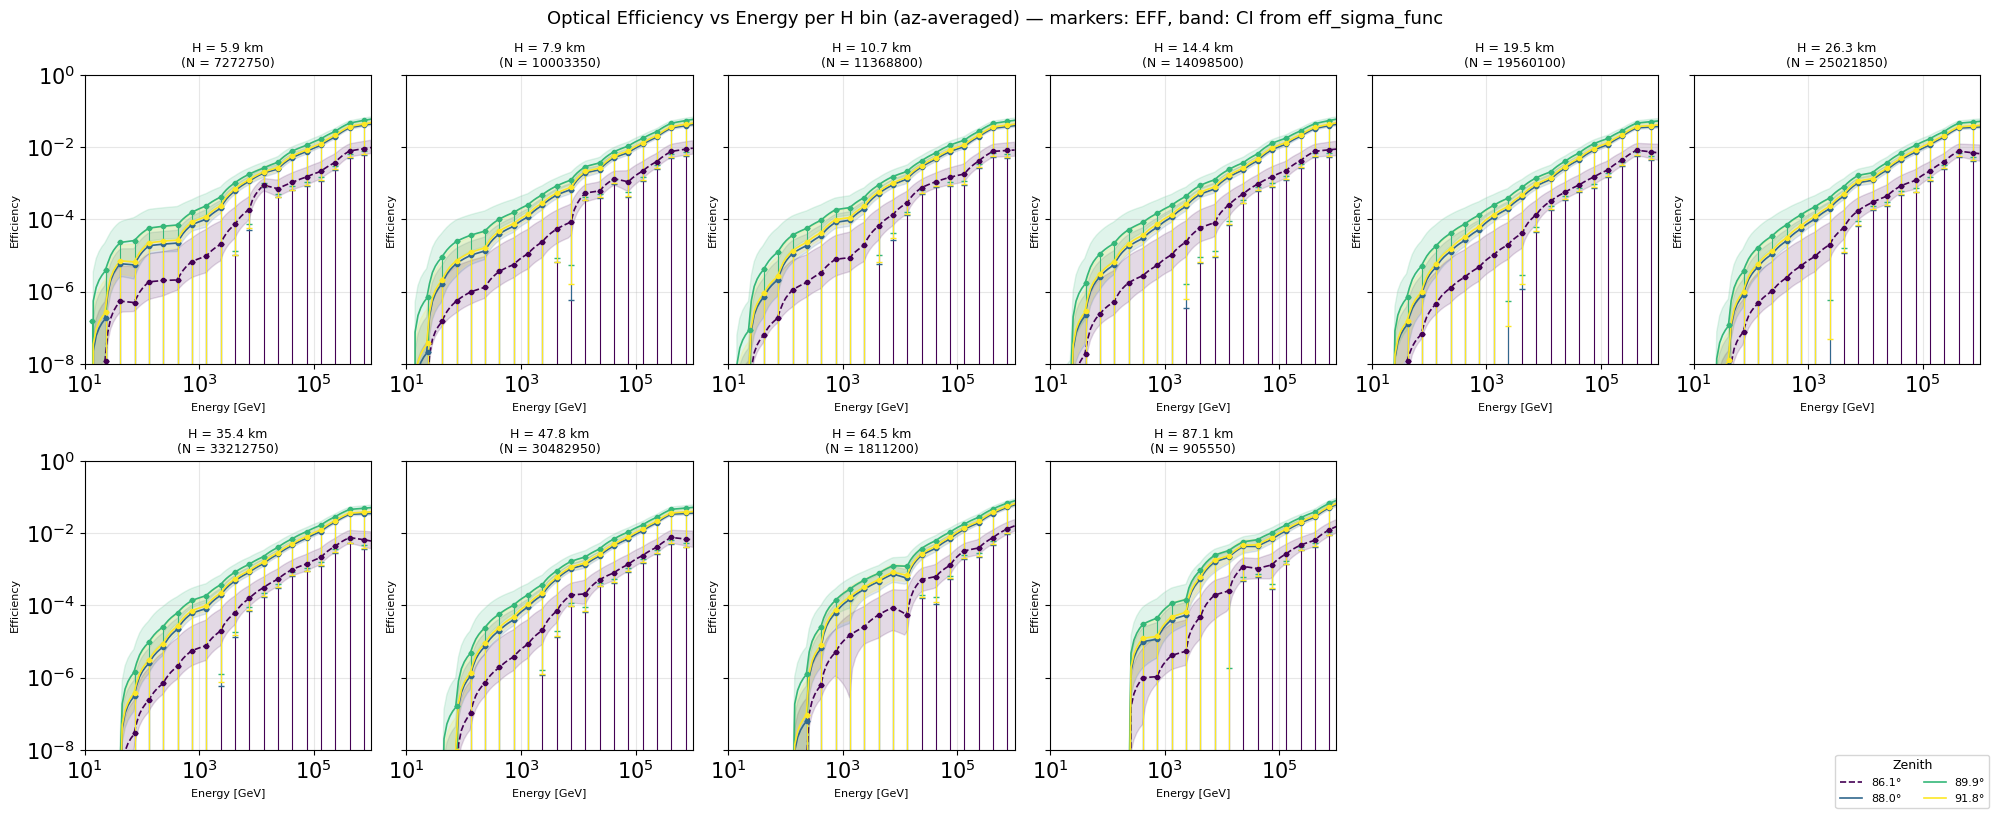

In [16]:
# Testing efficiency vs Energy per zenith (averaged over azimuth)
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

n_H = len(H_cen)
n_Z = len(Zen_grid)

ncols = 6
nrows = int(np.ceil(n_H / ncols))

MAX_ZEN_LINES = 4

# Subsample zenith indices
if n_Z <= MAX_ZEN_LINES:
    zen_inds = np.arange(n_Z)
else:
    zen_inds = np.linspace(0, n_Z - 1, MAX_ZEN_LINES).round().astype(int)
    zen_inds = np.unique(zen_inds)

fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols,
    figsize=(20, 4.1 * nrows),
    sharey=True,
)
axes = np.atleast_1d(axes).ravel()

colors = cm.viridis(np.linspace(0, 1, len(zen_inds)))

E_plot = np.logspace(np.log10(E_edges[0]), np.log10(E_edges[-1]), 100)

for j in range(n_H):
    ax    = axes[j]
    H_val = H_cen[j]

    for ci, k in enumerate(zen_inds):
        zen = Zen_grid[k]

        # --- average interpolator over all azimuth bins ---
        med_az, lo_az, hi_az = [], [], []
        for a in range(len(Az_grid)):
            az = Az_grid[a]
            med_c, lo_c, hi_c = eff_sigma_func(
                E_plot,
                np.full_like(E_plot, H_val),
                np.full_like(E_plot, zen),
                np.full_like(E_plot, az),
            )
            med_az.append(med_c)
            lo_az.append(lo_c)
            hi_az.append(hi_c)

        med_curve = np.mean(med_az, axis=0)   # average over azimuth
        lo_curve  = np.mean(lo_az,  axis=0)
        hi_curve  = np.mean(hi_az,  axis=0)

        ax.plot(
            E_plot, med_curve,
            color=colors[ci],
            linestyle='-' if zen > 87 else '--',
            linewidth=1.2,
            label=f"{zen:.1f}°",
        )
        ax.fill_between(E_plot, lo_curve, hi_curve,
                        color=colors[ci], alpha=0.15)

        # --- raw EFF markers: average over azimuth axis (axis=1 → az) ---
        eff_row = np.nanmean(EFF[k, :, j, :], axis=0)   # (n_az, n_E) → (n_E,)
        valid   = np.isfinite(eff_row)
        if valid.any():
            med_pts, lo_pts, hi_pts = eff_sigma_func(
                E_cen[valid],
                np.full_like(E_cen[valid], H_val),
                np.full_like(E_cen[valid], zen),
                np.full_like(E_cen[valid], Az_grid.mean()),  # mean az for markers
            )
            yerr = np.vstack([
                np.clip(eff_row[valid] - lo_pts, 0, None),
                np.clip(hi_pts - eff_row[valid], 0, None),
            ])
            ax.errorbar(
                E_cen[valid], eff_row[valid],
                yerr=yerr,
                color=colors[ci],
                marker='o',
                markersize=3,
                linestyle='none',
                elinewidth=0.8,
                capsize=2,
            )

    ax.set_xscale('log')
    ax.set_xlim(E_edges[0], E_edges[-1])
    ax.set_ylim(1e-8, 1)
    ax.set_yscale('log')
    ax.set_title(
        f"H = {H_cen[j]/1e3:.1f} km\n"
        f"(N = {COUNTS[:, :, j, :].sum()})",
        fontsize=9,
    )
    ax.set_xlabel("Energy [GeV]", fontsize=8)
    ax.set_ylabel("Efficiency",   fontsize=8)
    ax.grid(True, which='both', alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    title="Zenith",
    loc='lower right',
    ncol=2,
    fontsize=8,
    title_fontsize=9,
    bbox_to_anchor=(1.0, 0.0),
)

for j in range(n_H, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    "Optical Efficiency vs Energy per H bin (az-averaged) — markers: EFF, band: CI from eff_sigma_func",
    fontsize=13,
)
plt.tight_layout()
plt.show()


12 12
Slope     m = -1.923441e-01 ± 1.004837e-02
Intercept b = 1.048986e+00 ± 4.991029e-02
Weighted R² = 0.97343
Effective Area (central) = 311465.6116 cm²
Effective Area (MC mean) = 3260475843.98 ± 129069080.76 cm²
Raw Area 785398.1633974483  cm²


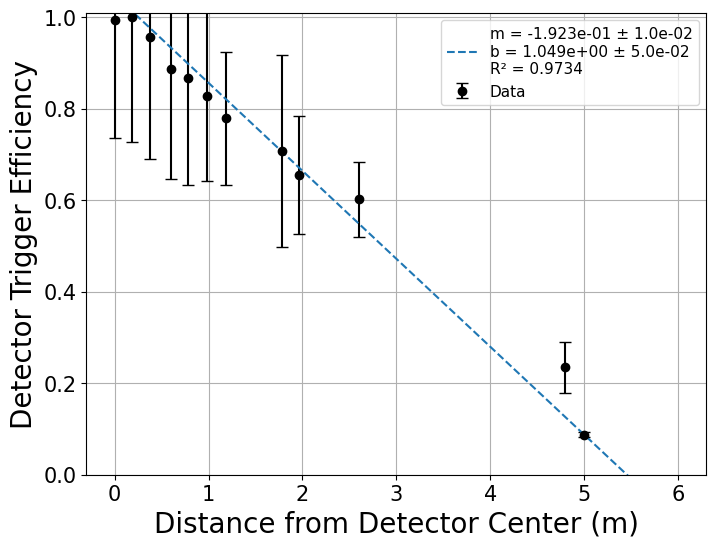

In [17]:
# Effective area from digitized trigger-rate data
# =========================================================================

# --- Digitized data ---
R_data = np.array([
    0.08165819247995529, 0.3077888370767397, 0.48994972995969954, 0.684673244738047, 
    0.9108038893348314, 1.0929647822177913, 1.2939696079438325,1.4949750087498417, 
    2.0917084625202556, 2.2738690678632314, 2.908291537479744,5.100502125323036, 
    5.301507526129045
])
R_data = R_data - R_data[1]

trigger_data = np.array([
    0.013083803640247065, 0.014237288135593221,0.014336158192090397, 0.013709980161850063, 
    0.012721279596878311, 0.012424669427386787, 0.011864406779661017, 0.011172316384180791, 
    0.010150658127951758, 0.009392655367231639, 0.008634651097874185, 0.0033615819209039553, 
    0.001252353043205994
])

trigger_rate_max = np.array([
    0.01858757062146893, 0.016016949152542374, 0.015918079096045198, 0.015160074826687743, 
    0.014138418079096047, 0.013841807909604521, 0.013775894035727291, 0.013380413809738591, 
    0.011040488636426335, 0.011139358692923509, 0.010776836158192091, 0.003855932203389831, 
    0.0018126156909317622
])
trigger_rate_err = trigger_rate_max - trigger_data

trigger_rate_err = abs(max(trigger_data)*trigger_rate_err - trigger_data*max(trigger_rate_err))/(max(trigger_data))**2 #+ 1e-10
trigger_data = trigger_data/max(trigger_data)

trigger_rate_err = trigger_rate_err[1:]
trigger_data = trigger_data[1:]
R_data = R_data[1:]
print(len(trigger_rate_err), len(trigger_data))
# --- Weighted linear fit ---
fit_weights = 1.0 / trigger_rate_err**2

(p, cov_fit) = np.polyfit(
    R_data,
    trigger_data,
    deg=1,
    w=np.sqrt(fit_weights),
    cov=True
)

m_fit, b_fit = p
m_err = np.sqrt(cov_fit[0, 0])
b_err = np.sqrt(cov_fit[1, 1])

print(f"Slope     m = {m_fit:.6e} ± {m_err:.6e}")
print(f"Intercept b = {b_fit:.6e} ± {b_err:.6e}")

# --- Weighted R² ---
y_fit        = m_fit * R_data + b_fit
weighted_mean = np.average(trigger_data, weights=fit_weights)
ss_res = np.sum(fit_weights * (trigger_data - y_fit)**2)
ss_tot = np.sum(fit_weights * (trigger_data - weighted_mean)**2)
r_squared = 1 - ss_res / ss_tot
print(f"Weighted R² = {r_squared:.5f}")

# --- Central effective area ---
r_grid = np.linspace(0, 6, 10000)
trigger_rate_r      = np.clip(m_fit * r_grid + b_fit, 0, None)
trigger_rate_r_norm = trigger_rate_r / trigger_rate_r.max()
effective_area_central = 2 * np.pi * np.trapezoid(
    trigger_rate_r_norm * r_grid, x=r_grid
)
print(f"Effective Area (central) = {effective_area_central * 1e4:.4f} cm²")

# --- Monte Carlo uncertainty propagation ---
N_mc = 1000
samples = np.random.multivariate_normal(
    mean=[m_fit, b_fit],
    cov=cov_fit,
    size=N_mc
)

area_samples = []
for m_i, b_i in samples:
    trigger_i = np.clip(m_i * r_grid + b_i, 0, None)
    if trigger_i.max() <= 0:
        continue
    trigger_i_norm = trigger_i 
    area_i = 2 * np.pi * np.trapezoid(trigger_i_norm * r_grid, x=r_grid)
    area_samples.append(area_i)

area_samples = np.array(area_samples) * 1e4 #convert to cm^2

effective_area_mean = np.mean(area_samples) 
effective_area_std  = np.std(area_samples) 
raw_area = np.pi*500**2

print(f"Effective Area (MC mean) = {effective_area_mean * 1e4:.2f} ± "
      f"{effective_area_std * 1e4:.2f} cm²")
print("Raw Area", raw_area, " cm²")
# --- Fit plot ---
plt.figure(figsize=(8, 6))
plt.errorbar(R_data, trigger_data, yerr=trigger_rate_err,
             fmt='o', color="black", capsize=4, label='Data')
plt.plot(r_grid, (m_fit * r_grid + b_fit), '--',
         label=(
                f'm = {m_fit:.3e} ± {m_err:.1e}\n'
                f'b = {b_fit:.3e} ± {b_err:.1e}\n'
                f'R² = {r_squared:.4f}'))


plt.xlabel("Distance from Detector Center (m)")
plt.ylim(0,1.01)
plt.ylabel("Detector Trigger Efficiency")
plt.grid(True)
plt.legend()
plt.savefig("/uufs/chpc.utah.edu/common/home/u1520754/Muon_Trinity/plot/eff_r.png",transparent=True)

plt.show()

In [18]:
# Muon Flux Calculation
import pickle
import numpy as np
import matplotlib.pyplot as plt

def convert_altitude_to_depth(altitude_m, zenith_deg):
    altitude_m  = np.asarray(altitude_m, dtype=float)
    altitude_km = altitude_m * 1e-3
    altitude_cm = altitude_m * 100.0

    zenith_deg  = np.asarray(zenith_deg, dtype=float)
    zenith_deg  = np.where(zenith_deg >= 90.0, 89.9, zenith_deg)

    depth = np.empty_like(altitude_m)

    m1 = (altitude_km >   0.0) & (altitude_km <   4.0)
    m2 = (altitude_km >=  4.0) & (altitude_km <  10.0)
    m3 = (altitude_km >= 10.0) & (altitude_km <  40.0)
    m4 = (altitude_km >= 40.0) & (altitude_km <= 100.0)
    m5 =  altitude_km > 100.0

    depth[m1] = -186.555305 + 1222.6562 * np.exp(-altitude_cm[m1] / 994186.38)
    depth[m2] =  -94.919    + 1144.9069 * np.exp(-altitude_cm[m2] / 878153.55)
    depth[m3] =    0.61289  + 1305.5948 * np.exp(-altitude_cm[m3] / 636143.04)
    depth[m4] =    0.0      +  540.1778 * np.exp(-altitude_cm[m4] / 772170.16)
    depth[m5] =    0.01128292 - altitude_cm[m5] / 1e9

    depth /= np.cos(np.deg2rad(zenith_deg))

    return depth


def eff_sigma_func_X(E_mesh, H_mesh, Z_mesh, A_mesh):
    X_mesh = convert_altitude_to_depth(H_mesh, Z_mesh)
    return eff_sigma_func(E_mesh, H_mesh, Z_mesh, A_mesh)

# =========================================================================
# 2. Load the precomputed MCEq grid
# =========================================================================
"""with open('/uufs/chpc.utah.edu/common/home/u1520754/Muon_Trinity/data/'
          'mceq_grid_80_90deg_Nzen100_no_decay_no_E_loss.pkl', 'rb') as f:"""
with open('/uufs/chpc.utah.edu/common/home/u1520754/Muon_Trinity/data/'
          'mceq_grid_80_90deg_Nzen100_no_decay_no_E_loss.pkl', 'rb') as f:          
    grid_data = pickle.load(f)

zen_centers_all = grid_data['zen_centers']
cos_edges       = grid_data['cos_edges']
sin_edges       = np.sqrt(1-cos_edges**2)
theta_edges     = np.arccos(cos_edges)
int_sin2_edges  = (theta_edges - sin_edges*cos_edges)/2
E_GeV           = grid_data['E_GeV']

min_E           = ENERGY_MIN #grid_data['min_E'] #
max_E           = 1e6#grid_data['max_E'] #
E_mask          = (E_GeV>=min_E)&(E_GeV<=max_E)
E_GeV           = E_GeV[E_mask]

zen_min_use, zen_max_use = 85, 90.0
tele_azimuth = 270
n_azimuth = 5

zen_mask = (zen_centers_all >= zen_min_use) & (zen_centers_all <= zen_max_use)
if not np.any(zen_mask):
    raise ValueError(
        f"No zenith bins in [{zen_min_use}, {zen_max_use}] deg. "
        f"Available centers: {zen_centers_all}"
    )

zen_centers = zen_centers_all[zen_mask]

min_az, max_az = tele_azimuth - AZIMUTH_RANGE, tele_azimuth + AZIMUTH_RANGE
phi = np.linspace(0, AZIMUTH_RANGE, n_azimuth)

dphi = np.radians(max_az - min_az)

selected_entries = [e for e, keep in zip(grid_data['per_zenith'], zen_mask) if keep]

# Azimuth offsets (same for every zenith). 
# phi already defined above as: phi = np.linspace(0, AZIMUTH_RANGE, n_azimuth)
n_A = len(phi)

flux_slices = []   # will hold one (n_H, n_E) -> (n_H, n_E, n_A) array per zenith
zen_list    = []   # keep track of the zenith value for each slice (for bookkeeping)
X_list      = []
for entry in selected_entries:
    theta  = entry['theta']      # zenith (deg) for this slice
    H_grid = entry['H_grid']     # emission heights (cm)
    d_CDF  = entry['d_CDF']      # muon flux, shape (n_H, n_E)  <-- adjust if different
    X_grid = entry['X_grid']
    # --- the flux for this zenith: shape (n_H, n_E) ---
    d_X = np.gradient(X_grid)[:,None]
    #d_CDF = d_CDF/d_X
    flux_HE = np.asarray(d_CDF)[:, E_mask]

    # --- broadcast over azimuth: (n_H, n_E) -> (n_H, n_E, n_A) ---
    flux_HEA = np.broadcast_to(flux_HE[:, :, None], flux_HE.shape + (n_A,))

    flux_slices.append(flux_HEA)
    zen_list.append(theta)
    X_list.append(X_grid)
X_arr = np.array(X_list)
# Stack along a new leading zenith axis -> (Z, H, E, A)
flux_tensor = np.stack(flux_slices, axis=0)

zen_arr = np.array(zen_list)   # (Z,)

print("flux_tensor shape (Z, H, E, A):", flux_tensor.shape)
print("zenith values:", zen_arr)

# Common axes (built once)
H_m      = np.asarray(selected_entries[0]['H_grid']) / 100.0   # (n_H,)
E_axis   = np.asarray(E_GeV)                                   # (n_E,)
phi_axis = np.asarray(phi)                                     # (n_A,)

# 3D meshes for ONE zenith slice — built once, reused every iteration
H_mesh, E_mesh, A_mesh = np.meshgrid(H_m, E_axis, phi_axis, indexing='ij')
# each shape (n_H, n_E, n_A) ≈ 18 MB

Z_mesh = np.empty_like(H_mesh)   # reused buffer for the scalar zenith

eff_slices = []
eff_slices_lo = []
eff_slices_hi = []
for theta in zen_arr:
    print(theta)
    Z_mesh.fill(theta)                                   # constant zenith
    #eff_HEA = eff_func(E_mesh, H_mesh, Z_mesh, A_mesh)   # (n_H, n_E, n_A)
    eff_HEA, eff_lo, eff_hi = eff_sigma_func(E_mesh, H_mesh, Z_mesh, A_mesh)
    eff_slices.append(eff_HEA.astype(np.float32))        # downcast to save RAM if neccesary
    eff_slices_lo.append(eff_lo.astype(np.float32))        # downcast to save RAM if neccesary
    eff_slices_hi.append(eff_hi.astype(np.float32))        # downcast to save RAM if neccesary

eff_tensor = np.stack(eff_slices, axis=0)   # (Z, H, E, A)
eff_tensor_lo = np.stack(eff_slices_lo, axis=0)
eff_tensor_hi = np.stack(eff_slices_hi, axis=0)
print("eff_tensor shape:", eff_tensor.shape, "dtype:", eff_tensor.dtype)
assert eff_tensor.shape == flux_tensor.shape

flux_eff_tensor = eff_tensor*flux_tensor
flux_eff_tensor_lo = eff_tensor_lo*flux_tensor
flux_eff_tensor_hi = eff_tensor_hi*flux_tensor
# =========================================================================
# Extrapolate flux grid to 91.8 degrees by copying the 90-degree slice
# =========================================================================

# Find the index of the 90-degree zenith slice
idx_90 = np.argmin(np.abs(zen_arr - 90.0))
print(f"Using zenith slice at {zen_arr[idx_90]:.2f}° as the basis for extrapolation")

# Define the new zenith angles to extrapolate to (above 90 degrees)
zen_extrap = np.degrees(np.arccos(np.linspace(np.cos(np.radians(91.8)), np.cos(np.radians(90)), 10))) #np.array([91.8, 91.0, 90.9])  # can add more values here if needed

# --- Flux extrapolation ---
# Copy the 90° flux slice for each new zenith angle
flux_extrap_slices = []
X_extrap = []
for z_new in zen_extrap:
    # Copy the 90° slice: shape (H, E, A)
    flux_extrap_slices.append(flux_tensor[idx_90].copy())
    X_extrap.append(X_arr[idx_90].copy())
flux_extrap_tensor = np.stack(flux_extrap_slices, axis=0)  # (Z_new, H, E, A)
print(f"flux_extrap_tensor shape: {flux_extrap_tensor.shape}")
# --- Efficiency extrapolation ---
# Recompute efficiency at the new zenith angles
eff_extrap_slices    = []
eff_extrap_slices_lo = []
eff_extrap_slices_hi = []

for z_new in zen_extrap:
    print(f"Computing efficiency at zenith = {z_new}°")
    Z_mesh_extrap = np.full_like(H_mesh, z_new)
    eff_HEA, eff_lo, eff_hi = eff_sigma_func(E_mesh, H_mesh, Z_mesh_extrap, A_mesh)
    eff_extrap_slices.append(eff_HEA.astype(np.float32))
    eff_extrap_slices_lo.append(eff_lo.astype(np.float32))
    eff_extrap_slices_hi.append(eff_hi.astype(np.float32))

eff_extrap_tensor    = np.stack(eff_extrap_slices,    axis=0)  # (Z_new, H, E, A)
eff_extrap_tensor_lo = np.stack(eff_extrap_slices_lo, axis=0)
eff_extrap_tensor_hi = np.stack(eff_extrap_slices_hi, axis=0)
print(f"eff_extrap_tensor shape: {eff_extrap_tensor.shape}")

# --- Concatenate original + extrapolated tensors ---
zen_arr_full          = np.concatenate([zen_extrap, zen_arr         ])
X_arr_full            = np.concatenate([np.array(X_extrap),   X_arr])
flux_tensor_full      = np.concatenate([flux_extrap_tensor, flux_tensor],      axis=0)
eff_tensor_full       = np.concatenate([eff_extrap_tensor, eff_tensor       ],       axis=0)
eff_tensor_lo_full    = np.concatenate([eff_extrap_tensor_lo, eff_tensor_lo    ],    axis=0)
eff_tensor_hi_full    = np.concatenate([eff_extrap_tensor_hi, eff_tensor_hi    ],    axis=0)

flux_eff_tensor_full    = eff_tensor_full    * flux_tensor_full
flux_eff_tensor_lo_full = eff_tensor_lo_full * flux_tensor_full
flux_eff_tensor_hi_full = eff_tensor_hi_full * flux_tensor_full

print(f"\nFinal combined tensor shapes:")
print(f"  zen_arr_full:          {zen_arr_full}")
print(f"  flux_tensor_full:      {flux_tensor_full.shape}")
print(f"  eff_tensor_full:       {eff_tensor_full.shape}")
print(f"  flux_eff_tensor_full:  {flux_eff_tensor_full.shape}")


# Replace the original tensors with the full ones for downstream use
zen_arr          = zen_arr_full
X_arr            = X_arr_full
flux_tensor      = flux_tensor_full
eff_tensor       = eff_tensor_full
eff_tensor_lo    = eff_tensor_lo_full
eff_tensor_hi    = eff_tensor_hi_full
flux_eff_tensor    = flux_eff_tensor_full
flux_eff_tensor_lo = flux_eff_tensor_lo_full
flux_eff_tensor_hi = flux_eff_tensor_hi_full

print("\nDone. Downstream variables updated to include 91.8° extrapolation.")


flux_tensor shape (Z, H, E, A): (50, 1000, 50, 5)
zenith values: [89.95025346 89.85076022 89.75126653 89.65177209 89.5522766  89.45277976
 89.35328127 89.25378083 89.15427814 89.05477289 88.9552648  88.85575355
 88.75623886 88.65672041 88.5571979  88.45767105 88.35813953 88.25860306
 88.15906134 88.05951405 87.95996091 87.8604016  87.76083583 87.66126329
 87.56168369 87.46209671 87.36250206 87.26289944 87.16328854 87.06366906
 86.96404069 86.86440313 86.76475608 86.66509923 86.56543228 86.46575493
 86.36606686 86.26636778 86.16665737 86.06693534 85.96720137 85.86745516
 85.7676964  85.66792479 85.56814001 85.46834177 85.36852974 85.26870363
 85.16886312 85.0690079 ]
89.95025345524756
89.850760215738
89.75126652621034
89.65177208663894
89.5522765969778
89.45277975715244
89.35328126705171
89.25378082651967
89.15427813534743
89.05477289326498
88.95526479993308
88.85575355493502
88.75623885776848
88.6567204078374
88.55719790444367
88.45767104677908
88.35813953391704
88.25860306480433
88.15

In [19]:
delta_tensor = eff_tensor-eff_tensor_lo
len(delta_tensor[np.where(delta_tensor<0)])/len(delta_tensor.flatten())

0.009307466666666667

In [42]:
delta_tensor = eff_tensor_hi-eff_tensor
len(delta_tensor[np.where(delta_tensor<0)])/len(delta_tensor.flatten())

0.10324533333333333

In [43]:
def Muon_Rate_Calculation(flux_eff_tensor, effective_area_mean, E_axis, phi_axis, zen_arr, X_arr):
    # flux_eff_tensor: (Z, H, E, A)
    # X_arr:           (Z, H)
    # Integrate over H (axis=1) using X_arr as the variable, per zenith slice
    # Result: (Z, E, A)
    n_Z, n_H, n_E, n_A = flux_eff_tensor.shape

    R_ZEA = np.empty((n_Z, n_E, n_A))
    for iz in range(n_Z):
        X_slice    = X_arr[iz]               # (n_H,)
        flux_slice = flux_eff_tensor[iz]     # (n_H, n_E, n_A)

        # Sort by X (ascending) to ensure valid trapezoid integration
        sort_idx   = np.argsort(X_slice)
        X_sorted   = X_slice[sort_idx]       # (n_H,)
        flux_sorted= flux_slice[sort_idx]    # (n_H, n_E, n_A)

        # Integrate over X: (n_H, n_E, n_A) -> (n_E, n_A)
        R_ZEA[iz]  = np.trapezoid(flux_sorted, x=X_sorted, axis=0)

    # Multiply by effective area: (Z, E, A)
    R_ZEA *= effective_area_mean             # broadcast if area is scalar

    # Integrate over E (axis=1): (Z, E, A) -> (Z, A)
    R_ZA = np.trapezoid(R_ZEA, x=E_axis, axis=1)

    # Integrate over azimuth phi with cos(phi) weighting: (Z, A) -> (Z,)
    R_Z  = 2 * np.trapezoid(
        R_ZA * np.cos(np.radians(phi_axis)),
        x=np.radians(phi_axis),
        axis=1
    )

    # Integrate over zenith offset from telescope pointing
    zen_offset = zen_arr - Telescope_Zenith   # (Z,)

    zen_pos  = zen_offset[zen_offset >= 0]
    R_Z_pos  = R_Z[zen_offset >= 0]
    R_pos    = np.trapezoid(
        R_Z_pos * np.cos(np.radians(zen_pos))**2,
        x=-np.radians(zen_pos),
        axis=0
    ) * 3600 *24

    zen_neg  = zen_offset[zen_offset < 0]
    R_Z_neg  = R_Z[zen_offset < 0]
    R_neg    = np.trapezoid(
        R_Z_neg * np.cos(np.radians(zen_neg))**2,
        x=-np.radians(zen_neg),
        axis=0
    ) * 3600 *24

    R = R_pos + R_neg
    return R, R_neg, R_pos

Rate = Muon_Rate_Calculation(flux_eff_tensor, effective_area_mean , E_axis, phi_axis, zen_arr, X_arr)[0]  #effective_area_mean
Rate_raw = Muon_Rate_Calculation(flux_tensor_full, raw_area, E_axis, phi_axis, zen_arr, X_arr)[0]
Rate_lo = Muon_Rate_Calculation(flux_eff_tensor_lo, effective_area_mean - effective_area_std, E_axis, phi_axis, zen_arr, X_arr)[0]
Rate_hi = Muon_Rate_Calculation(flux_eff_tensor_hi, effective_area_mean + effective_area_std, E_axis, phi_axis, zen_arr, X_arr)[0]
print("Raw rate", Rate_raw)
print(Rate,"68% CI [", Rate_lo, Rate_hi, "] Muon per day")

Raw rate 35758524.86054705
3.8543365819300073 68% CI [ 1.9921066772644807 10.929571713779705 ] Muon per day


In [44]:
def Muon_Rate_Calculation(flux_eff_tensor, effective_area_mean, E_axis, phi_axis,zen_arr):    
    R_zen_az = np.sum(np.trapezoid(flux_eff_tensor, x = E_axis, axis = 2), axis = 1)*effective_area_mean
    R_zen = 2*np.trapezoid(R_zen_az*np.cos(np.radians(phi_axis)), x = np.radians(phi_axis), axis = 1)

    zen_arr = zen_arr-Telescope_Zenith
    zen_arr_pos = zen_arr[zen_arr >=0]
    R_zen_pos = R_zen[zen_arr >=0]
    R_pos = np.trapezoid(R_zen_pos*np.cos(np.radians(zen_arr_pos))**2, x = -(np.radians(zen_arr_pos)), axis = 0) * 3600 *24

    zen_arr_neg = zen_arr[zen_arr < 0]
    R_zen_neg = R_zen[zen_arr < 0]
    R_neg = np.trapezoid(R_zen_neg*np.cos(np.radians(zen_arr_neg))**2, x = -(np.radians(zen_arr_neg)), axis = 0) * 3600 *24

    R = R_neg + R_pos
    return R, R_neg, R_pos


Rate = Muon_Rate_Calculation(flux_eff_tensor, effective_area_mean , E_axis, phi_axis, zen_arr)[0]  #effective_area_mean
Rate_raw = Muon_Rate_Calculation(flux_tensor_full, raw_area, E_axis, phi_axis, zen_arr)[0]
Rate_lo = Muon_Rate_Calculation(flux_eff_tensor_lo, effective_area_mean - effective_area_std, E_axis, phi_axis, zen_arr)[0]
Rate_hi = Muon_Rate_Calculation(flux_eff_tensor_hi, effective_area_mean + effective_area_std, E_axis, phi_axis, zen_arr)[0]
print("Raw rate", Rate_raw)
print(Rate/3, Rate_lo/3, Rate_hi/3, "muons per 8 hours")

Raw rate 2976006.3083903184
0.09206062111675278 0.04765077989360805 0.26229313882583155 muons per 8 hours


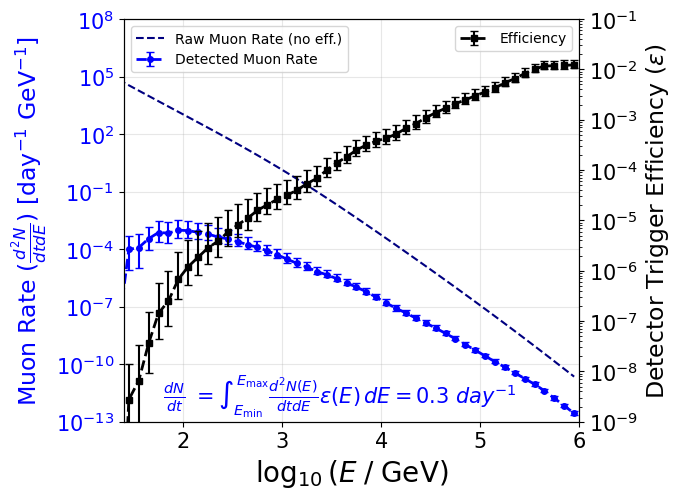

In [45]:
def Muon_Rate_per_E_Calculation(flux_eff_tensor, effective_area_mean, phi_axis,zen_arr):    
    R_zen_az_E = np.sum(flux_eff_tensor, axis = 1)
    R_zen_E = 2*np.trapezoid(R_zen_az_E*np.cos(np.radians(phi_axis)), x = np.radians(phi_axis), axis = 2)
    zen_arr = zen_arr-Telescope_Zenith
    zen_arr_pos = zen_arr[zen_arr >=0][:, None]
    R_zen_pos = R_zen_E[zen_arr >=0]
    R_pos = np.trapezoid(R_zen_pos*np.cos(np.radians(zen_arr_pos))**2, x = -(np.radians(zen_arr_pos)), axis = 0) * 3600 *24

    zen_arr_neg = zen_arr[zen_arr < 0][:, None]
    R_zen_neg = R_zen_E[zen_arr < 0]
    R_neg = np.trapezoid(R_zen_neg*np.cos(np.radians(zen_arr_neg))**2, x = -(np.radians(zen_arr_neg)), axis = 0) * 3600 *24

    R_E = R_neg + R_pos
    return R_E*effective_area_mean
"""def Muon_Rate_per_E_Calculation(flux_eff_tensor, effective_area_mean, phi_axis, zen_arr, X_arr):
    # flux_eff_tensor: (Z, H, E, A)
    # X_arr:           (Z, H)
    n_Z, n_H, n_E, n_A = flux_eff_tensor.shape

    # Integrate over H using X as variable, per zenith slice -> (Z, E, A)
    R_ZEA = np.empty((n_Z, n_E, n_A))
    for iz in range(n_Z):
        X_slice     = X_arr[iz]           # (n_H,)
        flux_slice  = flux_eff_tensor[iz] # (n_H, n_E, n_A)

        sort_idx    = np.argsort(X_slice)
        X_sorted    = X_slice[sort_idx]
        flux_sorted = flux_slice[sort_idx]

        R_ZEA[iz]   = np.trapezoid(flux_sorted, x=X_sorted, axis=0)  # (n_E, n_A)

    # Integrate over azimuth with cos(phi) weighting: (Z, E, A) -> (Z, E)
    R_zen_E = 2 * np.trapezoid(
        R_ZEA * np.cos(np.radians(phi_axis)),
        x=np.radians(phi_axis),
        axis=2
    )

    # Zenith offset from telescope pointing
    zen_offset = zen_arr - Telescope_Zenith   # (Z,)

    zen_pos    = zen_offset[zen_offset >= 0][:, None]   # (Z+, 1)
    R_zen_pos  = R_zen_E[zen_offset >= 0]               # (Z+, E)
    R_pos      = np.trapezoid(
        R_zen_pos * np.cos(np.radians(zen_pos))**2,
        x=-np.radians(zen_pos),
        axis=0
    ) * 3600 * 24                                       # (E,)

    zen_neg    = zen_offset[zen_offset < 0][:, None]    # (Z-, 1)
    R_zen_neg  = R_zen_E[zen_offset < 0]                # (Z-, E)
    R_neg      = np.trapezoid(
        R_zen_neg * np.cos(np.radians(zen_neg))**2,
        x=-np.radians(zen_neg),
        axis=0
    ) * 3600 * 24                                       # (E,)

    R_E = (R_pos + R_neg) * effective_area_mean
    return R_E


R_E     = Muon_Rate_per_E_Calculation(flux_eff_tensor,    effective_area_mean,                  phi_axis, zen_arr, X_arr)
R_E_lo  = Muon_Rate_per_E_Calculation(flux_eff_tensor_lo, effective_area_mean - effective_area_std, phi_axis, zen_arr, X_arr)
R_E_hi  = Muon_Rate_per_E_Calculation(flux_eff_tensor_hi, effective_area_mean + effective_area_std, phi_axis, zen_arr, X_arr)
R_E_raw = Muon_Rate_per_E_Calculation(flux_tensor,        raw_area,                             phi_axis, zen_arr, X_arr)
R_eff   = R_E / R_E_raw"""


R_E = Muon_Rate_per_E_Calculation(flux_eff_tensor, effective_area_mean, phi_axis, zen_arr)
R_E_lo = Muon_Rate_per_E_Calculation(flux_eff_tensor_lo, effective_area_mean - effective_area_std, phi_axis, zen_arr)
R_E_hi = Muon_Rate_per_E_Calculation(flux_eff_tensor_hi, effective_area_mean + effective_area_std, phi_axis, zen_arr)
R_E_raw = Muon_Rate_per_E_Calculation(flux_tensor, raw_area, phi_axis, zen_arr)
R_eff = R_E/R_E_raw

fig, ax1 = plt.subplots(figsize=(7, 5))

# ── left axis : muon rate ──────────────────────────────────────────────────
color_rate = 'blue'

err_lo = R_E - R_E_lo  # lower error bar lengths (always positive)
err_lo = np.clip(err_lo, np.min(err_lo[err_lo>0]), None)
err_hi = R_E_hi - R_E   # upper error bar lengths (always positive)
E_data_mask = E_axis<= max(Energy_GeV)
ax1.errorbar(
    np.log10(E_axis[E_data_mask]), R_E[E_data_mask],
    yerr=[err_lo[E_data_mask], err_hi[E_data_mask]],
    fmt='--o',
    color=color_rate,
    ecolor=color_rate,
    elinewidth=1.5,
    capsize=3,
    markersize=4,
    linewidth=2,
    label='Detected Muon Rate',
)
#ax1.plot(np.log10(E_axis), R_E, color=color_rate, linewidth=1.5, linestyle='--', label='Extrapolate Muon Rate')
ax1.plot(np.log10(E_axis), R_E_raw,
         color='navy', linewidth=1.5, linestyle='--', label='Raw Muon Rate (no eff.)')

ax1.set_yscale('log')
ax1.set_xlabel(r'$\log_{10}(E\;/\;\mathrm{GeV})$')
ax1.set_ylabel(r'Muon Rate $(\frac{d^{2}N}{dtdE})$ [day$^{-1}$ GeV$^{-1}$]', color=color_rate, fontsize=17)
ax1.tick_params(axis='y', labelcolor=color_rate)
ax1.legend(loc='upper left', fontsize=10)

# ── right axis : efficiency ────────────────────────────────────────────────
color_eff = 'black'
ax2 = ax1.twinx()

# Efficiency error bars propagated from lo/hi rate ratios
R_eff_lo = R_E_lo / R_E_raw
R_eff_hi = R_E_hi / R_E_raw

eff_err_lo = R_eff - R_eff_lo
eff_err_lo = np.clip(eff_err_lo, np.min(eff_err_lo[eff_err_lo>0]), None)

eff_err_hi = R_eff_hi - R_eff

#ax2.plot(np.log10(E_axis), R_eff, color=color_eff, linewidth=1.5, linestyle='--', label='Raw Muon Rate (no eff.)')

ax2.errorbar(
    np.log10(E_axis[E_data_mask]), R_eff[E_data_mask],
    yerr=[eff_err_lo[E_data_mask], eff_err_hi[E_data_mask]],
    fmt='--s',
    color=color_eff,
    ecolor=color_eff,
    elinewidth=1.5,
    capsize=3,
    markersize=4,
    linewidth=2,
    label='Efficiency',
)

ax2.set_ylabel(r'Detector Trigger Efficiency $(\epsilon)$', color=color_eff, fontsize=17)
ax2.tick_params(axis='y', labelcolor=color_eff)
ax2.set_yscale("log")
ax2.legend(loc='upper right', fontsize=10)

# ── cosmetics ─────────────────────────────────────────────────────────────
ax1.grid(True, which='both', alpha=0.3)
ax1.text(1.8, 1e-12, 
        r"$\frac{dN}{dt}\ = \int_{E_{\min}}^{E_{\max}} \frac{d^{2}N(E)}{dtdE} \epsilon(E) \, dE = 0.3$"+" "+r"$ day^{-1}$",
        fontsize=15,
        color = color_rate
)
fig.tight_layout()
ax1.set_ylim(1e-13, 1e8)
ax2.set_ylim(1e-9, 1e-1)
plt.xlim(1.4, 6)
plt.savefig("/uufs/chpc.utah.edu/common/home/u1520754/Muon_Trinity/plot/Muon_rate.png",transparent=True)
plt.show()


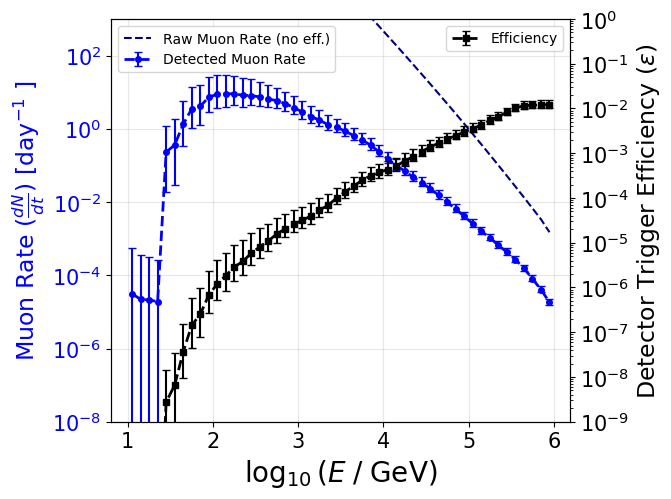

In [52]:
def Muon_Rate_per_E_Calculation(flux_eff_tensor, effective_area_mean, phi_axis,zen_arr):   
    d_E = np.gradient(E_axis) 
    R_zen_az_E = np.sum(flux_eff_tensor, axis = 1)
    R_zen_E = 2*np.trapezoid(R_zen_az_E*np.cos(np.radians(phi_axis)), x = np.radians(phi_axis), axis = 2)
    zen_arr = zen_arr-Telescope_Zenith
    zen_arr_pos = zen_arr[zen_arr >=0][:, None]
    R_zen_pos = R_zen_E[zen_arr >=0]
    R_pos = np.trapezoid(R_zen_pos*np.cos(np.radians(zen_arr_pos))**2, x = -(np.radians(zen_arr_pos)), axis = 0) * 3600 *24*365

    zen_arr_neg = zen_arr[zen_arr < 0][:, None]
    R_zen_neg = R_zen_E[zen_arr < 0]
    R_neg = np.trapezoid(R_zen_neg*np.cos(np.radians(zen_arr_neg))**2, x = -(np.radians(zen_arr_neg)), axis = 0) * 3600 *24*365

    R_E = R_neg + R_pos
    return R_E*effective_area_mean*d_E
"""def Muon_Rate_per_E_Calculation(flux_eff_tensor, effective_area_mean, phi_axis, zen_arr, X_arr):
    # flux_eff_tensor: (Z, H, E, A)
    # X_arr:           (Z, H)
    n_Z, n_H, n_E, n_A = flux_eff_tensor.shape

    # Integrate over H using X as variable, per zenith slice -> (Z, E, A)
    R_ZEA = np.empty((n_Z, n_E, n_A))
    for iz in range(n_Z):
        X_slice     = X_arr[iz]           # (n_H,)
        flux_slice  = flux_eff_tensor[iz] # (n_H, n_E, n_A)

        sort_idx    = np.argsort(X_slice)
        X_sorted    = X_slice[sort_idx]
        flux_sorted = flux_slice[sort_idx]

        R_ZEA[iz]   = np.trapezoid(flux_sorted, x=X_sorted, axis=0)  # (n_E, n_A)

    # Integrate over azimuth with cos(phi) weighting: (Z, E, A) -> (Z, E)
    R_zen_E = 2 * np.trapezoid(
        R_ZEA * np.cos(np.radians(phi_axis)),
        x=np.radians(phi_axis),
        axis=2
    )

    # Zenith offset from telescope pointing
    zen_offset = zen_arr - Telescope_Zenith   # (Z,)

    zen_pos    = zen_offset[zen_offset >= 0][:, None]   # (Z+, 1)
    R_zen_pos  = R_zen_E[zen_offset >= 0]               # (Z+, E)
    R_pos      = np.trapezoid(
        R_zen_pos * np.cos(np.radians(zen_pos))**2,
        x=-np.radians(zen_pos),
        axis=0
    ) * 3600 * 24                                       # (E,)

    zen_neg    = zen_offset[zen_offset < 0][:, None]    # (Z-, 1)
    R_zen_neg  = R_zen_E[zen_offset < 0]                # (Z-, E)
    R_neg      = np.trapezoid(
        R_zen_neg * np.cos(np.radians(zen_neg))**2,
        x=-np.radians(zen_neg),
        axis=0
    ) * 3600 * 24                                       # (E,)

    R_E = (R_pos + R_neg) * effective_area_mean
    return R_E


R_E     = Muon_Rate_per_E_Calculation(flux_eff_tensor,    effective_area_mean,                  phi_axis, zen_arr, X_arr)
R_E_lo  = Muon_Rate_per_E_Calculation(flux_eff_tensor_lo, effective_area_mean - effective_area_std, phi_axis, zen_arr, X_arr)
R_E_hi  = Muon_Rate_per_E_Calculation(flux_eff_tensor_hi, effective_area_mean + effective_area_std, phi_axis, zen_arr, X_arr)
R_E_raw = Muon_Rate_per_E_Calculation(flux_tensor,        raw_area,                             phi_axis, zen_arr, X_arr)
R_eff   = R_E / R_E_raw"""


R_E = Muon_Rate_per_E_Calculation(flux_eff_tensor, effective_area_mean, phi_axis, zen_arr)
R_E_lo = Muon_Rate_per_E_Calculation(flux_eff_tensor_lo, effective_area_mean - effective_area_std, phi_axis, zen_arr)
R_E_hi = Muon_Rate_per_E_Calculation(flux_eff_tensor_hi, effective_area_mean + effective_area_std, phi_axis, zen_arr)
R_E_raw = Muon_Rate_per_E_Calculation(flux_tensor, raw_area, phi_axis, zen_arr)
R_eff = R_E/R_E_raw

fig, ax1 = plt.subplots(figsize=(7, 5))

# ── left axis : muon rate ──────────────────────────────────────────────────
color_rate = 'blue'

err_lo = R_E - R_E_lo  # lower error bar lengths (always positive)
err_lo = np.clip(err_lo, np.min(err_lo[err_lo>0]), None)
err_hi = R_E_hi - R_E   # upper error bar lengths (always positive)

E_data_mask = E_axis<= max(Energy_GeV)

ax1.errorbar(
    np.log10(E_axis[E_data_mask]), R_E[E_data_mask],
    yerr=[err_lo[E_data_mask], err_hi[E_data_mask]],
    fmt='--o',
    color=color_rate,
    ecolor=color_rate,
    elinewidth=1.5,
    capsize=3,
    markersize=4,
    linewidth=2,
    label='Detected Muon Rate',
)
#ax1.plot(np.log10(E_axis), R_E, color=color_rate, linewidth=1.5, linestyle='--', label='Extrapolate Muon Rate')
ax1.plot(np.log10(E_axis), R_E_raw,
         color='navy', linewidth=1.5, linestyle='--', label='Raw Muon Rate (no eff.)')

ax1.set_yscale('log')
ax1.set_xlabel(r'$\log_{10}(E\;/\;\mathrm{GeV})$')
ax1.set_ylabel(r'Muon Rate $(\frac{dN}{dt})$ [day$^{-1}$ ]', color=color_rate, fontsize=17)
ax1.tick_params(axis='y', labelcolor=color_rate)
ax1.legend(loc='upper left', fontsize=10)

# ── right axis : efficiency ────────────────────────────────────────────────
color_eff = 'black'
ax2 = ax1.twinx()

# Efficiency error bars propagated from lo/hi rate ratios
R_eff_lo = R_E_lo / R_E_raw
R_eff_hi = R_E_hi / R_E_raw

eff_err_lo = R_eff - R_eff_lo
eff_err_lo = np.clip(eff_err_lo, np.min(eff_err_lo[eff_err_lo>0]), None)

eff_err_hi = R_eff_hi - R_eff

#ax2.plot(np.log10(E_axis), R_eff, color=color_eff, linewidth=1.5, linestyle='--', label='Raw Muon Rate (no eff.)')

ax2.errorbar(
    np.log10(E_axis[E_data_mask]), R_eff[E_data_mask],
    yerr=[eff_err_lo[E_data_mask], eff_err_hi[E_data_mask]],
    fmt='--s',
    color=color_eff,
    ecolor=color_eff,
    elinewidth=1.5,
    capsize=3,
    markersize=4,
    linewidth=2,
    label='Efficiency',
)

ax2.set_ylabel(r'Detector Trigger Efficiency $(\epsilon)$', color=color_eff, fontsize=17)
ax2.tick_params(axis='y', labelcolor=color_eff)
ax2.set_yscale("log")
ax2.legend(loc='upper right', fontsize=10)

# ── cosmetics ─────────────────────────────────────────────────────────────
ax1.grid(True, which='both', alpha=0.3)
"""ax1.text(1.9, 1, 
        r"$\frac{dN}{dt}\ = \int_{E_{\min}}^{E_{\max}} \frac{d^{2}N(E)}{dtdE} \epsilon(E) \, dE = 0.3$",
        fontsize=15,
        color = color_rate
)"""
fig.tight_layout()
ax1.set_ylim(1e-8, 1000)
ax2.set_ylim(1e-9, 1)
#plt.xlim(1.2, 6)
plt.savefig("/uufs/chpc.utah.edu/common/home/u1520754/Muon_Trinity/plot/Muon_rate.png",transparent=True)
plt.show()


In [ ]:
import matplotlib.patheffects as pe
from matplotlib.colors import SymLogNorm, LogNorm
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patheffects as pe
seconds_per_hour = 3600.0
def Muon_Rate_per_E_per_Zen_Calculation(flux_eff_tensor, effective_area_mean, phi_axis,zen_arr):    
    R_zen_az_E = np.sum(flux_eff_tensor, axis = 1)
    R_zen_E = 2*np.trapezoid(R_zen_az_E*np.cos(np.radians(phi_axis)), x = np.radians(phi_axis), axis = 2)
    return R_zen_E*effective_area_mean
# --- Compute detected and raw 2D rate arrays ---
R_zen_E_det = Muon_Rate_per_E_per_Zen_Calculation(
    flux_eff_tensor, effective_area_mean, phi_axis, zen_arr
) * seconds_per_hour   # (n_zen, n_E)  hr⁻¹ GeV⁻¹

R_zen_E_raw = Muon_Rate_per_E_per_Zen_Calculation(
    flux_tensor, effective_area_mean, phi_axis, zen_arr
) * seconds_per_hour   # raw (no trigger eff)

# --- Efficiency map [%] ---
with np.errstate(divide='ignore', invalid='ignore'):
    Eff_2D = np.where(
        R_zen_E_raw > 0,
        R_zen_E_det / R_zen_E_raw * 100.0,
        np.nan,
    )

# --- Energy mask ---
E_mask = (E_GeV >= min_E) & (E_GeV <= max_E)
E_plot = E_GeV[E_mask]

# --- Sort zenith ascending ---
zen_sort_idx = np.argsort(zen_arr)
zen_plot     = zen_arr[zen_sort_idx]

Z_det = R_zen_E_det[zen_sort_idx, :][:, E_mask]
Z_raw = R_zen_E_raw[zen_sort_idx, :][:, E_mask]
Z_eff = Eff_2D     [zen_sort_idx, :][:, E_mask]

# Mask non-positive for log scale
Z_det = np.where(Z_det > 0, Z_det, 0)
Z_raw = np.where(Z_raw > 0, Z_raw, 0)

# --- Build pcolormesh edges ---
logE       = np.log10(E_plot)
logE_edges = np.concatenate([
    [logE[0]  - 0.5*(logE[1]  - logE[0])],
    0.5*(logE[:-1] + logE[1:]),
    [logE[-1] + 0.5*(logE[-1] - logE[-2])],
])
E_edges = 10**logE_edges

zen_edges = np.concatenate([
    [zen_plot[0]  - 0.5*(zen_plot[1]  - zen_plot[0])],
    0.5*(zen_plot[:-1] + zen_plot[1:]),
    [zen_plot[-1] + 0.5*(zen_plot[-1] - zen_plot[-2])],
])

# --- Meshgrid for contours ---
E_mesh, Zen_mesh = np.meshgrid(E_plot, zen_plot)

# =========================================================================
fig, ax = plt.subplots(figsize=(12, 9))

# Background: detected muon rate
_pos_vals = Z_det[Z_det > 0]
pcm = ax.pcolormesh(
    E_edges, zen_edges, Z_det,
    norm=SymLogNorm(
        linthresh=np.nanpercentile(_pos_vals, 10) if len(_pos_vals) else 1e-10,
        linscale=1.0,
        vmin=0,
        vmax=np.nanmax(Z_det),
        base=10,
    ),
    cmap='terrain',
)

# ---- Contour 1: Raw muon rate (black solid) ----
raw_min = np.nanpercentile(Z_raw[Z_raw > 0], 10) if np.any(Z_raw > 0) else None
raw_max = np.nanmax(Z_raw)
if raw_min and raw_min > 0 and raw_max > raw_min:
    levels_raw = [1e-13, 1e-10, 1e-7, 1e-5, 1e-3, 1e-1, 10]
    cs_raw = ax.contour(
        E_mesh, Zen_mesh, Z_raw,
        levels=levels_raw,
        colors='black', linewidths=3.0, linestyles='solid', alpha=0.5,
    )
    labels_raw = ax.clabel(cs_raw, inline=True, fontsize=15, fmt='%.1e')
    for lbl in labels_raw:
        lbl.set_color('black')
        lbl.set_fontweight('bold')
        lbl.set_zorder(6)
        lbl.set_path_effects([
            pe.Stroke(linewidth=2, foreground='white'),
            pe.Normal(),
        ])

# ---- Contour 2: Efficiency [%] (white solid) ----
def fmt_eff(x):
    exp = int(np.floor(np.log10(x)))
    man = x / 10**exp
    if x >= 0.01:
        return rf'${x}\%$'
    if abs(man - 1.0) < 0.05:
        return rf'$1e{{{exp}}}\%$'
    return rf'${man:.0f}e{{{exp}}}\%$'

levels_eff_all = [1e-13, 1e-10, 1e-7, 1e-5, 0.001, 0.01, 0.1, 1.0, 10]
valid_eff      = np.nanmax(Z_eff)
levels_eff     = [lv for lv in levels_eff_all if lv < valid_eff]

if len(levels_eff) > 0:
    cs_eff_back = ax.contour(
        E_mesh, Zen_mesh, Z_eff,
        levels=levels_eff,
        colors='black', linewidths=4.0, linestyles='solid', alpha=0.3, zorder=4,
    )
    cs_eff = ax.contour(
        E_mesh, Zen_mesh, Z_eff,
        levels=levels_eff,
        colors='white', linewidths=2.0, linestyles='solid', alpha=0.5, zorder=5,
    )
    labels = ax.clabel(cs_eff, inline=True, fontsize=16, fmt=fmt_eff, zorder=6)
    for lbl in labels:
        lbl.set_color('white')
        lbl.set_fontweight('bold')
        lbl.set_zorder(6)
        lbl.set_path_effects([
            pe.Stroke(linewidth=2, foreground='black'),
            pe.Normal(),
        ])

# ---- Reference line ----
ax.axhline(90, color='red', ls='--', lw=3,
           label='Demonstrator Pointing Direction (90°)')

# ---- Axes ----
ax.set_xscale('log')
ax.set_xlabel(r'Muon Energy $E$ (GeV)', fontsize=20)
ax.set_ylabel(r'Zenith Angle $\theta$ (deg)', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=17, length=8,  width=2)
ax.tick_params(axis='both', which='minor', labelsize=12, length=4,  width=1.5)

# ---- Legend ----
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='black', lw=3, ls='-', alpha=0.5,
           label=r'Raw Muon Rate Contours (hr$^{-1}$ GeV$^{-1}$)'),
    Line2D([0], [0], color='white', lw=3, ls='-', alpha=0.5,
           label='Trigger Efficiency Contours (%)'),
    Line2D([0], [0], color='red',   lw=3, ls='--',
           label='Demonstrator Pointing Direction (90°)'),
]
ax.legend(handles=legend_elements, loc='upper left',
          bbox_to_anchor=(-0.1, -0.05), fontsize=15,
          framealpha=0.6, facecolor='grey')

# ---- Colorbar ----
cbar = fig.colorbar(pcm, ax=ax, orientation='horizontal', location='top',
                    fraction=0.07, pad=0.01, shrink=1.5)
my_ticks = [ 1e-14, 1e-12, 1e-10, 1e-8, 1e-6, 1e-4, 1e-2, 1e0]
my_ticks = [t for t in my_ticks if t <= np.nanmax(Z_det)]
cbar.set_ticks(my_ticks)
cbar.set_ticklabels([f'$10^{{{int(np.log10(t))}}}$' for t in my_ticks])
cbar.ax.tick_params(labelsize=17, length=7, width=2)
cbar.ax.tick_params(which='minor', length=4, width=1.5)
cbar.set_label(r'Detected Muon Rate (hr$^{-1}$ GeV$^{-1}$)', fontsize=20)

plt.tight_layout()
plt.show()


Keys in each entry : ['theta', 'd_CDF', 'CDF', 'L_grid', 'X_grid', 'H_grid', 'sum_mceq']
d_CDF shape        : (1000, 118)
CDF shape          : (1000, 118)
X_grid shape       : (1000,)
theta              : 87.17759227914941
zen_centers range  : 20.679999103152994 → 87.17759227914941 deg

Plotting 10 zenith bins (20.7° → 87.2°)


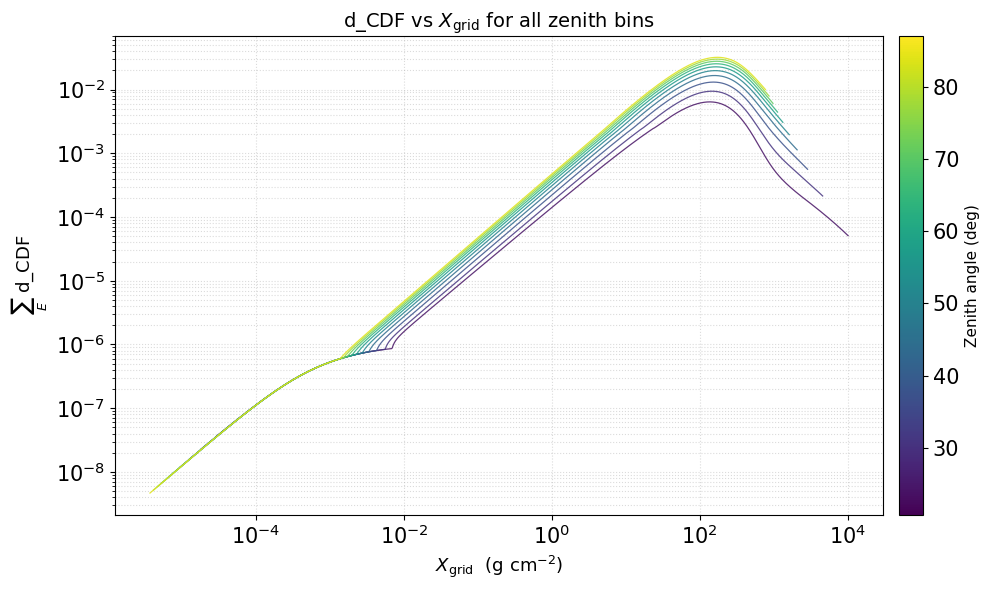

In [21]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ── Load pickle ───────────────────────────────────────────────────────────────
with open('/uufs/chpc.utah.edu/common/home/u1520754/Muon_Trinity/data/'
          'mceq_grid_10_90deg.pkl', 'rb') as f:
    grid_data = pickle.load(f)

zen_centers_all  = grid_data['zen_centers']
E_GeV            = grid_data['E_GeV']
per_zenith       = grid_data['per_zenith']

# ── Inspect one entry so we know the shapes ───────────────────────────────────
sample = per_zenith[0]
print("Keys in each entry :", list(sample.keys()))
print("d_CDF shape        :", np.array(sample['d_CDF']).shape)
print("CDF shape          :", np.array(sample['CDF']).shape  ) 
print("X_grid shape       :", np.array(sample['X_grid']).shape)
print("theta              :", sample['theta'])
print("zen_centers range  :", zen_centers_all.min(), "→", zen_centers_all.max(), "deg")

# ── User controls ─────────────────────────────────────────────────────────────
# Which dimension of d_CDF to collapse when plotting vs X_grid?
# d_CDF is typically (n_X, n_E)  → we sum / average over energy axis
COLLAPSE = 'sum'       # 'sum' | 'mean' | pick a single energy index (int)
E_IDX    = 0           # only used when COLLAPSE is an int

# Optionally restrict to a zenith range
ZEN_PLOT_MIN = 10.0    # deg
ZEN_PLOT_MAX = 90.0    # deg

# ── Filter zenith bins ────────────────────────────────────────────────────────
zen_mask = (zen_centers_all >= ZEN_PLOT_MIN) & (zen_centers_all <= ZEN_PLOT_MAX)
zen_plot    = zen_centers_all[zen_mask]
entries_plot = [e for e, keep in zip(per_zenith, zen_mask) if keep]

print(f"\nPlotting {len(zen_plot)} zenith bins "
      f"({zen_plot.min():.1f}° → {zen_plot.max():.1f}°)")

# ── Colour map ────────────────────────────────────────────────────────────────
colors = cm.viridis(np.linspace(0.05, 0.95, len(zen_plot)))

# ── Figure 1 : one line per zenith bin ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

for color, entry in zip(colors, entries_plot):
    theta  = entry['theta']
    X_grid = np.array(entry['X_grid'])    # (n_X,)   g cm⁻²
    d_CDF  = np.array(entry['d_CDF'])     # (n_X, n_E) or (n_X,)
    CDF    = np.array(entry['CDF']) 
    dE = np.gradient(E_GeV)
    y = np.sum(CDF*dE, axis=1)
    ax.plot(X_grid, y, lw=0.9, alpha=0.85, color=color,
            label=f'{theta:.1f}°')

# ── Colour bar acting as a zenith legend ──────────────────────────────────────
sm = cm.ScalarMappable(
        cmap='viridis',
        norm=plt.Normalize(vmin=zen_plot.min(), vmax=zen_plot.max()))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02, fraction=0.03)
cbar.set_label('Zenith angle (deg)', fontsize=11)

ax.set_xlabel(r'$X_{\rm grid}$  (g cm$^{-2}$)', fontsize=13)
collapse_label = ('$\\sum_E$ d_CDF' if COLLAPSE == 'sum'
                  else '$\\langle$d_CDF$\\rangle_E$' if COLLAPSE == 'mean'
                  else f'd_CDF[:, E_idx={E_IDX}]')
ax.set_ylabel(collapse_label, fontsize=13)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title('d_CDF vs $X_{\\rm grid}$ for all zenith bins', fontsize=14)
ax.grid(True, which='both', ls=':', alpha=0.45)
plt.tight_layout()
plt.savefig('dCDF_vs_Xgrid_all_zen.png', dpi=150)
plt.show()

Keys in each entry : ['theta', 'd_CDF', 'CDF', 'L_grid', 'X_grid', 'H_grid', 'sum_mceq']
d_CDF shape        : (1000, 118)
CDF shape          : (1000, 118)
X_grid shape       : (1000,)
theta              : 87.17759227914941
zen_centers range  : 20.679999103152994 → 87.17759227914941 deg

Plotting 10 zenith bins (20.7° → 87.2°)


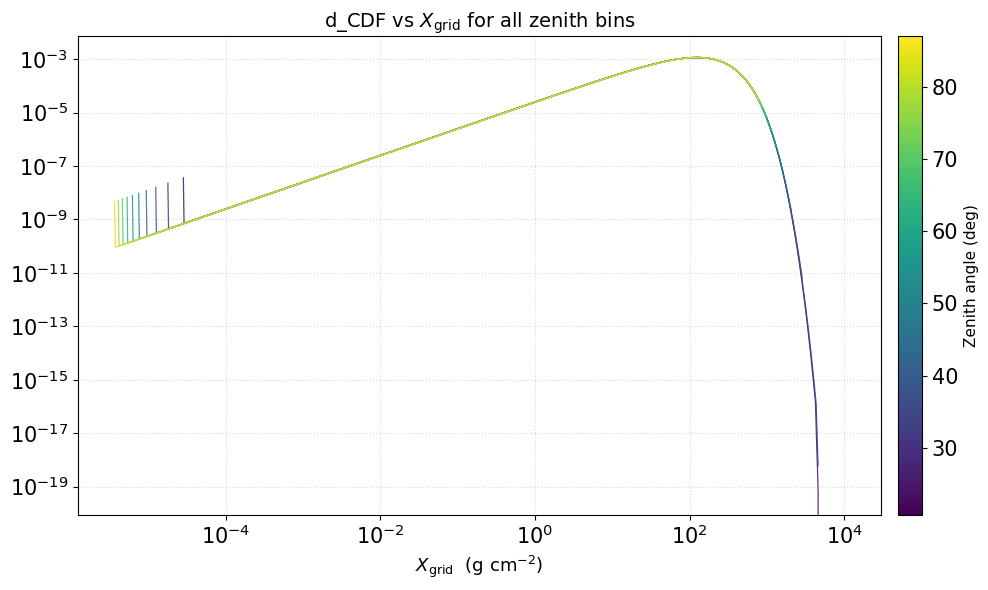

In [22]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ── Load pickle ───────────────────────────────────────────────────────────────
with open('/uufs/chpc.utah.edu/common/home/u1520754/Muon_Trinity/data/'
          'mceq_grid_10_90deg_no_decay_no_E_loss.pkl', 'rb') as f:
    grid_data = pickle.load(f)

zen_centers_all  = grid_data['zen_centers']
E_GeV            = grid_data['E_GeV']
per_zenith       = grid_data['per_zenith']

# ── Inspect one entry so we know the shapes ───────────────────────────────────
sample = per_zenith[0]
print("Keys in each entry :", list(sample.keys()))
print("d_CDF shape        :", np.array(sample['d_CDF']).shape)
print("CDF shape          :", np.array(sample['CDF']).shape  ) 
print("X_grid shape       :", np.array(sample['X_grid']).shape)
print("theta              :", sample['theta'])
print("zen_centers range  :", zen_centers_all.min(), "→", zen_centers_all.max(), "deg")

# ── User controls ─────────────────────────────────────────────────────────────

# Optionally restrict to a zenith range
ZEN_PLOT_MIN = 10.0    # deg
ZEN_PLOT_MAX = 90.0    # deg

# ── Filter zenith bins ────────────────────────────────────────────────────────
zen_mask = (zen_centers_all >= ZEN_PLOT_MIN) & (zen_centers_all <= ZEN_PLOT_MAX)
zen_plot    = zen_centers_all[zen_mask]
entries_plot = [e for e, keep in zip(per_zenith, zen_mask) if keep]

print(f"\nPlotting {len(zen_plot)} zenith bins "
      f"({zen_plot.min():.1f}° → {zen_plot.max():.1f}°)")

# ── Colour map ────────────────────────────────────────────────────────────────
colors = cm.viridis(np.linspace(0.05, 0.95, len(zen_plot)))

# ── Figure 1 : one line per zenith bin ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

for color, entry in zip(colors, entries_plot):
    theta  = entry['theta']
    X_grid = np.array(entry['X_grid'])    # (n_X,)   g cm⁻²
    d_CDF  = np.array(entry['d_CDF'])     # (n_X, n_E) or (n_X,)
    CDF    = np.array(entry['CDF']) 
    dE = np.gradient(E_GeV)
    y = np.sum(d_CDF*dE, axis=1)
    ax.plot(X_grid, y, lw=0.9, alpha=0.85, color=color,
            label=f'{theta:.1f}°')

# ── Colour bar acting as a zenith legend ──────────────────────────────────────
sm = cm.ScalarMappable(
        cmap='viridis',
        norm=plt.Normalize(vmin=zen_plot.min(), vmax=zen_plot.max()))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02, fraction=0.03)
cbar.set_label('Zenith angle (deg)', fontsize=11)

ax.set_xlabel(r'$X_{\rm grid}$  (g cm$^{-2}$)', fontsize=13)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title('d_CDF vs $X_{\\rm grid}$ for all zenith bins', fontsize=14)
ax.grid(True, which='both', ls=':', alpha=0.45)
plt.tight_layout()
plt.savefig('dCDF_vs_Xgrid_all_zen.png', dpi=150)
plt.show()


In [23]:
# 3D surface plot: muon rate per hour per GeV vs (Energy, Zenith)
# =========================================================================
import plotly.graph_objects as go
import numpy as np

seconds_per_hour = 3600.0

# Stack into 2D array: shape (n_zen, n_E)
flux_E_2D = np.array(flux_E_central_list)            # (n_zen, n_E)
Rate_E_2D = flux_E_2D * effective_area_mean * seconds_per_hour  # muons/hr/GeV

# Apply energy mask
E_mask = (E_GeV >= min_E) & (E_GeV <= max_E)
E_plot = E_GeV[E_mask]
Rate_2D_plot = Rate_E_2D[:, E_mask]

# Sort zenith ascending
zen_sort_idx = np.argsort(zen_centers)
zen_plot     = zen_centers[zen_sort_idx]
Rate_2D_plot = Rate_2D_plot[zen_sort_idx, :]

# Build meshgrid for 3D surface
E_mesh, Zen_mesh = np.meshgrid(E_plot, zen_plot)

# Replace non-positive values with NaN for log scaling
Z = np.where(Rate_2D_plot > 0, Rate_2D_plot, np.nan)

# Log10 of rate for the Z axis (makes the surface readable)
Z_log = np.log10(Z)

# ---- Build hover text ----
hover_text = np.array([
    [
        f"Energy: {E_mesh[i, j]:.3g} GeV<br>"
        f"Zenith: {Zen_mesh[i, j]:.1f}°<br>"
        f"Rate: {Z[i, j]:.3e} hr⁻¹ GeV⁻¹"
        for j in range(Z.shape[1])
    ]
    for i in range(Z.shape[0])
])

# ---- 3D Surface ----
surface = go.Surface(
    x=np.log10(E_mesh),   # log10(Energy) on X axis
    y=Zen_mesh,            # Zenith angle on Y axis
    z=Z_log,               # log10(Rate) on Z axis
    surfacecolor=Z_log,
    colorscale="Viridis",
    colorbar=dict(
        title=dict(text="log₁₀(Rate)<br>[hr⁻¹ GeV⁻¹]", side="right"),
        thickness=18,
        len=0.75,
    ),
    text=hover_text,
    hoverinfo="text",
    opacity=0.92,
    contours=dict(
        z=dict(
            show=True,
            usecolormap=True,
            highlightcolor="white",
            project_z=False,
            width=1,
        ),
        x=dict(show=False),
        y=dict(show=False),
    ),
    lighting=dict(
        ambient=0.6,
        diffuse=0.8,
        roughness=0.5,
        specular=0.3,
    ),
)

# ---- Horizon / zenith range planes ----
zen_min_val = float(np.min(Zenith))
zen_max_val = float(np.max(Zenith))

logE_range = [float(np.log10(E_plot.min())), float(np.log10(E_plot.max()))]
z_range    = [float(np.nanmin(Z_log)),        float(np.nanmax(Z_log))]

def zenith_plane(zen_val, color, name):
    """Vertical plane at a fixed zenith angle."""
    xs = np.array([[logE_range[0], logE_range[1]],
                   [logE_range[0], logE_range[1]]])
    ys = np.full_like(xs, zen_val)
    zs = np.array([[z_range[0], z_range[0]],
                   [z_range[1], z_range[1]]])
    return go.Surface(
        x=xs, y=ys, z=zs,
        colorscale=[[0, color], [1, color]],
        showscale=False,
        opacity=0.25,
        name=name,
        hoverinfo="skip",
    )

#plane_min = zenith_plane(zen_min_val, "red",  f"θ = {zen_min_val:.0f}°")
#plane_max = zenith_plane(zen_max_val, "red",  f"θ = {zen_max_val:.0f}°")

# ---- Tick marks for log10(E) axis ----
# Show integer powers of 10 within the energy range
log_ticks  = np.arange(
    np.ceil(np.log10(E_plot.min())),
    np.floor(np.log10(E_plot.max())) + 1,
    dtype=int,
)
tick_vals  = log_ticks.tolist()
tick_text  = [f"10<sup>{v}</sup>" for v in log_ticks]

# ---- Tick marks for log10(Rate) Z axis ----
z_log_min = np.floor(np.nanmin(Z_log))
z_log_max = np.ceil(np.nanmax(Z_log))
z_ticks   = np.arange(z_log_min, z_log_max + 1, dtype=int).tolist()
z_tick_text = [f"10<sup>{v}</sup>" for v in z_ticks]

# ---- Layout ----
fig = go.Figure(data=[surface])#, plane_min, plane_max])

fig.update_layout(
    title=dict(
        text="Muon Rate  (hr⁻¹ GeV⁻¹) vs Energy & Zenith Angle",
        x=0.5,
        font=dict(size=16),
    ),
    scene=dict(
        xaxis=dict(
            title="Muon Energy (GeV)",
            tickvals=tick_vals,
            ticktext=tick_text,
            showgrid=True,
            gridcolor="lightgrey",
            backgroundcolor="rgb(240,240,255)",
        ),
        yaxis=dict(
            title="Zenith Angle θ (deg)",
            showgrid=True,
            gridcolor="lightgrey",
            backgroundcolor="rgb(240,255,240)",
        ),
        zaxis=dict(
            title="Rate (hr⁻¹ GeV⁻¹)",
            tickvals=z_ticks,
            ticktext=z_tick_text,
            showgrid=True,
            gridcolor="lightgrey",
            backgroundcolor="rgb(255,245,240)",
        ),
        camera=dict(
            eye=dict(x=1.6, y=-1.6, z=0.9),  # initial viewing angle
        ),
        aspectmode="manual",
        aspectratio=dict(x=1.4, y=1.0, z=0.9),
    ),
    margin=dict(l=0, r=0, t=60, b=0),
    width=950,
    height=720,
    legend=dict(
        x=0.01, y=0.95,
        bgcolor="rgba(255,255,255,0.7)",
        bordercolor="grey",
        borderwidth=1,
    ),
)

fig.show()
fig.write_html("/uufs/chpc.utah.edu/common/home/u1520754/Muon_Trinity/plot/muon_rate_3d.html")

NameError: name 'flux_E_central_list' is not defined

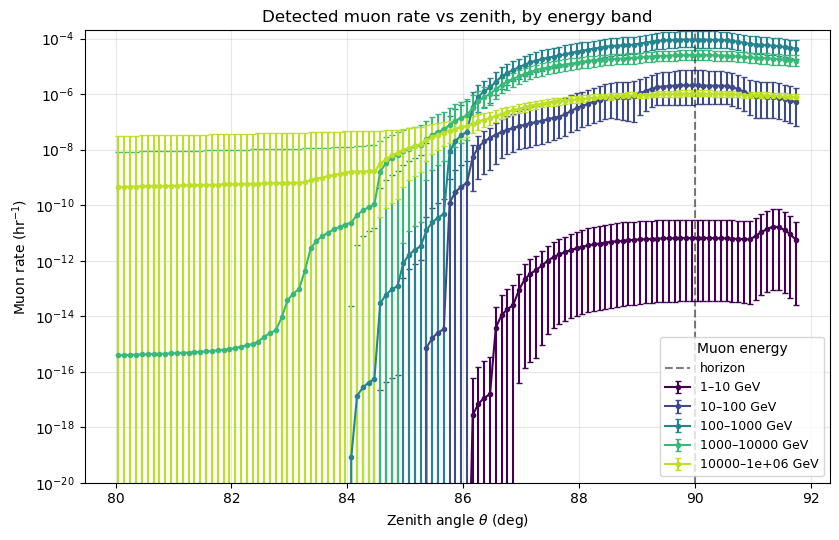

In [ ]:
#Muon rate per hour vs zenith, split by energy band
# =========================================================================

# Define energy bands [GeV] — edit as needed
E_bands = [
    (1.0,    10.0),
    (10.0,   100.0),
    (100.0,  1e3),
    (1e3,    1e4),
    (1e4,    1e6),
]
band_labels = [f"{lo:g}–{hi:g} GeV" for lo, hi in E_bands]

n_zen   = len(selected_entries)
n_bands = len(E_bands)

flux_band     = np.zeros((n_bands, n_zen))
flux_band_lo  = np.zeros((n_bands, n_zen))
flux_band_hi  = np.zeros((n_bands, n_zen))

for i, entry in enumerate(selected_entries):
    theta    = entry['theta']
    d_CDF    = entry['d_CDF']
    H_grid   = entry['H_grid']
    H_m      = H_grid / 100.0
    Solid_angle = solid_angles[i]
    theta_q  = min(theta, Zen_grid[-1])

    H_mesh, E_mesh = np.meshgrid(H_m, E_GeV, indexing='ij')
    Z_mesh = np.full_like(H_mesh, theta_q)

    eff_HE2 = np.nan_to_num(eff_func(E_mesh, H_mesh, Z_mesh), nan=0.0)
    med_HE2, lo_HE2, hi_HE2 = eff_sigma_func(E_mesh, H_mesh, Z_mesh)
    lo_HE2 = np.nan_to_num(lo_HE2, nan=0.0)
    hi_HE2 = np.nan_to_num(hi_HE2, nan=0.0)

    CDF = np.cumsum(d_CDF, axis=0)
    CDF_pos = np.cumsum(np.clip(d_CDF, 0, None), axis=0)
    survival_prob_per_E = CDF[-1] / CDF_pos[-1]

    integrand    = np.clip(d_CDF, 0, None) * eff_HE2 * survival_prob_per_E
    integrand_lo = np.clip(d_CDF, 0, None) * lo_HE2  * survival_prob_per_E
    integrand_hi = np.clip(d_CDF, 0, None) * hi_HE2  * survival_prob_per_E

    for b, (E_lo, E_hi) in enumerate(E_bands):
        mask = (E_GeV >= E_lo) & (E_GeV <= E_hi)
        if mask.sum() < 2:
            continue
        d_E    = np.trapezoid(integrand[:,    mask], E_GeV[mask], axis=1)
        d_E_lo = np.trapezoid(integrand_lo[:, mask], E_GeV[mask], axis=1)
        d_E_hi = np.trapezoid(integrand_hi[:, mask], E_GeV[mask], axis=1)

        flux_band[b, i]    = np.cumsum(d_E,    axis=0)[-1] * Solid_angle
        flux_band_lo[b, i] = np.cumsum(d_E_lo, axis=0)[-1] * Solid_angle
        flux_band_hi[b, i] = np.cumsum(d_E_hi, axis=0)[-1] * Solid_angle

# Convert to muons/hour
Rate_band    = flux_band    * effective_area_mean * seconds_per_hour
Rate_band_lo = flux_band_lo * effective_area_mean * seconds_per_hour
Rate_band_hi = flux_band_hi * effective_area_mean * seconds_per_hour

# Asymmetric eff errors + symmetric area error, in quadrature
dLo_eff = np.clip(Rate_band    - Rate_band_lo, 0, None)
dHi_eff = np.clip(Rate_band_hi - Rate_band,    0, None)
dArea   = flux_band * effective_area_std * seconds_per_hour

dLo = np.sqrt(dLo_eff**2 + dArea**2)
dHi = np.sqrt(dHi_eff**2 + dArea**2)

# Sort by zenith for clean lines
order_z = np.argsort(zen_centers)
zc_sorted = zen_centers[order_z]

plt.figure(figsize=(8.5, 5.5))
colors = plt.cm.viridis(np.linspace(0, 0.9, n_bands))
for b in range(n_bands):
    y   = Rate_band[b, order_z]
    elo = dLo[b, order_z]
    ehi = dHi[b, order_z]
    plt.errorbar(zc_sorted, y, yerr=np.vstack([elo, ehi]),
                 fmt='.-', capsize=2, color=colors[b],
                 label=band_labels[b])

plt.axvline(90, color='k', ls='--', alpha=0.5, label='horizon')
plt.xlabel(r'Zenith angle $\theta$ (deg)')
plt.ylabel(r'Muon rate (hr$^{-1}$)')
plt.yscale('log')
plt.ylim(1e-20, 2e-4)
plt.title('Detected muon rate vs zenith, by energy band')
plt.grid(True, which='both', alpha=0.3)
plt.legend(title='Muon energy', fontsize=9)
plt.tight_layout()
plt.show()


In [ ]:
import pickle
from matplotlib.colors import SymLogNorm
#E_mask_plot = (E_GeV > 5e1) & (E_GeV < 5e5)

# =========================================================================
# Build flux_raw_map from selected_entries (shape: n_zen x n_E)
# Each entry['d_CDF'] has shape (n_H, n_E); sum over H axis to get per-E flux
# =========================================================================
flux_raw_map = np.full((len(selected_entries), len(E_GeV)), np.nan)
for i, entry in enumerate(selected_entries):
    d = entry['d_CDF']
    # d_CDF may be (n_H, n_E) or (n_E,) depending on MCEq grid structure
    flux_raw_map[i, :] = d.sum(axis=0) if d.ndim == 2 else d

# =========================================================================
# Efficiency asymmetric half-widths  (n_zen, n_E)
# =========================================================================
eff_map_err_lo = np.clip(eff_map - eff_map_lo, 0, None)   # downward uncertainty
eff_map_err_hi = np.clip(eff_map_hi - eff_map, 0, None)   # upward uncertainty
eff_map_err    = 0.5 * (eff_map_err_lo + eff_map_err_hi)  # symmetric mid-point for plotting

# Muon flux × efficiency
flux_x_eff_map     = flux_raw_map * eff_map      # (n_zen, n_E)
flux_x_eff_err_map = flux_raw_map * eff_map_err  # (n_zen, n_E)

E_save_mask = (E_GeV >= 1e1) & (E_GeV <= 1e6)

eff_map_output = {
    'zen_centers':   zen_centers,
    'E_GeV':         E_GeV[E_save_mask],
    'H_grid':        selected_entries[0]['H_grid'],
    'eff_map':       eff_map[:, E_save_mask],
    'eff_map_lo':    eff_map_lo[:, E_save_mask],
    'eff_map_hi':    eff_map_hi[:, E_save_mask],
    'eff_map_err':   eff_map_err[:, E_save_mask],   # symmetric half-width
    'min_E':         1e1,
    'max_E':         1e6,
    'zen_range':     (zen_min_use, zen_max_use),
    'extend_to_deg': extend_to_deg,
}

out_path = '/uufs/chpc.utah.edu/common/home/u1520754/Muon_Trinity/data/eff_map_80_92deg.pkl'
with open(out_path, 'wb') as f:
    pickle.dump(eff_map_output, f)

print(f"Saved eff_map to {out_path}")
print(f"  E range:           {E_GeV[E_save_mask].min():.1e} – {E_GeV[E_save_mask].max():.1e} GeV  ({E_save_mask.sum()} bins)")
print(f"  eff_map shape:     {eff_map[:, E_save_mask].shape}")
print(f"  eff_map_lo shape:  {eff_map_lo[:, E_save_mask].shape}")
print(f"  eff_map_hi shape:  {eff_map_hi[:, E_save_mask].shape}")
print(f"  eff_map_err shape: {eff_map_err[:, E_save_mask].shape}")


Saved eff_map to /uufs/chpc.utah.edu/common/home/u1520754/Muon_Trinity/data/eff_map_80_92deg.pkl
  E range:           1.1e+01 – 8.9e+05 GeV  (50 bins)
  eff_map shape:     (118, 50)
  eff_map_lo shape:  (118, 50)
  eff_map_hi shape:  (118, 50)
  eff_map_err shape: (118, 50)


Zenith bins: 118  (91.75° → 80.05°)
Energy bins: 50  (1.12e+01 → 8.91e+05 GeV)
eff_map shape:     (118, 50)
eff_map_lo shape:  (118, 50)
eff_map_hi shape:  (118, 50)
eff_map_err shape: (118, 50)


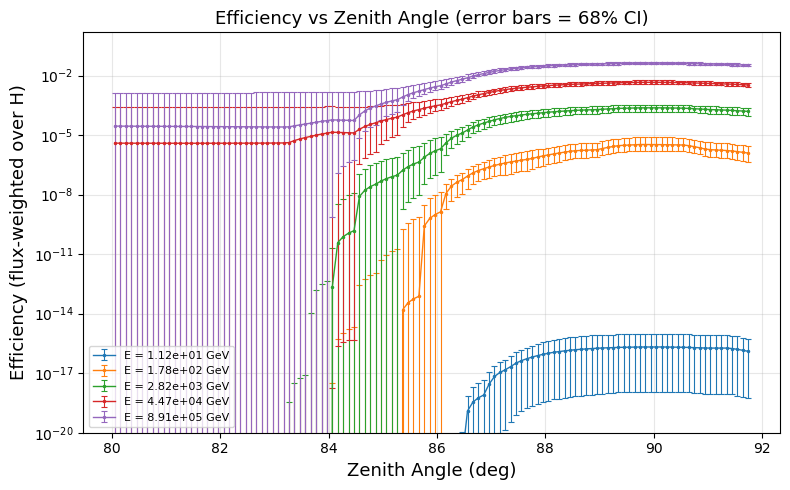

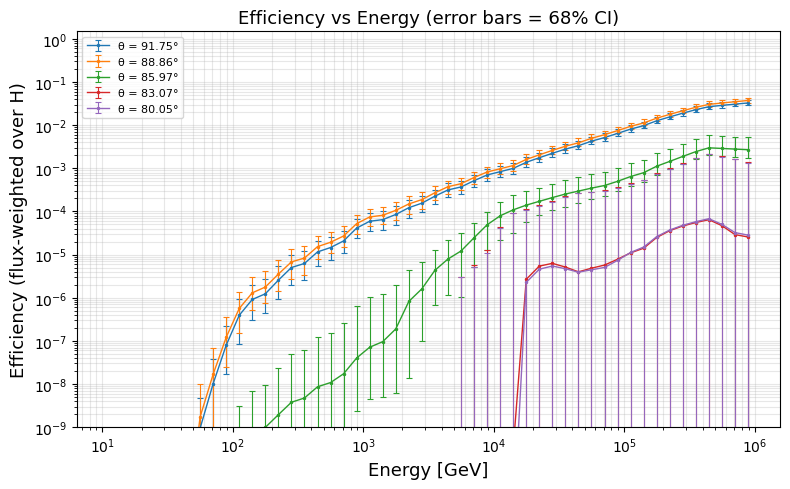

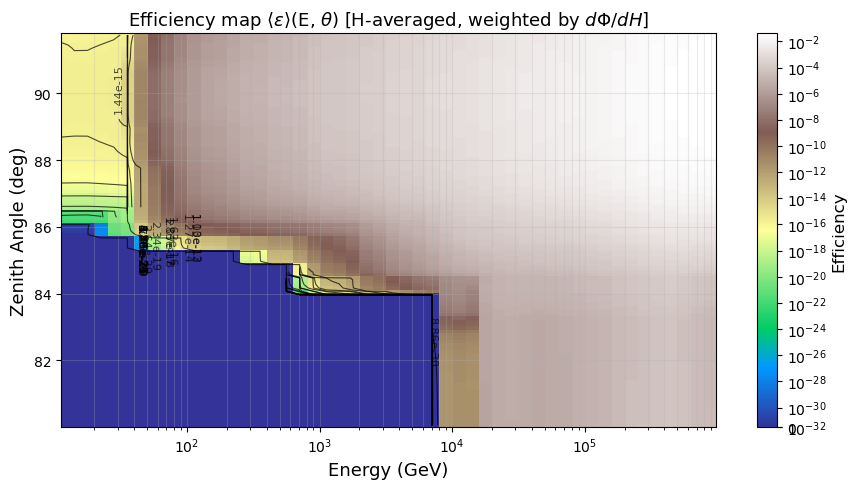

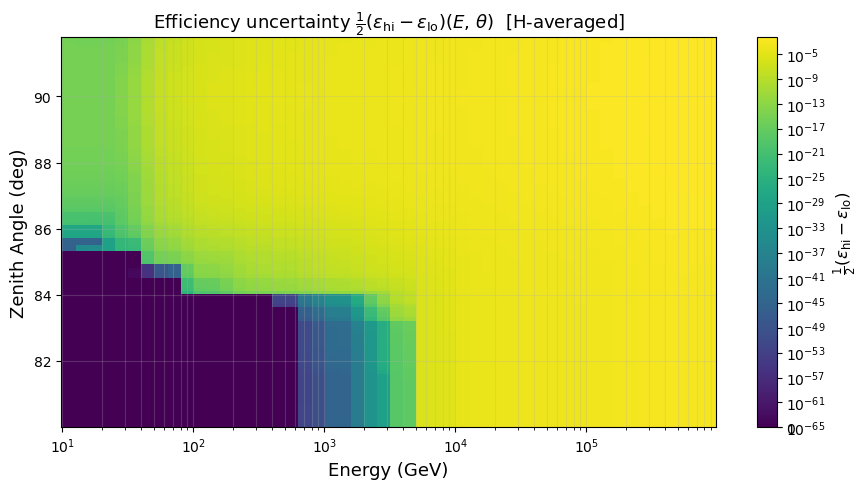

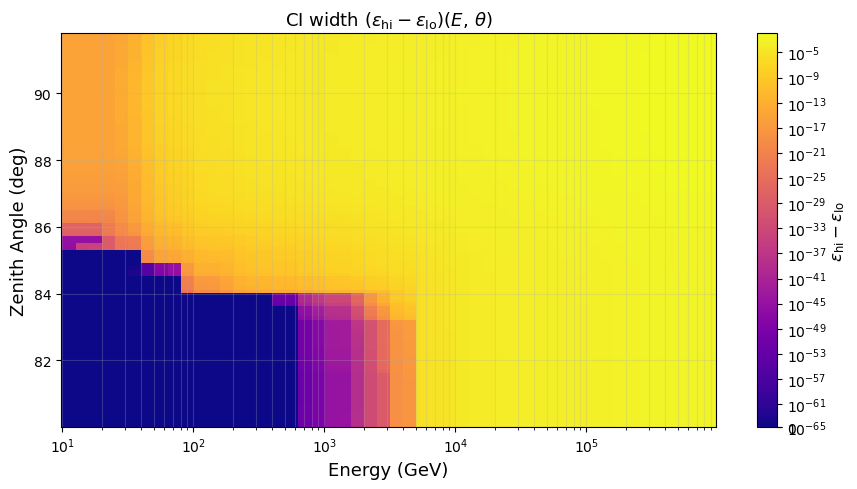

/tmp/ipykernel_1814932/253244882.py:168: RuntimeWarning:

divide by zero encountered in divide

/tmp/ipykernel_1814932/253244882.py:168: RuntimeWarning:

invalid value encountered in divide



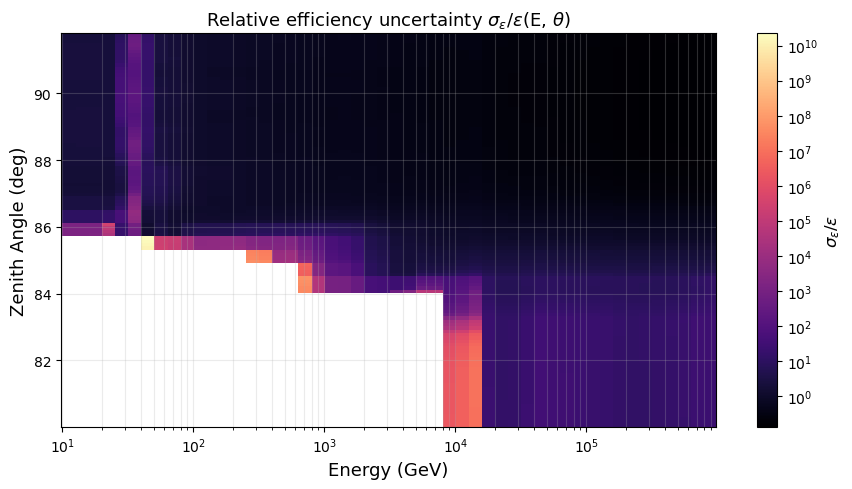

In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm

in_path = '/uufs/chpc.utah.edu/common/home/u1520754/Muon_Trinity/data/eff_map_80_92deg.pkl'

with open(in_path, 'rb') as f:
    data = pickle.load(f)

zen_centers = data['zen_centers']
E_GeV       = data['E_GeV']
eff_map     = data['eff_map']
eff_map_lo  = data['eff_map_lo']
eff_map_hi  = data['eff_map_hi']
eff_map_err = data['eff_map_err']   # symmetric half-width

# Asymmetric half-widths for error bars
err_lo = np.clip(eff_map - eff_map_lo, 0, None)  # downward
err_hi = np.clip(eff_map_hi - eff_map, 0, None)  # upward

print(f"Zenith bins: {len(zen_centers)}  ({zen_centers[0]:.2f}° → {zen_centers[-1]:.2f}°)")
print(f"Energy bins: {len(E_GeV)}  ({E_GeV[0]:.2e} → {E_GeV[-1]:.2e} GeV)")
print(f"eff_map shape:     {eff_map.shape}")
print(f"eff_map_lo shape:  {eff_map_lo.shape}")
print(f"eff_map_hi shape:  {eff_map_hi.shape}")
print(f"eff_map_err shape: {eff_map_err.shape}")

def _symlog_norm(data, fallback=1e-12):
    pos = data[np.isfinite(data) & (data > 0)]
    linthresh = pos.min() if pos.size else fallback
    return SymLogNorm(linthresh=linthresh, linscale=np.min(data[np.where(data>0)]), base=10)
# =========================================================================
# 1a. Efficiency vs Zenith (line plot with asymmetric error bands)
# =========================================================================
fig, ax = plt.subplots(figsize=(8, 5))

# Pick a few energy bins to display (e.g., 5 evenly spaced across the array)
n_show_E = min(5, len(E_GeV))
idxs_E = np.linspace(0, len(E_GeV) - 1, n_show_E, dtype=int)

for j in idxs_E:
    # eff_map has shape (N_zenith, N_energy), so we slice [:, j] to get all zenith bins for energy j
    ax.errorbar(
        zen_centers, eff_map[:, j],
        yerr=[err_lo[:, j], err_hi[:, j]],          # asymmetric CI
        label=f"E = {E_GeV[j]:.2e} GeV",
        marker='.', markersize=3, linewidth=1,
        capsize=2, capthick=0.8, elinewidth=0.8,
    )

ax.set_yscale('log')
ax.set_ylim(1e-20, 1.5)
ax.set_xlabel('Zenith Angle (deg)', fontsize=13)
ax.set_ylabel('Efficiency (flux-weighted over H)', fontsize=13)
ax.set_title('Efficiency vs Zenith Angle (error bars = 68% CI)', fontsize=13)
ax.legend(fontsize=8)
ax.grid(True, which='both', alpha=0.3)
fig.tight_layout()
plt.show()

# =========================================================================
# 1b. Efficiency vs Energy (line plot with asymmetric error bands)
# =========================================================================
fig, ax = plt.subplots(figsize=(8, 5))
n_show = min(5, len(zen_centers))
idxs = np.linspace(0, len(zen_centers) - 1, n_show, dtype=int)
for i in idxs:
    ax.errorbar(
        E_GeV, eff_map[i],
        yerr=[err_lo[i], err_hi[i]],          # asymmetric CI
        label=f"θ = {zen_centers[i]:.2f}°",
        marker='.', markersize=3, linewidth=1,
        capsize=2, capthick=0.8, elinewidth=0.8,
    )
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(1e-9, 1.5)
ax.set_xlabel('Energy [GeV]', fontsize=13)
ax.set_ylabel('Efficiency (flux-weighted over H)', fontsize=13)
ax.set_title('Efficiency vs Energy (error bars = 68% CI)', fontsize=13)
ax.legend(fontsize=8)
ax.grid(True, which='both', alpha=0.3)
fig.tight_layout()
plt.show()

# =========================================================================
# 2. Efficiency 2D heatmap
# =========================================================================
n_contours = 20  # <-- user sets number of contour lines here

fig, ax = plt.subplots(figsize=(9, 5))
pcm = ax.pcolormesh(
    E_GeV, zen_centers, eff_map,
    shading='auto', cmap='terrain',
    norm=_symlog_norm(eff_map),
)

# --- contours in log scale ---
vmin = np.nanmin(eff_map[eff_map > 0])   # lowest positive value
vmax = np.nanmax(eff_map)
contour_levels = np.logspace(-30, -12, n_contours)

cs = ax.contour(
    E_GeV, zen_centers, eff_map,
    levels=contour_levels,
    colors='black',
    linewidths=0.8,
    alpha=0.7,
)
ax.clabel(cs, fmt='%.2e', fontsize=8, inline=True)

ax.set_xscale('log')
ax.set_xlabel(r'Energy (GeV)', fontsize=13)
ax.set_ylabel(r'Zenith Angle (deg)', fontsize=13)
ax.set_title(r'Efficiency map $\langle\varepsilon\rangle$(E, $\theta$) '
             r'[H-averaged, weighted by $d\Phi/dH$]', fontsize=13)
fig.colorbar(pcm, ax=ax).set_label('Efficiency', fontsize=12)
ax.grid(alpha=0.25, which='both')
fig.tight_layout()
plt.show()


# =========================================================================
# 3a. Efficiency uncertainty 2D heatmap  (symmetric half-width)
# =========================================================================
fig, ax = plt.subplots(figsize=(9, 5))
pcm_err = ax.pcolormesh(
    E_GeV, zen_centers, eff_map_err,
    shading='auto', cmap='viridis',
    norm=_symlog_norm(eff_map_err),
)
ax.set_xscale('log')
ax.set_xlabel(r'Energy (GeV)', fontsize=13)
ax.set_ylabel(r'Zenith Angle (deg)', fontsize=13)
ax.set_title(r'Efficiency uncertainty $\frac{1}{2}(\varepsilon_\mathrm{hi}-\varepsilon_\mathrm{lo})$'
             r'$(E,\,\theta)$  [H-averaged]', fontsize=13)
fig.colorbar(pcm_err, ax=ax).set_label(
    r'$\frac{1}{2}(\varepsilon_\mathrm{hi}-\varepsilon_\mathrm{lo})$', fontsize=12)
ax.grid(alpha=0.25, which='both')
fig.tight_layout()
plt.show()

# =========================================================================
# 3b. Asymmetric CI width: hi - lo
# =========================================================================
ci_width = np.clip(eff_map_hi - eff_map_lo, 0, None)
fig, ax = plt.subplots(figsize=(9, 5))
pcm_ci = ax.pcolormesh(
    E_GeV, zen_centers, ci_width,
    shading='auto', cmap='plasma',
    norm=_symlog_norm(ci_width),
)
ax.set_xscale('log')
ax.set_xlabel(r'Energy (GeV)', fontsize=13)
ax.set_ylabel(r'Zenith Angle (deg)', fontsize=13)
ax.set_title(r'CI width $(\varepsilon_\mathrm{hi}-\varepsilon_\mathrm{lo})$'
             r'$(E,\,\theta)$', fontsize=13)
fig.colorbar(pcm_ci, ax=ax).set_label(
    r'$\varepsilon_\mathrm{hi}-\varepsilon_\mathrm{lo}$', fontsize=12)
ax.grid(alpha=0.25, which='both')
fig.tight_layout()
plt.show()

# =========================================================================
# 4. Relative uncertainty 2D heatmap  (sigma / eff)
# =========================================================================
rel_err = np.where(eff_map > 0, eff_map_err / eff_map, np.nan)

fig, ax = plt.subplots(figsize=(9, 5))
pcm_rel = ax.pcolormesh(
    E_GeV, zen_centers, rel_err,
    shading='auto', cmap='magma',
    norm=_symlog_norm(rel_err),
)
ax.set_xscale('log')
ax.set_xlabel(r'Energy (GeV)', fontsize=13)
ax.set_ylabel(r'Zenith Angle (deg)', fontsize=13)
ax.set_title(r'Relative efficiency uncertainty $\sigma_\varepsilon / \varepsilon$(E, $\theta$)',
             fontsize=13)
fig.colorbar(pcm_rel, ax=ax).set_label(
    r'$\sigma_\varepsilon / \varepsilon$', fontsize=12)
ax.grid(alpha=0.25, which='both')
fig.tight_layout()
plt.show()


In [ ]:
from scipy.interpolate import RegularGridInterpolator

# Build interpolators on log10(E), zenith
logE_grid = np.log10(E_GeV)

# Use log10(eff) for smoother interpolation; mask non-positive
def _build_log_eff_interp(eff_2d):
    safe = np.where(eff_2d > 0, eff_2d, np.nan)
    log_eff = np.log10(safe)
    return RegularGridInterpolator(
        (zen_centers, logE_grid), log_eff,
        method='linear', bounds_error=False, fill_value=None,
    )

_interp_eff    = _build_log_eff_interp(eff_map)
_interp_eff_lo = _build_log_eff_interp(eff_map_lo)
_interp_eff_hi = _build_log_eff_interp(eff_map_hi)

def n_events_for_one_trigger(E_GeV_query, zen_deg_query):
    """
    Estimate number of events that must be generated at given (E, zenith)
    to obtain on average 1 triggered event: N = 1 / efficiency.

    Parameters
    ----------
    E_GeV_query : float or array
        Energy in GeV.
    zen_deg_query : float or array
        Zenith angle in degrees.

    Returns
    -------
    dict with keys:
        'eff', 'eff_lo', 'eff_hi' : interpolated efficiency and 68% CI
        'N', 'N_lo', 'N_hi'       : required event count (N_hi from eff_lo, etc.)
    """
    E_q   = np.atleast_1d(E_GeV_query).astype(float)
    zen_q = np.atleast_1d(zen_deg_query).astype(float)
    pts = np.column_stack([zen_q, np.log10(E_q)])

    eff    = 10 ** _interp_eff(pts)
    eff_lo = 10 ** _interp_eff_lo(pts)
    eff_hi = 10 ** _interp_eff_hi(pts)

    with np.errstate(divide='ignore', invalid='ignore'):
        N    = 1.0 / eff
        N_lo = 1.0 / eff_hi   # high eff -> low N
        N_hi = 1.0 / eff_lo   # low  eff -> high N

    return {
        'E_GeV':  E_q,
        'zen':    zen_q,
        'eff':    eff,
        'eff_lo': eff_lo,
        'eff_hi': eff_hi,
        'N':      N,
        'N_lo':   N_lo,
        'N_hi':   N_hi,
    }


# ---------- example usage ----------
E_query   = [0.5e6, 1e5, 2e1]      # GeV
zen_query = [86, 89.0, 91.0]     # deg

for E, z in zip(E_query, zen_query):
    r = n_events_for_one_trigger(E, z)
    print(f"E = {E:.2e} GeV, θ = {z:.2f}°  ->  "
          f"eff = {r['eff'][0]:.3e} "
          f"[{r['eff_lo'][0]:.2e}, {r['eff_hi'][0]:.2e}],  "
          f"N_needed = {r['N'][0]:.3e} "
          f"[{r['N_lo'][0]:.2e}, {r['N_hi'][0]:.2e}]")


E = 5.00e+05 GeV, θ = 86.00°  ->  eff = 3.054e-03 [2.04e-03, 5.87e-03],  N_needed = 3.275e+02 [1.70e+02, 4.90e+02]
E = 1.00e+05 GeV, θ = 89.00°  ->  eff = 8.632e-03 [7.49e-03, 1.06e-02],  N_needed = 1.158e+02 [9.47e+01, 1.34e+02]
E = 2.00e+01 GeV, θ = 91.00°  ->  eff = 1.893e-16 [9.12e-19, 8.55e-16],  N_needed = 5.282e+15 [1.17e+15, 1.10e+18]


In [ ]:
from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import distance_transform_edt

# =========================================================================
# Build (Energy, Zenith) grid of runtime statistics
# =========================================================================
Zen_list = np.sort(np.unique(Zenith))
E_arr    = np.asarray(E_list, dtype=float)

runtime_mean  = np.full((len(E_arr), len(Zen_list)), np.nan)
filesize_mean = np.full((len(E_arr), len(Zen_list)), np.nan)

runtime_band_lo = {c: np.full_like(runtime_mean, np.nan) for c in coverages}
runtime_band_hi = {c: np.full_like(runtime_mean, np.nan) for c in coverages}

for i, E in enumerate(E_arr):
    for j, z in enumerate(Zen_list):
        m = (Energy_GeV == E) & (Zenith == z)
        if not m.any():
            continue
        runtime_mean[i, j]  = np.nanmean(runtime_hours[m])
        filesize_mean[i, j] = np.nanmean(file_size[m])
        for cov in coverages:
            lo_p = (100 - cov) / 2
            hi_p = 100 - lo_p
            runtime_band_lo[cov][i, j] = np.nanpercentile(runtime_hours[m], lo_p)
            runtime_band_hi[cov][i, j] = np.nanpercentile(runtime_hours[m], hi_p)

# =========================================================================
# Nearest-neighbor fill for NaN cells
# =========================================================================
def nn_fill(grid_2d):
    """Replace NaN entries by the value of the nearest non-NaN cell (in index space)."""
    arr = np.asarray(grid_2d, dtype=float).copy()
    mask = np.isnan(arr)
    if not mask.any():
        return arr
    if mask.all():
        return arr  # nothing to fill from
    # Indices of nearest non-NaN cell
    _, (ii, jj) = distance_transform_edt(mask, return_indices=True)
    arr[mask] = arr[ii[mask], jj[mask]]
    return arr

runtime_mean  = nn_fill(runtime_mean)
filesize_mean = nn_fill(filesize_mean)
for cov in coverages:
    runtime_band_lo[cov] = nn_fill(runtime_band_lo[cov])
    runtime_band_hi[cov] = nn_fill(runtime_band_hi[cov])

# =========================================================================
# Interpolators on (log10 E, Zenith). Use log10 of runtime for smoothness.
# =========================================================================
logE_axis = np.log10(E_arr)

def _make_interp(grid_2d, log_y=True):
    vals = np.log10(grid_2d) if log_y else grid_2d.copy()
    return RegularGridInterpolator(
        (logE_axis, Zen_list), vals,
        method='linear', bounds_error=False, fill_value=None,
    )

_interp_runtime    = _make_interp(runtime_mean,  log_y=True)
_interp_filesize   = _make_interp(filesize_mean, log_y=True)
_interp_runtime_lo = {c: _make_interp(runtime_band_lo[c], log_y=True) for c in coverages}
_interp_runtime_hi = {c: _make_interp(runtime_band_hi[c], log_y=True) for c in coverages}

def runtime_per_event(E_GeV_query, zen_deg_query, coverage=None):
    E_q   = np.atleast_1d(E_GeV_query).astype(float)
    zen_q = np.atleast_1d(zen_deg_query).astype(float)
    pts = np.column_stack([np.log10(E_q), zen_q])

    out = {
        'E_GeV':       E_q,
        'zen':         zen_q,
        'runtime_hr':  10 ** _interp_runtime(pts),
        'filesize_MB': 10 ** _interp_filesize(pts),
    }
    if coverage is not None:
        if coverage not in coverages:
            raise ValueError(f"coverage must be one of {coverages}")
        out['runtime_lo'] = 10 ** _interp_runtime_lo[coverage](pts)
        out['runtime_hi'] = 10 ** _interp_runtime_hi[coverage](pts)
    return out

def cpu_hours_per_trigger(E_GeV_query, zen_deg_query, coverage=95):
    rt = runtime_per_event(E_GeV_query, zen_deg_query, coverage=coverage)
    ne = n_events_for_one_trigger(E_GeV_query, zen_deg_query)
    return {
        **rt,
        'N_needed':  ne['N'],
        'cpu_hr':    ne['N']    * rt['runtime_hr'],
        'cpu_hr_lo': ne['N_lo'] * rt['runtime_lo'],
        'cpu_hr_hi': ne['N_hi'] * rt['runtime_hi'],
    }

# ---------- example ----------
E_query   = [1e3, 1e4, 1e5]
zen_query = [85.0, 89.0, 91.0]
for E, z in zip(E_query, zen_query):
    r = runtime_per_event(E, z, coverage=95)
    print(f"E={E:.1e} GeV, θ={z:.1f}°  ->  "
          f"runtime = {r['runtime_hr'][0]:.3e} hr "
          f"[{r['runtime_lo'][0]:.2e}, {r['runtime_hi'][0]:.2e}],  "
          f"file = {r['filesize_MB'][0]:.2f} MB")


/tmp/ipykernel_1814932/777851050.py:21: RuntimeWarning:

Mean of empty slice

/uufs/chpc.utah.edu/common/home/u1520754/miniconda3/envs/jupyter_env/lib/python3.9/site-packages/numpy/lib/_nanfunctions_impl.py:1424: RuntimeWarning:

All-NaN slice encountered



E=1.0e+03 GeV, θ=85.0°  ->  runtime = 3.644e-02 hr [2.41e-02, 7.22e-02],  file = 0.41 MB
E=1.0e+04 GeV, θ=89.0°  ->  runtime = 4.127e-02 hr [2.52e-02, 6.42e-02],  file = 3.25 MB
E=1.0e+05 GeV, θ=91.0°  ->  runtime = 3.937e-02 hr [2.61e-02, 7.77e-02],  file = 1.29 MB


Energy:1.122020e+01 , Number of Seed 9222787864909970 170785828018931
Number of event per Energy: 15494283613048749600 286920191071804080
Total runtime per event 1.135915196426981e+18
Total Sim time 283978799106745.25 hours
 
Energy:1.412540e+01 , Number of Seed 9414499162048982 172892830432461
Number of event per Energy: 15816358592242289760 290459955126534480
Total runtime per event 1.1595271214692424e+18
Total Sim time 289881780367310.56 hours
 
Energy:1.778280e+01 , Number of Seed 9467792644612506 172480464376462
Number of event per Energy: 15905891642949010080 289767180152456160
Total runtime per event 1.166090958521675e+18
Total Sim time 291522739630418.75 hours
 
Energy:2.238720e+01 , Number of Seed 8612882063170318 158230435932871
Number of event per Energy: 14469641866126134240 265827132367223280
Total runtime per event 1.0607967746728646e+18
Total Sim time 265199193668216.16 hours
 
Energy:2.818380e+01 , Number of Seed 7691268948855661 142597048160180
Number of event per Ener

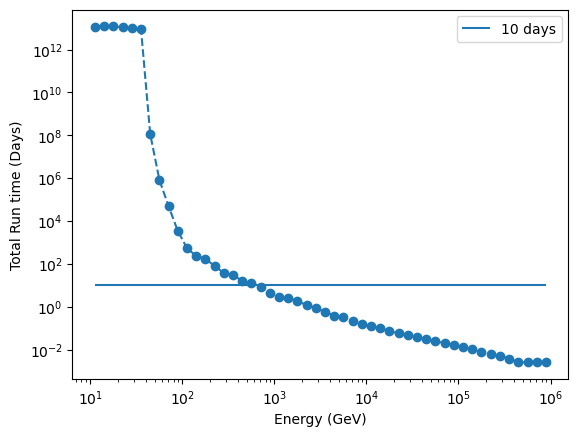

In [ ]:
zeniths = [f"{z:.1f}" for z in np.arange(87.0, 90.0, 0.3)] #
zeniths_full = [f"{z:.1f}" for z in np.arange(86.1, 89.9, 0.3)]
if "89.9" not in zeniths:
    zeniths.append("89.9")
    zeniths_full.append("89.9")
zeniths_extended = list(set(zeniths_full)-set(zeniths))

azimuths = [f"{a:.1f}" for a in np.arange(267.0, 273.3, 0.3)] #["270.0"]#
azimuths_full = [f"{a:.1f}" for a in np.arange(266.1, 274.3, 0.3)]
azimuths_extended = list(set(azimuths_full) - set(azimuths)) 
T_sim = []
for e in E_list:
    Num_job = 200
    time_per_job = 20
    Zen = zeniths
    N_zen = len(zeniths_extended)
    N_azimuth = len(azimuths_full)
    N_h = 20
    N_min = n_events_for_one_trigger(e, Zen[0])['N'][0]
    N_max = n_events_for_one_trigger(e, Zen[-1])['N'][0]
    T_min = runtime_per_event(E, Zen[0], coverage=95)['runtime_hr'][0]
    T_max = runtime_per_event(E, Zen[-1], coverage=95)['runtime_hr'][0]
    T_mean = (T_min+T_max)/2
    num_seed_min = int(N_min/N_azimuth)
    num_seed_max = int(N_max/N_azimuth)
    Total_Sim_Time =  (N_zen*N_azimuth*20*num_seed_min*T_max/(Num_job*time_per_job))
    print(f"Energy:{e:e}",", Number of Seed", num_seed_min, num_seed_max)
    print("Number of event per Energy:", N_zen*len(azimuths_full)*N_h*num_seed_min, N_zen*len(azimuths_full)*20*num_seed_max)
    print("Total runtime per event", N_zen*len(azimuths_full)*N_h*num_seed_min*T_max)
    print(f"Total Sim time", Total_Sim_Time, "hours")
    print(" ")
    T_sim.append(Total_Sim_Time)

plt.plot(E_list, np.array(T_sim)/(24),"--o")
plt.hlines(10, min(E_list), max(E_list), label="10 days")
plt.xlabel("Energy (GeV)")
plt.ylabel("Total Run time (Days)")
plt.loglog()
plt.legend()